<a href="https://colab.research.google.com/github/nicklausmillican/CausalInference_Solutions/blob/main/CausalInferenceInStatistics_Solutions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Donate to support this work
[Tip](https://paypal.me/nicklausmillican?country.x=US&locale.x=en_US)

[Monthly Support](https://millican04.gumroad.com/l/monthlysupport)

This colab sheet presents my solutions to the fantastic book [Causal Inference in Statistics - A Primer](https://www.amazon.com/Causal-Inference-Statistics-Judea-Pearl/dp/1119186846/ref=sr_1_1?crid=9WEMZG92RKWM&dib=eyJ2IjoiMSJ9.B5U7P53Pgj0WFcWqUYFik65lOfhnV-nzKzyhIxYI6vlo3a0q5Kpo6PBf_xyoSkdg_4mFkqZX9yibE-LcXg8EVGhi_VO4-Eaw-brVIpPEPQ0518zufpv26Qn9zP7Enn5R.vGMsSbM3pheU2A5sUg5FuBwp7xCwLrZNCHIVgjZBdxM&dib_tag=se&keywords=causal+inference+in+statistics+a+primer&qid=1711637222&sprefix=causal+inference+in+%2Caps%2C155&sr=8-1).

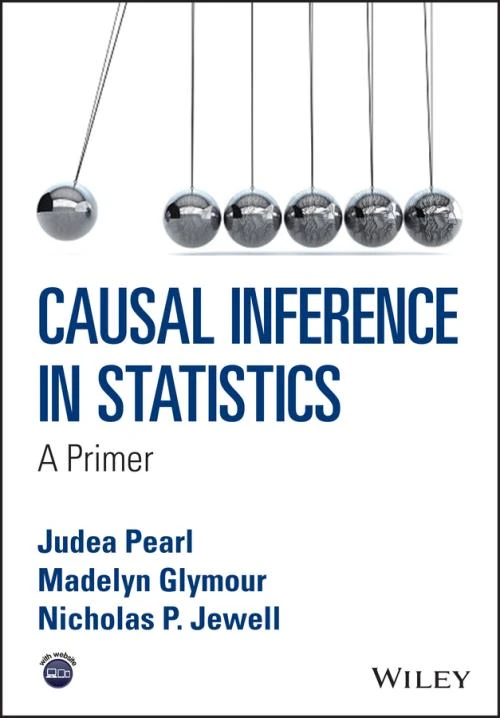

# Chapter 1

## Question 1.2.1
What is wrong with the following claims?

### Answer to 1.2.1 a
“Data show that income and marriage have a high positive correlation. Therefore, your earnings will increase if you get married.”

#### Answer
Income and marriage may covary for reasons other than the presumed causal relation $M \rightarrow I$.  For example, Income may increase marriage prospects ($M \leftarrow I$) or some third variable like Culture may affect both Marriage and Income ($M \leftarrow C \rightarrow I$).

### Answer to 1.2.1 b
“Data show that as the number of fires increase, so does the number of fire fighters. Therefore, to cut down on fires, you should reduce the number of fire fighters.”

#### Answer
Just as in part a, there are other possible causal explanations than the presumed $FF \rightarrow F$:
*   $FF \leftarrow F$
*   $FF \leftarrow X \rightarrow F$

### Answer to 1.2.1 c
“Data show that people who hurry tend to be late to their meetings. Don’t hurry, or you’ll be late.”

#### Answer
Do we even need to worry about this one?  The answer is that the described association may be the result of several potential causal chains.

## Question 1.2.2
A baseball batter Tim has a better batting average than his teammate Frank. However, someone notices that Frank has a better batting average than Tim against both right-handed and left-handed pitchers. How can this happen? (Present your answer in a table.)

### Answer to 1.2.2
This is about "Simpson's paradox", wherein the relationship between two variables reverses when conditioning on a third variable.  Here, the batting average between Tim and Frank is such that Tim > Frank.  However, when we condition on pitchers' handedness, Tim < Frank.

I'm going to use **Table 1.2** to model my table.

|           | Frank          | Tim             |
|-----------|------------------|------------------|
|           |                  |                  |
| Right Handed    | 81 hits out of 87 at bats (93%) | 234 hits out of 270 (87%) at bats |
| Left Handed   | 192 hits out of 263 at bats (73%) | 55 hits out of 80 (69%) at bats |
| Combined  | 273 hits out of 350 (78%) at bats | 289 hits out of 350 (83%) at bats |

I generally have a very difficult time understanding this; how in the world can Frank do better than Tim against left- and right-handed pitchers, but not when considering both?  The answer is in the absolute number of at bats each player has against both types of pitchers: the pitchers against whom Frank does best, right handers, are also the pitchers against which he has faced least such that the overall impact is reduced when considering both types of pitchers; conversely, the pitchers for whom Tim does best, also right handers, are the pitchers against which he has faced the most such that the overall impact is great when considering both types of pitchers.

It's nice to be able to get your head around Simpson's paradox, but I think the important lesson here is that our interpretation of data can be pushed around as we view it through different lenses.  If we want to make valid causal inferences, we must bring valid causal assumptions to the data; the data doesn't provide these (typically).

## Question 1.2.3
Determine, for each of the following causal stories, whether you should use the aggregate or the segregated data to determine the true effect.

>   (a) There are two treatments used on kidney stones: Treatment A and Treatment B. Doctors are more likely to use Treatment A on large (and therefore, more severe) stones and more likely to use Treatment B on small stones. Should a patient who doesn’t know the size of his or her stone examine the general population data, or the stone size-specific data when determining which treatment will be more effective?

>   (b) There are two doctors in a small town. Each has performed 100 surgeries in his career, which are of two types: one very difficult surgery and one very easy surgery. The first doctor performs the easy surgery much more often than the difficult surgery and the second doctor performs the difficult surgery more often than the easy surgery. You need surgery, but you do not know whether your case is easy or difficult. Should you consult the success rate of each doctor over all cases, or should you consult their success rates for the easy and difficult cases separately, to maximize the chance of a successful surgery?

### Answer to 1.2.3 a
Let's start by drawing a representation of the scenario.

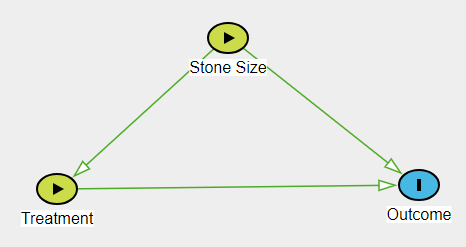

 (I made this figure on [dagitty.net](https://www.dagitty.net/dags.html), if you're curious.)

So I'm assuming that the Outcome is determined both by the Treatment and the Stone Size (smaller stones are probably more likely to be successfully treated), and that Treatment is also affected by Stone Size.

In this scenario, we should NOT consult the aggregated data, which would ignore the effect of Stone Size and Treatment on Outcome.  Instead, we should consult the data segregated by Stone Size and Treatment.  Notice, it would not make sense to look at data segregated only by Stone Size or only by Treatment since Stone Size affects Outcome via Treatment, and Treatment is affected by Stone Size.

There is one thing I'm unclear about here.  That is, the scenario stipulates that we don't know the size of our stone.  In this case, we cannot apply knowledge about Stone Size and Treatment to our situation.

### Answer to 1.2.3 b
I find this scenario a little difficult to interpret:  Do the doctors perform more of one surgery over another due to their personal preference?  Or are patients referred to doctors based on the severity of the diagnosis and the doctors skill set and availability?  Or is it partially both?  I'll assume partially both.  Then this scenario is like part (a), but with an additional variable: Case Severity.

Let's again visit [dagitty.net](https://www.dagitty.net/dags.html).

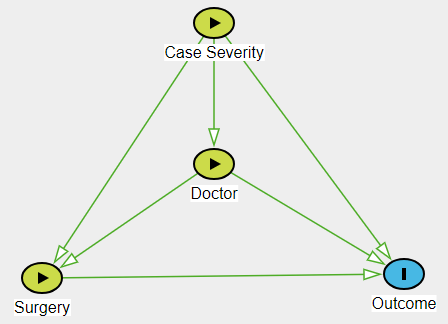

This complicates things a bit.  But since Outcome is being affected by each of the other 3 variables, I think we should like a data that has been segrated across each explanatory variable.

But we're again confronted with the fact that we supposedly don't know our Case Severity, so we can't apply this knowledge.

## Question 1.2.4
In an attempt to estimate the effectiveness of a new drug, a randomized experiment is conducted. In all, 50% of the patients are assigned to receive the new drug and 50% to receive a placebo. A day before the actual experiment, a nurse hands out lollipops to some patients who show signs of depression, mostly among those who have been assigned to treatment the next day (i.e., the nurse’s round happened to take her through the treatment-bound ward). Strangely, the experimental data revealed a Simpson’s reversal: Although the drug proved beneficial to the population as a whole, drug takers were less likely to recover than nontakers, among both lollipop receivers and lollipop nonreceivers. Assuming that lollipop sucking in itself has no effect whatsoever on recovery, answer the following questions:

>   (a) Is the drug beneficial to the population as a whole or harmful?

>   (b) Does your answer contradict our gender example, where sex-specific data was deemed more appropriate?

>   (c) Draw a graph (informally) that more or less captures the story. (Look ahead to Section 1.4 if you wish.)

>   (d) How would you explain the emergence of Simpson’s reversal in this story?

>   (e) Would your answer change if the lollipops were handed out (by the same criterion) a day after the study?

(Hint: Use the fact that receiving a lollipop indicates a greater likelihood of being assigned to drug treatment, as well as depression, which is a symptom of risk factors that lower the likelihood of recovery.)

#### Answers
Let's start by drawing the scenario.  I think it must look something like this:

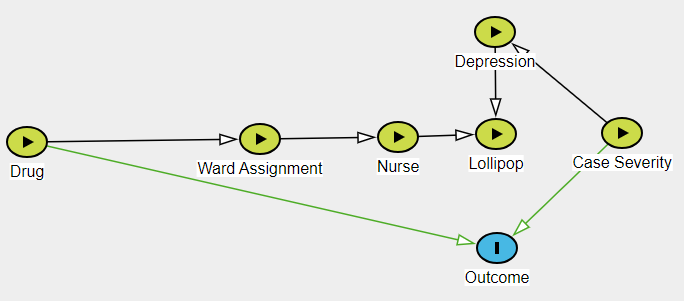

Patient's are apparently assigned to a ward based on their treatment group.  Since a nurse, apparently, services only one ward, the $Drug$ causes $Nurse$ via $Ward$.  Similarly, $Drug$ (partially) causes $Lollipop$ via $Ward$ and $Nurse$ (I think we're meant to assume that placebo-ward patients did not receive lollipops).  $Lollipop$ is also partially caused by $Depression$.

This second cause of $Lollipop$, $Depression$, means that conditioning on $Lollipop$ is akin to conditioning on $Depression$.  If patients are more likely to be depressed if they have a more severe case of whatever $Drug$ is tyring to remedy, then conditioning on $Lollipop$ partitions the data of those that received the drug into something like *severe* and *non-severe* cases.

##### Answer to 1.2.4 a
***Is the drug beneficial to the population as a whole or harmful?***

Even though the question gave us the results for the lollipop-partitioned data, we should not use that to determine the effectiveness of the drug.  According to our picture, only $Drug$ affects outcome, NOT $Lollipop$.

##### Answer to 1.2.4 b
***Does your answer contradict our gender example, where sex-specific data was deemed more appropriate?***

No.  In the gender example, $Sex$ really was a cause of $Outcome$.

##### Answer to 1.2.4 c
***Draw a graph (informally) that more or less captures the story. (Look ahead to Section 1.4 if you wish.)***

See above.

##### Answer to 1.2.4 d
***How would you explain the emergence of Simpson’s reversal in this story?***

This can be a difficult question to answer because we usually try to supply a causal explanation with our answers.  But Simpson's paradox is NOT a phenomenon of causality within the system, but rather a coincidence among group sizes and outcomes.  Thus, I think a good answer here is merely a table of group sizes.

Unfortunately, for *this* story, I don't think we can induce Simpson's paradox.  Why?  We cannot compare Drug+Lollipop vs Placebo+Lollipop since (I assme) the placebo group didn't get any lollipops ($p(recover | Placebo, Lollipop) = \frac{0}{0} = undefined$).

|             | Drug           | Placebo         |
|-------------|----------------|-----------------|
| Lollipop    | 5/25 (20.0%)   | 0/0 (undefined) |
| No Lollipop | 17/75 (22.6%)  | 23/100 (23.0%)  |
| Combined    | 22/100 (22.0%) | 23/100 (23.0%)  |

If we instead try to compare both Drug+Lollipop and Drug+NoLollipop groups to the Placebo+NoLollipop group, we can't induce Simpson's paradox.  Try playing with the numbers yourself.

If we instead assume that Placebo patients randomly received lollipops, then we can.

|             | Drug           | Placebo        |
|-------------|----------------|----------------|
| Lollipop    | 7/25 (28.0%)   | 25/75 (33.3%)  |
| No Lollipop | 50/75 (66.7%)  | 20/25 (80.0%)  |
| Combined    | 57/100 (57.0%) | 45/100 (45.0%) |

##### Answer to 1.2.4 e
***Would your answer change if the lollipops were handed out (by the same criterion) a day after the study?***

In this case, since $Lollipop$ is not a cause of $Outcome$ regardless of when it is given, our answer would not change.  We would still consult the aggregated data.

## Question 1.3.1
Identify the variables and events invoked in the lollipop story of Study question 1.2.4



### Answer to 1.3.1
If we go to the picture in 1.2.4

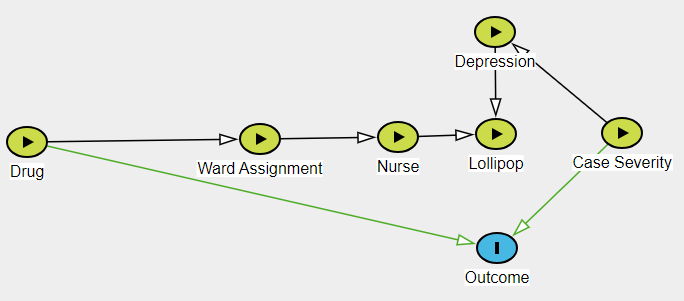

Each variable is displayed as a *node*.  The events are simply the values of those variables; for example, $Drug = 0$ and $Drug = 1$ are events.

For reasons that will become clear as the book continues, though,

## Question 1.3.2
Consider Table 1.5 showing the relationship between gender and education level in the U.S. adult popultion.

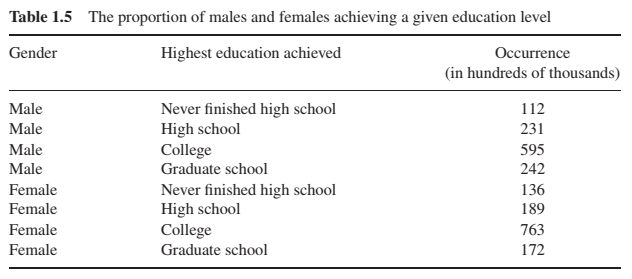

>   (a) Estimate *p(High School)*

>   (b) Estimate *p(High School OR Female)*

>   (c) Estimate *p(High School | Female)*

>   (d) Estimate *p(Female | High School)*

### Answer to 1.3.2 a
$p(High School) = \frac{(Male, High School) + (Female, High School)}{All} = \frac{231 + 189}{112 + 231 + 595 + 242 + 136 + 189 + 763 + 172} = \frac{420}{2440} = 17.2\%$

### Answer to 1.3.2 b
$p(High School OR Female) = \frac{(Male, High School) + (Female, High School) + (Female, Never) + (Female, College) + (Female + Graduate School)}{All} = \frac{231 + 189 + 136 + 763 + 172}{112 + 231 + 595 + 242 + 136 + 189 + 763 + 172} = \frac{1491}{2440} = 61.1\%$

### Answer to 1.3.2 c
$p(High School | Female) = \frac{Female, High School}{Female} = \frac{Female, High School}{(Female, Never) + (Female, High School) + (Female, College) + (Female + Graduate School)} = \frac{189}{136 + 189 + 763 + 172} = 15.0\%$

### Answer to 1.3.2 d
$p(Female | High School) = \frac{Female, High School}{High School} = \frac{Female, High School}{(Female, High School) + (Male, High School)} = \frac{189}{189 + 231} = \frac{189}{420} = 45.0\%$

## Question 1.3.3
Consider the casino problem described in Section 1.3.6 (is actually Section 1.3.7).

> (a) Compute $p(“craps”|“11”)$ assuming that there are twice as many roulette tables as craps games at the casino.

> (b) Compute $p(“roulette”|“10”)$ assuming that there are twice as many craps games as roulette tables at the casino.

### Answers
In case you need a refresher, the casino problem is this:
> You're in a casino when you hear a dealer yell "11!", which may come from either a game of craps or a game of roulette.  The number of craps games is equal to the number of roulette games.  The probability of 11 in craps is 1/18; the probability of 11 in roullete is 1/38.

#### Answer to 1.3.3 a
There's a few ways to solve this.  The most straightforward way is to use the definition of conditional probability:

$$p(A|B) = \frac{p(A,B)}{p(B)}$$

Here, $A = craps$ and $B = 11$ such that

$$p(craps|11) = \frac{p(craps, 11)}{p(11)}$$

We can further decompse the numerator using the definition of joint probability like $p(A,B) = p(B|A)*p(A)$ as $p(craps,11) = p(11|craps)*p(craps)$, and the denominator using the law of total probability as $p(11) = p(11|craps)*p(craps) + p(11|roulette)*p(roulette)$.  This gives us the full formula for Bayes' Theorem:

$$p(craps|11) = \frac{p(11|craps)*p(craps)}{p(11|craps)*p(craps) + p(11|roulette)*p(roulette)}$$

Substituting values, we get

$$p(craps|11) = \frac{1/18*1/3}{1/18*1/3 + 1/38*2/3} = \frac{1/54}{1/54 + 2/114} = \frac{1/54}{37/1026} = \frac{1026}{1998} \approx 0.514$$

#### Answer to 1.3.3 b
Going through the same steps as part a, we want to find the values for each term in

$$p(roulette|10) = \frac{p(10|roulette)*p(roulette)}{p(10|roulette)*p(roulette) + p(10|craps)*p(craps)} = \frac{1/38 * 1/3}{1/38 * 1/3 + 1/12 * 2/3} = \frac{1/114}{1/114 + 2/36} = \frac{1/114}{11/171} = \frac{171}{1254} \approx 0.136$$

## Question 1.3.4
Suppose we have three cards. Card 1 has two black faces, one on each side; Card 2 has two white faces; and Card 3 has one white face and one back face. You select a card at random and place it on the table. You find that it is black on the face-up side. What is the probability that the face-down side of the card is also black?

>   (a) Use your intuition to argue that the probability that the face-down side of the card is also black is 1/2 . Why might it be greater than 1/2?

>   (b) Express the probabilities and conditional probabilities that you find easy to estimate (for example, $p(C_D = Black)$), in terms of the following variables:

>>   $I$ = Identity of the card selected (Card 1, Card 2, or Card 3)

>>   $C_D$ = Color of the face-down side (Black, White)

>>   $C_U$ = Color of the face-up side (Black, White)

> Find the probability that the face-down side of the selected card is black, using your estimates above.

>   (c) Use Bayes’ theorem to find the correct probability of a randomly selected card’s back being black if you observe that its front is black?

### Answer to 1.3.4 a
***Use your intuition to argue that the probability that the face-down side of the card is also black is 1/2 . Why might it be greater than 1/2?***

We'll come to figure that "1/2" is the wrong answer, but you can see what 1/2 has an intuitive allure.  By seeing that the face-up side is black, you reason that this card is either the BB card or the BW card.  Since it could be either, you reason that there is a 1/2 chance that it BB and thus there is a 1/2 chance that the other side is black.

But why might this be wrong?  Because the BB card is twice as likely to show a black face; thus, the probability that the card with a black face up is more than 1/2.

### Answer to 1.3.4 b
***Express the probabilities and conditional probabilities that you find easy to estimate (for example,  $p(C_D=Black)$), in terms of the following variables:***

>   ***$I$  = Identity of the card selected (Card 1, Card 2, or Card 3)***

>   ***$C_D$  = Color of the face-down side (Black, White)***

>   ***$C_U$  = Color of the face-up side (Black, White)***

I'll just stick to the suggested estimand, $p(C_D=Black)$.

$$p(C_D=Black) = p(C_D=Black | I=1)*p(I=1) + p(C_D=Black | I=2)*p(I=2) + p(C_D=Black | I=3)*p(I=3)$$
$$=1(\frac{1}{3}) + 0(\frac{1}{3}) + \frac{1}{2}(\frac{1}{3})$$
$$=\frac{1}{3} + 0 + \frac{1}{6} = \frac{2}{6} + \frac{1}{6} = \frac{3}{6} = \frac{1}{2}$$

We're also supposed to ***Find the probability that the face-down side of the selected card is black, using your estimates above.***  But we'll do that in part c.

### Answer to 1.3.4 c
***Use Bayes’ theorem to find the correct probability of a randomly selected card’s back being black if you observe that its front is black?***

$$p(C_D = Black | C_U = Black) = p(I=1 | C_U = Black) = \frac{p(C_U = Black | I = 1)*p(I=1)}{p(C_U = Black)} = \frac{1(1/3)}{1/2} = \frac{1}{3}*\frac{2}{1} = \frac{2}{3}$$

## Question 1.3.5 (Monty Hall)
Prove, using Bayes’ theorem, that switching doors improves your chances of winning the car in the Monty Hall problem.

### Answer to 1.3.5
Let me paste the description of the Monty Hall problem given in the chapter:

> In the problem, you are a contestant on a game show, hosted by Monty Hall. Monty shows you three doors—A, B, and C—behind one and only one of which is a new car. (The other two doors have goats.) If you guess correctly, the car is yours; otherwise, you get a goat. You guess A at random. Monty, who is forbidden from revealing where the car is, then opens Door C, which, of course, has a goat behind it. He tells you that you can now switch to Door B, or stick with Door A. Whichever you pick, you’ll get what’s behind it.

> Are you better off opening Door A, or switching to Door B?

The key insight here is that you, the contestant, are presented with TWO pieces of information in sequence:
1.   At first, you know you have a 1/3 chance of correctly picking.  Thus, your prior probabilty of a correct pick is 1/3 while your prior probablity of a wrong pick is 2/3.
2.   Then, since Monty knows where the car is and cannot reveal it, you gain some evidence when he opens Door C.  1/3 of the time, the times you've already picked the correct Door, he could've opened either of the two doors you didn't initially pick--in which case, switching your selection will result in the correct pick 0% of the time.  Conversely, 2/3 of the time, the times you initially picked wrong, he could only open one of the remaining doors (the one with the goat), and leave closed the one with the car--in which case, switching your selection results in the correct pick 100% of the time.

Since you're more likely to pick incorrectly first, 2/3 of the time, and repicking in these instances leads to the correct door 100% of the time, you should always switch.

In Bayes', this might look like this:

$$p(Car=A|Pick=A,Reveal=C) < p(Car=B|Pick=A,Reveal=C)$$
\
\
$$\rightarrow
\frac{p(Reveal=C|Car=A,Pick=A)*p(Car=A|Pick=A)}{p(Reveal=C|Pick=A)}$$ $$<$$
$$1-\frac{p(Reveal=C|Car=A,Pick=A)*p(Car=A|Pick=A)}{p(Reveal=C|Pick=A)}$$
\
\
$$\rightarrow
\frac{1/2*1/3}{1/2} <
1-\frac{1/2*1/3}{1/2}$$
\
\
$$\rightarrow
\frac{1}{3} < \frac{2}{3}
$$

where

$$p(Reveal=C|Pick=A) = $$
$$p(Reveal=C|Pick=A,Car=A)*p(Pick=A,Car=A) +$$
$$p(Reveal=C|Pick=A,Car=B)*p(Pick=A,Car=B) +$$
$$p(Reveal=C|Pick=A,Car=C)*p(Pick=A,Car=C)$$

$$= \frac{1}{2} * \frac{1}{3} +
1 * \frac{1}{3} +
0 * \frac{1}{3}
= \frac{1}{6} + \frac{2}{6} = \frac{1}{2}$$



## Question 1.3.6
(a) Prove that, in general, both $𝜎_{XY}$ and $𝜌_{XY}$ vanish when $X$ and $Y$ are independent. [Hint: Use Eqs. (1.16) and (1.17).]

(b) Give an example of two variables that are highly dependent and, yet, their correlation coefficient vanishes.

### Answer to 1.3.6 a
***Prove that, in general, both  σXY  and  ρXY  vanish when  X  and  Y  are independent. [Hint: Use Eqs. (1.16) and (1.17).]***

Let's start by getting Eqs 1.16 and 1.17 up.

\
***1.16***

$\sigma_{XY} := E[(X-E[X])(Y-E[Y])]$

\
***1.17***

$\rho_{XY} = \frac{\sigma_{XY}}{\sigma_X \sigma_Y}$

\
Let's expand 1.16:

$$\sigma_{XY} := E[(X-E[X])(Y-E[Y])]$$
$$= E[XY - E[Y]X -E[X]Y + E[X]E[Y]]$$
$$= E[XY] - E[E[Y]X] - E[E[X]Y] + E[E[X]E[Y]]$$
$$= E[XY] - E[E[Y]]E[X] - E[E[X]]E[Y] + E[E[X]]E[E[Y]]$$
$$= E[XY] - E[Y]E[X] - E[X]E[Y] + E[X]E[Y]$$
$$= E[XY] - E[X]E[Y]$$

Now, if $X \perp Y$, then $p(XY) = p(X)p(Y)$ such that

$$E[XY] = \sum_X \sum_Y xy * p(xy)$$
$$= \sum_X \sum_Y xy * p(x) * p(y)$$
$$= \sum_X x*p(x) * \sum_Y y*p(y)$$
$$= E[X]E[Y]$$

Substituting this back into our expansion of 1.16, we get

$$\sigma_{XY} := E[XY] - E[X]E[Y]$$
$$= E[X]E[Y] - E[X]E[Y]$$
$$ = 0$$

which is the first thing we wanted to show.  Then, we substitue $\sigma_{XY}=0$ into Eqn 1.17:

$$\rho_{XY} = \frac{\sigma_{XY}}{\sigma_X \sigma_Y} = \frac{0}{\sigma_X \sigma_Y} = 0$$

### Answer to 1.3.6 b
***Give an example of two variables that are highly dependent and, yet, their correlation coefficient vanishes.***

Take the expression $y=x^2$, where $x \sim Uniform[-1,1]$.  $Y$ and $X$ are highly dependent (their relationship is, in fact, deterministic).  Let's find $\sigma_{XY}$

$$\sigma_{XY} = E[XY] - E[X]E[Y]$$
$$=(\int_{-1}^1 x*x^2*\frac{1}{2} dx) - ((\int_{-1}^1 x * \frac{1}{2} dx)(\int_{-1}^1 x^2 * \frac{1}{2} dx))$$
$$=(\int_{-1}^1 x^3 *\frac{1}{2}dx) - (0(\frac{2}{3}))$$
$$= (0) - (0)$$
$$ = 0$$

Hence, $\rho_{XY} = 0$.

I think the important thing about this question is to realize that $\rho$ is a measure of **linear** dependency.  Here, our non-linear relationship showed 0 linear dependency.

## Question 1.3.7
Two fair coins are flipped simultaneously to determine the payoffs of two players in the town’s casino. Player 1 wins a dollar if and only if at least one coin lands on head. Player 2 receives a dollar if and only if the two coins land on the same face. Let $X$ stand for the payoff of Player 1 and $Y$ for the payoff of Player 2.

> (a) Find and describe the probability distributions
$$P(x), P(y), P(x, y), P(y|x) \ and \ P(x|y)$$

> (b) Using the descriptions in (a), compute the following measures:
$$E[X], E[Y], E[Y|X = x], E[X|Y = y]$$
$$Var(X), Var(Y),Cov(X, Y), 𝜌XY$$

> (c) Given that Player 2 won a dollar, what is your best guess of Player 1’s payoff?

> (d) Given that Player 1 won a dollar, what is your best guess of Player 2’s payoff?

> (e) Are there two events, $X = x$ and $Y = y$, that are mutually independent?

### Answers
Let's start by fleshing out the game here.

|Coin 1|Coin 2|$X=$ Player 1|$Y=$ Player 2|
|------|------|--------|--------|
|H     |H     |1       |1       |
|H     |T     |1       |0       |
|T     |H     |1       |0       |
|T     |T     |0       |1       |

In reading through the question(s), I think there is some ambiguity in interpretation.  For instance, do $X$ and $Y$ represent the payoff after a single toss or after many tosses?  I'm going to assume a single toss.

#### Answer to 1.3.7 a
***Find and describe the probability distributions
$$P(x), P(y), P(x, y), P(y|x) \ and \ P(x|y)$$***
\
$$P(X=x) \rightarrow p(X=1)=3/4, \ p(X=0)=1/4$$

$$P(Y=y) \rightarrow p(Y=1)=1/2, \ p(Y=0)=1/2$$

$$P(X=x, Y=y) \rightarrow p(X=0, Y=0) = 0, \ p(X=0, Y=1) = 1/4, \ p(X=1, Y=0) = 1/2, \ p(X=1, Y=1) = 1/4$$

$$P(Y=y|X=x) \rightarrow p(Y=0|X=0) = 0, \ p(Y=0|X=1) = 2/3, \ p(Y=1|X=0) = 1, \ p(Y=1|X=1) = 1/3$$

$$P(X=x|Y=y) \rightarrow p(X=0|Y=0)=1, \ p(X=0|Y=1)=1/2, \ p(X=1|Y=0)=1, \ p(X=1|Y=1)=1/2$$

#### Answer to 1.3.7 b
***Using the descriptions in (a), compute the following measures:
$$E[X], E[Y], E[Y|X = x], E[X|Y = y]$$
$$Var(X), Var(Y),Cov(X, Y), 𝜌XY$$***
\
\
$$E[X] = \sum_{X=0}^1 p(X=x)*x
= p(X=0)*0 + p(X=1)*1
= \frac{1}{4}*0 + \frac{3}{4}*1
= \frac{3}{4}$$
\
\
$$E[Y] = \sum_{Y=0}^1 p(Y=y)*y
= p(Y=0)*0 + p(Y=1)*1
= \frac{1}{2}*0 + \frac{1}{2}*1
= \frac{1}{2}$$
\
\
$$E[Y|X] = \sum_{X=0}^1 \sum_{Y=0}^1 p(Y=y|X=x)*y$$
$$= p(Y=0|X=0)*0 + p(Y=0|X=1)*0 + p(Y=1|X=0)*1 + p(Y=1|X=1)*1$$
$$= 0*0 + \frac{2}{3}*0 + 1*1 + \frac{1}{3}*1 = 1\frac{1}{3}$$
\
\
$$E[X|Y] = \sum_{Y=0}^1 \sum_{X=0}^1 p(X=x|Y=y)*x$$
$$= p(X=0|Y=0)*0 + p(X=0|Y=1)*0 + p(X=1|Y=0)*1 + p(X=1|Y=1)*1$$
$$= 1*0 + \frac{1}{2}*0 + 1*1 + \frac{1}{2}*1 = 1\frac{1}{2}$$
\
\
$$Var[X] = E[(X - E[X])^2]$$
$$= E[(X - \frac{3}{4})^2] = \sum_{X=0}^1 p(X=x) (x - \frac{3}{4})^2
= p(X=0)(0 -\frac{3}{4})^2 + p(X=1)(1 -\frac{3}{4})^2$$
$$= \frac{1}{4} \frac{9}{16} + \frac{3}{4} \frac{1}{16} = \frac{12}{64} = \frac{3}{16}$$
\
\
$$Var[Y] = E[(Y - E[Y])^2]$$
$$= E[(Y - \frac{1}{2})^2] = \sum_{Y=0}^1 p(Y=y) (y - \frac{1}{2})^2
= p(Y=0)(0 -\frac{1}{2})^2 + p(Y=1)(1 -\frac{1}{2})^2$$
$$= \frac{1}{2} \frac{1}{4} + \frac{1}{2} \frac{1}{4} = \frac{2}{8} = \frac{1}{4}$$
\
\
$$Cov[X,Y] = E[(X - E[X])(Y - E[Y])]$$
$$= E[(X - \frac{3}{4})(Y - \frac{1}{2})]$$
$$= \sum_{X=0}^1 \sum_{Y=0}^1 p(X=x, Y=y)(x - \frac{3}{4})(y - \frac{1}{2})$$
$$= \sum_{X=0}^1 \sum_{Y=0}^1 p(X=x)p(Y=y)(x - \frac{3}{4})(y - \frac{1}{2})$$
$$= p(X=0, Y=0)(0 - \frac{3}{4})(0 - \frac{1}{2})
+ p(X=0, Y=1)(0 - \frac{3}{4})(1 - \frac{1}{2})
+ p(X=1, Y=0)(1 - \frac{3}{4})(0 - \frac{1}{2})
+ p(X=1, Y=1)(1 - \frac{3}{4})(1 - \frac{1}{2})$$
$$= 0(-\frac{3}{4})(-\frac{1}{2})
+ \frac{1}{4}(-\frac{3}{4})(\frac{1}{2})
+ \frac{1}{2}(\frac{1}{4})(-\frac{1}{2})
+ \frac{1}{4}(\frac{1}{4})(\frac{1}{2})$$
$$= \frac{0}{32} -\frac{3}{32} - \frac{2}{32} + \frac{1}{32} = -\frac{4}{32} = -\frac{1}{8}$$
\
\
$$\rho_{XY} = \frac{Cov(X,Y)}{\sqrt{Var[X]}\sqrt{Var[Y]}}
= -\frac{1/8}{\sqrt{3/16} \sqrt{1/4}}
= -\frac{1/8}{\sqrt{3}/4 * 1/2}
= -\frac{1/8}{\sqrt{3}/8}
= -\frac{1}{\sqrt{3}}$$

#### Answer to 1.3.7 c
***Given that Player 2 won a dollar, what is your best guess of Player 1’s payoff?***

$$E[X|Y=1] = \sum_{X=0}^1 X \times p(X=x|Y=1)
= (0 \times \frac{1}{2}) + (1 \times \frac{1}{2})
= 0 + \frac{1}{2} = \frac{1}{2}$$

#### Answer to 1.3.7 d
***Given that Player 1 won a dollar, what is your best guess of Player 2’s payoff?***

$$E[Y|X=1] = \sum_{Y=0}^1 X \times p(Y=y|X=1)
= (0 \times \frac{2}{3}) + (1 \times \frac{1}{3})
= 0 + \frac{1}{3} = \frac{1}{3}$$

#### Answer to 1.3.7 e
***Are there two events, $X = x$ and $Y = y$, that are mutually independent?***

Independent events are events for which the joint probability equals the product of individual probabilities:
$$p(X=x, Y=y) = p(X=x) p(Y=y) \rightarrow X \perp Y$$
Thus, we just need to compare joint and product probabilities.

|$X$|$Y$|$p(X,Y)$|$p(X)p(Y)$      |$X \perp Y$|
|---|---|--------|----------------|-----------|
|$0$|$0$|$0$     |$(1/4)(1/2)=1/8$|FALSE      |
|$0$|$1$|$1/4$   |$(1/4)(1/2)=1/8$|FALSE      |
|$1$|$0$|$1/2$   |$(3/4)(1/2)=3/8$|FALSE      |
|$1$|$1$|$1/4$   |$(3/4)(1/2)=3/8$|FALSE      |

So it looks like no events are independent.  

## Question 1.3.8
Compute the following theoretical measures of the outcome of a single game of craps (one roll of two independent dice), where $X$ stands for the outcome of Die 1, $Z$ for the outcome of Die 2, and $Y$ for their sum.

> (a) $E[X]$, $E[Y]$, $E[Y|X = x]$, $E[X|Y = y]$, for each value of $x$ and $y$, and $Var(X)$, $Var(Y)$, $Cov(X, Y)$, $𝜌_XY$, $Cov(X, Z)$ Table 1.6 describes the outcomes of 12 craps games (see answer cell below.

> (b) Find the sample estimates of the measures computed in (a), based on the data from Table 1.6. [Hint: Many software packages are available for doing this computation for you.]

> (c) Use the results in (a) to determine the best estimate of the sum, $Y$, given that we measured $X = 3$.

> (d) What is the best estimate of $X$, given that we measured $Y = 4$?

> (e) What is the best estimate of $X$, given that we measured $Y = 4$ and $Z = 1$? Explain why it is not the same as in (d).

### Answer to 1.3.8 a
***$E[X]$, $E[Y]$, $E[Y|X = x]$, $E[X|Y = y]$, for each value of $x$ and $y$, and $Var(X)$, $Var(Y)$, $Cov(X, Y)$, $𝜌_{XY}$, $Cov(X, Z)$***

Let's churn through these.

$$E[X] = E[Z] = \sum_{x=1}^6 x * p(X=x) = 1(1/6) + 2(1/6) + 3(1/6) + 4(1/6) +5(1/6) +6(1/6) = 21/6 = 3.5$$

\

$$E[Y] = E[X] + E[Z] = 3.5 + 3.5 = 7$$

\

$$E[Y|X=x] = E[X + Z|X=x] = E[X|X=x] + E[Z|X=x] = X + 3.5$$

\

$$E[X|Y=y] = E[X|Y=y, E[X]=E[Z]] = \frac{Y}{2}$$
> This one is intuitive yet hard to show.  In my mind, the justification has to do with something called "maximal entropy", where entropy roughly means *uncertainty*.  Since $X + Z = Y$ and $X$ and $Z$ are independent and identically distributed (iid), we should assign their conditional expectations equal values $E[X|Y] = E[Z|Y]$.  For example, say $Y=2$; since $X \not = 0, Z \not = 0$, $X=Z=1$.  That's too simple, what about $Y=4$; we can get $Y=4$ when

> |$X$|$Z$|$Y$|
|---|---|---|
| 1 | 3 | 4 |
| 2 | 2 | 4 |
| 3 | 1 | 4 |

> Now take the mean the columns for $X$ and $Z$ and you'll discover that it must be that $E[X] = E[Z] = 6/3 = 2 = \frac{y}{2} = \frac{4}{2}$.  Onto the rest.

$$V[X] = E[(X - E[X])^2] =
\frac{1}{6}(1-3.5)^2 + \frac{1}{6}(2-3.5)^2 + \frac{1}{6}(3-3.5)^2 + \frac{1}{6}(4-3.5)^2 + \frac{1}{6}(5-3.5)^2 + \frac{1}{6}(6-3.5)^2
\approx 1.04 + 0.375 + 0.042 + 0.042 + 0.375 + 1.04 \approx 2.914$$

\

For $V[Y]$, we could go through the same process as for $V[X]$, but using $E[Y] = 7$ and $y \in [2-12]$, but let's instead rely on the facts that $Y = X + Z$, $X$ and $Z$ are independendt and identically distributed (iid), and that the variances of iid variables can simply sum.
$$V[Y] = V[X] + V[Z] = 2V[X] \approx 2 \times 2.914 \approx 5.828$$

Now for the covariance between $X$ and $Y$.  You can plug the values into the formula for covariance, as found in Question 1.3.7 b.  But here, I want to try something different.  Let's just observe that $Y = X + Z$ and, as we just saw, $V[Y] = V[X] + V[Z]$; in other words, the amount that $Y$ varies with $X$ accounts for $\frac{1}{2} V[Y]$ while the other half of $V[Y]$ is due to $Z$.  So, $C[X, Y] = \frac{1}{2} V[Y] \approx 2.914$.

With that, we can find $\rho_{X,Y} = \frac{C[X,Y]}{\sqrt{V[X]} \sqrt{V[Y]}} \approx \frac{2.914}{\sqrt{2.914} \sqrt{5.828}} \approx 0.707$

Finally, $C[X,Z]$.  Again, we can use the formula for covariance as applied in 1.3.7 b, but let's think about it instead.  We've defined $X$ and $Z$ to be independent.  Thus, they do NOT vary together--they do not covary--thus their covariance $C[X,Z] = 0$.

### Answer to 1.3.8 b
***Find the sample estimates of the measures computed in (a), based on the data from Table 1.6. [Hint: Many software packages are available for doing this computation for you.]***

***Table 1.6 describes the outcomes of 12 craps games***

| Roll  | X = Die 1 | Z = Die 2 | Y = Sum |
|-------|-------|-------|-----|
| Roll 1| 6     | 3     | 9   |
| Roll 2| 3     | 4     | 7   |
| Roll 3| 4     | 6     | 10  |
| Roll 4| 6     | 2     | 8   |
| Roll 5| 6     | 4     | 10  |
| Roll 6| 5     | 3     | 8   |
| Roll 7| 1     | 5     | 6   |
| Roll 8| 3     | 5     | 8   |
| Roll 9| 6     | 5     | 11  |
| Roll 10| 3    | 5     | 8   |
| Roll 11| 5    | 3     | 8   |
| Roll 12| 4    | 5     | 9   |

I'm going to do this in R.  You're going to notice that the values we obtain here will be different than the value we attained in part A.  Why?  It could be two reasons, either the dice that generated this data were biased, or they weren't biased but the few roles we made just happened to produce some data that wasn't perfectly representative of their fairness (we call this, "sampling bias").

In [ ]:
# Create a data.frame manually
df <- data.frame(
  X = c(6, 3, 4, 6, 6, 5, 1, 3, 6, 3, 5, 4),
  Z = c(3, 4, 6, 2, 4, 3, 5, 5, 5, 5, 3, 5),
  Y = c(9, 7, 10, 8, 10, 8, 6, 8, 11, 8, 8, 9)
)

   X Z  Y
1  6 3  9
2  3 4  7
3  4 6 10
4  6 2  8
5  6 4 10
6  5 3  8
7  1 5  6
8  3 5  8
9  6 5 11
10 3 5  8
11 5 3  8
12 4 5  9


In [ ]:
# E[X]
mean(df$X)

# E[Z]
mean(df$Z)

# E[Y]
mean(df$Y)

[1] 4.333333

[1] 4.166667

[1] 8.5

In [ ]:
# E[Y|X]
E.Y_X <- numeric(length=6)
for(x in 1:6){
  E.Y_X[x] <- mean(df[df$X==x, "Y"])
}
names(E.Y_X) <- c("X=1", "X=2", "X=3", "X=4", "X=5", "X=6")
as.data.frame(E.Y_X)


# E[X|Y]
E.X_Y <- numeric(length=6)
for(y in 2:12){
  E.X_Y[y] <- mean(df[df$Y==y, "X"])
}
names(E.X_Y) <- c("Y=2", "Y=3", "Y=4", "Y=5", "Y=6", "Y=7", "Y=8", "Y=9", "Y=10", "Y=11", "Y=12")
as.data.frame(E.X_Y)

,E.Y_X
,<dbl>
X=1,6.000000
X=2,NaN
X=3,7.666667
X=4,9.500000
X=5,8.000000
X=6,9.500000


,E.X_Y
,<dbl>
Y=2,0.0
Y=3,NaN
Y=4,NaN
Y=5,NaN
Y=6,NaN
Y=7,1.0
Y=8,3.0
Y=9,4.4
Y=10,5.0


In [ ]:
# V[X]
var(df$X)

# V[Y]
var(df$Y)

# C[X,Y]
cov(df$X, df$Y)

# r[X,Y]
cor(df$X, df$Y)

# C[X,Z]
cov(df$X, df$Z)

# r[X,Z]
cor(df$X, df$Z)

[1] 2.606061

[1] 1.909091

[1] 1.545455

[1] 0.6928683

[1] -1.060606

[1] -0.5505159

### Answer to 1.3.8 c
***Use the results in (a) to determine the best estimate of the sum, $Y$, given that we measured $X = 3$.***

In part a, we found that $E[Y|X] = X + 3.5$.  So here, $E[Y|X=3] = 3 + 3.5 = 6.5$

### Answer to 1.3.8 d
***What is the best estimate of $X$, given that we measured $Y = 4$?***

In part a, we found that $E[X|Y] = \frac{Y}{2}$.  So here, $E[X|Y=4] = \frac{4}{2} = 2$

### Answer to 1.3.8 e
***What is the best estimate of $X$, given that we measured $Y = 4$ and $Z = 1$? Explain why it is not the same as in (d).***

This question differs from part d because we're given an additional piece of information: $Z = 1$.  This places an additional constraint on the possible values of $X$: since the relationship among these variables is deterministic, $Y = X + Z$, knowing both $Y = 4$ and $Z = 1$ means that $X = Y - Z$ must be 3.

## Question 1.3.9
> (a) Prove Eq. (1.22) using the orthogonality principle.

$$b = R_{YX} = \frac{\sigma_{XY}}{\sigma^2_X}$$

> [Hint: Follow the treatment of Eq. (1.26).]

$$E[X^2] = \alpha E[X] + \beta E[YX] + E[X \epsilon]$$

> (b) Find all partial regression coefficients

> $R_{YX \cdot Z}$, $R_{XY \cdot Z}$, $R_{YZ \cdot X}$, $R_{ZY \cdot X}$, $R_{XZ \cdot Y}$, and $R_{ZX \cdot Y}$

> for the craps game described in Study question 1.3.7 (This should be 1.3.8).  [Hint: Apply Eq. (1.27) and use the variances and covariances computed for part (a) of this question.]

$$\beta_Y = R_{ZY \cdot X} = \frac{\sigma^2_X \sigma_{ZY} - \sigma_{ZX} \sigma_{XY}}{\sigma^2_Y \sigma^2_X - \sigma^2_{YX}}$$

### Answer to 1.3.9 a
***Prove Eq. (1.22) using the orthogonality principle.
$$b = R_{YX} = \frac{\sigma_{XY}}{\sigma^2_X}$$
[Hint: Follow the treatment of Eq. (1.26).]
$$E[X^2] = \alpha E[X] + \beta E[YX] + E[X \epsilon]$$***

\

#### The orthogonality principle
First, what is the "orthogonality principle"?  On p. 23, we're given that the orthogonality principle states that

> "if we write $Y$ as a linear combination of variables $X_1, X_2, ..., X_k$ plus a noise term $\epsilon$ like $Y = r_0 + r_1 X_1 + ... + r_k X_k + \epsilon$, then, regardless of the underlying distribution of $Y, X_1, ..., X_k$, the best least-squares coefficients are obtained when $\epsilon$ is uncorrelated with each of the regressors $X_1, ..., X_k$."

This explanation was in the context of *multiple* linear regression, but we can apply to the special case when there is only 1 regressor variable.  And that is what we're meant to do here, proving the given expression of estimated coefficient $b$ for simple linear regression.  We're also meant to follow Eqn's 1.25-1.26 as guidance.  So here we go.

\

#### Clarifying the question
Basically, we're directed to **"Assume the orthogonailty principle is true; find $b$ for normal linear regression with a single explanatory variable."**

We start with $Y = a + bX + \epsilon$.  Taking the expectation of this, we get
$$E[Y] = E[a] + E[bX] + E[\epsilon]$$.
Simplifying this, since $E[\epsilon] = 0$, we get
$$E[Y] = a + bE[X] + 0 = E[Y] = a + bE[X]$$.

Now following our hint, I'll multiply both sides of our linear equation by $X$ to get $XY = aX + bX^2 + X\epsilon$.  Taking this expectation,
$$E[XY] = E[aX] + E[bX^2] + E[X\epsilon]$$

If we no apply the *orthogonality principle* to $XE[\epsilon]$, this terms drops to $0$; if we further simplify as we did above, we get
$$E[XY] = aE[X] + bE[X^2]$$

So let's gather our two equations and refer to them by (1) and (2)
> $(1) \ E[Y] = a + bE[X]$

> $(2) \ E[XY] = aE[X] + bE[X^2]$

So we have two equations and two unknowns.  I'll get an expression for $a$ from $(1)$ and an expression for $b$ from $(2)$.
> $a = E[Y] - bE[X]$

> $b = \frac{E[XY] - aE[X]}{E[X^2]}$

Plugging the expression for $a$ into the expression for $b$,
> $b = \frac{E[XY] - (E[Y] - bE[X])E[X]}{E[X^2]} = \frac{E[XY] - E[X]E[Y] + bE[X]^2}{E[X^2]} = \frac{E[XY] - E[X]E[Y]}{E[X^2]} + b\frac{E[X]^2}{E[X^2]}$

> $\rightarrow b - b\frac{E[X]^2}{E[X^2]} = b \left(1 - \frac{E[X]^2}{E[X^2]}\right) = b \left(\frac{E[X^2]}{E[X^2]} - \frac{E[X]^2}{E[X^2]}\right) = b \left(\frac{E[X^2] - E[X]^2}{E[X^2]}\right) = \frac{E[XY] - E[X]E[Y]}{E[X^2]}$

> $\rightarrow b = \left(\frac{E[XY] - E[X]E[Y]}{E[X^2]}\right) \left(\frac{E[X^2]}{E[X^2] - E[X]^2}\right) = \frac{(E[X^2])(E[XY] - E[X]E[Y])}{(E[X^2])(E[X^2] - E[X]^2)} = \frac{E[XY] - E[X]E[Y]}{E[X^2] - E[X]^2} = \frac{\sigma_{XY}}{\sigma^2_X}$

\

#### *Is* $b$ best?
I think it could be interesting to show the consequences if the *orthogonality principle* is violated; if $E[X\epsilon] \not = 0$.  In this case, when we gather our equations (still assuming that $E[\epsilon] = 0$), we get
> $(1) \ E[Y] = a' + b'E[X] + E[\epsilon] = E[Y] = a' + b'E[X]$

> $(2) \ E[XY] = a'E[X] + b'E[X^2] + E[X\epsilon]$

which gives

> $a' = E[Y] - b'E[X]$

> $b' = \frac{E[XY] - a'E[X] - E[X\epsilon]}{E[X^2]}$

Where I'm using the " ' " to signify that these are different estimates from $a$ and $b$.  If you follow the same steps as before, you come to

$$b' = \frac{\sigma_{XY} - E[X\epsilon]}{\sigma^2_X}$$

So now the question is "Is $b$ better than $b'$?"  To answer, we need to define what we mean by better.  By "better", I think the authors mean to say that $b$ is unbiased while $b'$ can be biased (if $E[X\epsilon] \not = 0$).  

I would refer you to [Ben Lambert's Econometrics playlist](https://youtube.com/playlist?list=PLwJRxp3blEvZyQBTTOMFRP_TDaSdly3gU&si=7qL1FKYwteEey8od) (around the "ommitted variable" videos) to learn more about this.  But basically, correlation between $X$ and $\epsilon$ implies that there are additional explanatory terms for $Y$ that we are omitting from our regression.  This omitted term *could* (and *should*) be defined like $b_2 X_2$.  But since it is omitted, its impact gets absorbed into the existing terms of the regression; it gets absorbed into $b'$ to the extent that $X$ and $X_2$ are related.  The consequence here is, if we interpret $b$ to be the causal impact of $X$ on $Y$, but we unknowingly have $b'$ for having omitted $X_2$, then when we think is the causal effect of $X$ on $Y$ is really some combination effects of $X$ and $X_2$.

### Answer to 1.3.9 b
***Find all partial regression coefficients***

> ***$R_{YX \cdot Z}$, $R_{XY \cdot Z}$, $R_{YZ \cdot X}$, $R_{ZY \cdot X}$, $R_{XZ \cdot Y}$, and $R_{ZX \cdot Y}$***

> ***for the craps game described in Study question 1.3.7 (This should be 1.3.8).  [Hint: Apply Eq. (1.27) and use the variances and covariances computed for part (a) of this question.]***

***$$\beta_Y = R_{ZY \cdot X} = \frac{\sigma^2_X \sigma_{ZY} - \sigma_{ZX} \sigma_{XY}}{\sigma^2_Y \sigma^2_X - \sigma^2_{YX}}$$***

Let's start by getting all of the necessary values from 1.3.8:
*   $\sigma^2_X \approx 2.914$
*   $\sigma^2_Z \approx 2.914$
*   $\sigma^2_Y \approx 5.828$
*   $\sigma_{XY} \approx 2.914$
*   $\sigma_{XZ} = 0$
*   $\sigma_{ZY} \approx 2.914$

Now it's simply a matter of plugging these values into the equations for $R$.

*   $R_{YX \cdot Z}
    = \frac{\sigma^2_Z \sigma_{XY} - \sigma_{ZY} \sigma_{ZX}}
      {\sigma^2_X \sigma^2_Z - \sigma^2_{XZ}}
    \approx \frac{2.914 \times 2.914 - 2.914 \times 0}
    {2.914 \times 2.914 - 0^2}
    = 1$

*   $R_{XY \cdot Z}
    = \frac{\sigma^2_Z \sigma_{XY} - \sigma_{ZY} \sigma_{ZX}}
      {\sigma^2_Y \sigma^2_Z - \sigma^2_{ZY}}
    \approx \frac{2.914 \times 2.914 - 2.914 \times 0}
    {5.828 \times 2.914 - 2.914^2}
    = 1$

*   $R_{YZ \cdot X}
    = \frac{\sigma^2_X \sigma_{ZY} - \sigma_{XY} \sigma_{XZ}}
      {\sigma^2_Z \sigma^2_X - \sigma^2_{XZ}}
    \approx \frac{2.914 \times 2.914 - 2.914 \times 0}
    {2.914 \times 2.914 - 0}
    = 1$

*   $R_{ZY \cdot X}
    = \frac{\sigma^2_X \sigma_{ZY} - \sigma_{ZX} \sigma_{XY}}
      {\sigma^2_Y \sigma^2_X - \sigma^2_{XY}}
    \approx \frac{2.914 \times 2.914 - 0 \times 2.914}
    {5.828 \times 2.914 - 2.914^2}
    = 1$

*   $R_{XZ \cdot Y}
    = \frac{\sigma^2_Y \sigma_{XZ} - \sigma_{XY} \sigma_{YZ}}
      {\sigma^2_Z \sigma^2_Y - \sigma^2_{ZY}}
    \approx \frac{5.828 \times 0 - 2.914 \times 2.914}
    {2.914 \times 5.828 - 2.914^2}
    = -1$

*   $R_{ZX \cdot Y}
    = \frac{\sigma^2_Y \sigma_{XZ} - \sigma_{ZY} \sigma_{XY}}
      {\sigma^2_Y \sigma^2_X - \sigma^2_{XY}}
    \approx \frac{5.828 \times 0 - 2.914 \times 2.914}
    {5.828 \times 2.914 - 2.914^2}
    = -1$

## Question 1.4.1
Consider the graph show in Figure 1.8:

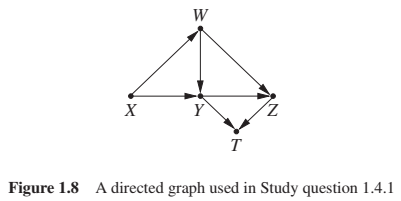

> (a) Name all of the parents of Z.

> (b) Name all the ancestors of Z.

> (c) Name all the children of W.

> (d) Name all the descendants of W.

> (e) Draw all (simple) paths between X and T (i.e., no node should appear more than once).

> (f) Draw all the directed paths between X and T.

### Answer to 1.4.1 a
***Name all parents of Z.***

W, Y

### Answer to 1.4.1 b
***Name all ancestors of Z.***

W, X, Y

### Answer to 1.4.1 c
***Name all the children of W.***

Y, Z

### Answer to 1.4.1 d
***Name all the descendants of W.***

T, Y, Z

### Answer to 1.4.1 e
***Draw all (simple) paths between X and T (i.e., no node should appear more than once).***

* X -> Y -> T
* X -> Y -> Z -> T
* X -> W -> Y -> T
* X -> W -> Z -> T
* X -> W -> Y -> Z -> T
* X -> W -> Z <- Y -> T
* X -> Y <- W -> Z -> T

### Answer to 1.4.1 f
***Draw all the directed paths between X and T.***

* X -> Y -> T
* X -> Y -> Z -> T
* X -> W -> Y -> T
* X -> W -> Z -> T
* X -> W -> Y -> Z -> T

## Question 1.5.1
Suppose we have the following SCM (structural causal model).  Assume all exogenous variables are independent and that the expected value of each is 0.

\

***SCM 1.5.3***

$V=\{X,Y,Z\}, \ U=\{U_X,U_Y,U_Z\}, \ F=\{f_X,f_Y, f_Z\}$
> $f_X: X = U_X$

> $f_Y: Y = \frac{X}{3} + U_Y$

> $f_Z: Z = \frac{Y}{16} + U_Z$

\

(a) Draw the graph that complies with the model.

(b) Determine the best guess of the value (expected value) of $Z$, given that we observe $Y = 3$.

(c) Determine the best guess of the value of $Z$, given that we observe $X = 3$.

(d) Determine the best guess of the value of $Z$, given that we observe $X = 1$ and $Y = 3$.

(e) Assume that all exogenous variables are normally distributed with zero means and unit variance, that is, $𝜎 = 1$.
> (i) Determine the best guess of $X$, given that we observed $Y = 2$.

> (ii) (Advanced) Determine the best guess of $Y$, given that we observed $X = 1$ and $Z = 3$. [Hint: You may wish to use the technique of multiple regression, together with the fact that, for every three normally distributed variables, say $X$, $Y$, and $Z$, we have $E[Y|X = x, Z = z] = R_{YX⋅Z}x + R_{YZ⋅X}z$.]

(f) Determine the best guess of the value of $Z$, given that we know $X = 3$. (This must be a typo, since it's the same as part c).

### Answer to 1.5.1 a
***Draw the graph that complies with the model.***

I'm going to use the [daggity.net](https://www.dagitty.net/dags.html) tool.

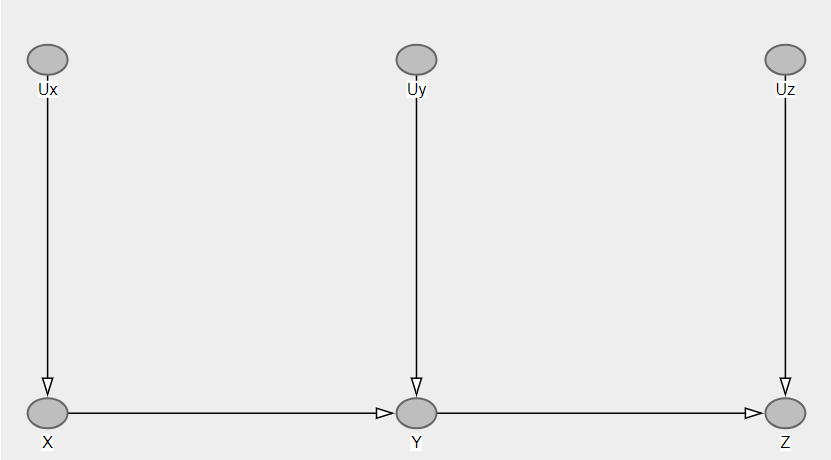

### Answers 1.5.1 b-e
From here on out, part of our answers will include a simulation.  So let's set that up here

In [ ]:
N <- 100000

Ux <- rnorm(n=N, mean=0, sd=1)
X <- Ux

Uy <- rnorm(n=N, mean=0, sd=1)
Y <- X/3 + Uy

Uz <- rnorm(n=N, mean=0, sd=1)
Z <- Y/16 + Uz

df <- data.frame(Ux=Ux, Uy=Uy, Uz=Uz, X=X, Y=Y, Z=Z)

#### Answer to 1.5.1 b
***Determine the best guess of the value (expected value) of $Z$, given that we observe $Y = 3$.***

For this, we need to go back to the equation

$$f_Z: Z = \frac{Y}{16} + U_Z$$

Let's take the expectation when $Y=3$.

$$E[Z|Y=3] = E\left[\frac{Y}{16} + U_Z | Y=3\right] = \frac{1}{16}E[Y|Y=3]+E[U_Z|Y=3] = \frac{3}{16}+0 = \frac{3}{16}$$

where $E[U_Z|Y=3]$ based on the assumption in the question ("Assume all exogenous variables are independent and that the expected value of each is 0.").

As a second approach, let's further assume, as we will be asked to in later parts of the question, that $var[U_X]=var[U_Y]=var[U_Z]=1$.  Then let's answer this question again using regression, where

$$E[Z|Y] = \alpha + \beta_Y Y$$

Recall that $\beta_Y = \frac{cov[Z,Y]}{var[Y]}$ and $\alpha = E[Z] - \beta_Y \times E[Y]$.

> $var[Y] = var\left[\frac{X}{3} + U_Y\right] = \frac{1}{3^2}var[X] + var[U_Y] = \frac{1}{9}(1) + 1 = \frac{10}{9}$

> $cov[Y,Z] = E[YZ] - E[Y]E[Z] = E[Y \times \frac{Y}{16}] - E[Y]E[\frac{Y}{16}] = \frac{1}{16}E[Y^2] - E[Y]\frac{1}{16}E[Y] = \frac{1}{16}(E[Y^2]-E[Y]^2) = \frac{1}{16}var[Y] = \frac{1}{16}\frac{10}{9} = \frac{5}{72}$

> $\beta_Y = \frac{cov[Z,Y]}{var[Y]} = \frac{\frac{5}{72}}{\frac{10}{9}} = \frac{1}{16}$

> $\alpha = E[Z] - \beta_Y E[Y] = E[\frac{Y}{16} + U_Z] - \frac{E[Y]}{16} = \frac{1}{16}E[Y] + E[U_Z] - \frac{1}{16}E[Y] = E[U_Z] = 0$

Hence, $E[Z|Y=3] = 0 + \frac{1}{16}3 = \frac{3}{16}$

We can further simulate this and compare our calculated answers to our simulated answers.

In [ ]:
Z_Y <- lm(Z ~ Y)
#summary(Z_Y)

paste("Calculated Expectation = ", 3/16)
paste("Simulated Expectation = ", coef(Z_Y)[[1]] + coef(Z_Y)[[2]]*3)

paste("Calculated Variance = ", 10/9)
paste("Simulated Variance = ", var(Y))

paste("Calculated Covariance = ", 5/72)
paste("Simulated Covariance = ", cov(Z,Y))

paste("Calculated beta = ", (5/72) / (10/9))
paste("Simulated beta = ", cov(Z,Y)/var(Y))
paste("Regression beta = ", coef(Z_Y)[2])

paste("Calculated alpha = ", 0)
paste("Simulated alpha = ", mean(Z) - mean(Y)*(cov(Z,Y)/var(Y)))
paste("Regression alpha = ", coef(Z_Y)[[1]])

[1] "Calculated Expectation =  0.1875"

[1] "Simulated Expectation =  0.178012644507071"

[1] "Calculated Variance =  1.11111111111111"

[1] "Simulated Variance =  1.09678373004074"

[1] "Calculated Covariance =  0.0694444444444444"

...

[1] "Simulated beta =  0.0596764822870854"

[1] "Regression beta =  0.0596764822870854"

[1] "Calculated alpha =  0"

[1] "Simulated alpha =  -0.00101680235418508"

[1] "Regression alpha =  -0.00101680235418508"

#### Answer to 1.5.1 c
***Determine the best guess of the value (expected value) of $Z$, given that we observe $X = 3$.***

This is similar to part b, but now the given variable $X$ does not directly affect $Z$.  Rather, $X$ affects $Z$ indirectly via $Y$.  So we first need to find the expected value of $Y$ given $X = 3$, then find the expected value of $Z$ given the expected value of $Y$ given $X = 3$.

Take $Z = \frac{Y}{16} + U_Z$ and insert $Y = \frac{x}{3} + U_Y$ to get
> $Z = \frac{\frac{X}{3} + U_Y}{16} + U_Z$

Now take the expectation of $Z$ given $X=3$.

> $E[Z|X=3] = E\left[\frac{\frac{X}{3} + U_Y}{16} + U_Z | X=3\right]
=\frac{1}{16}E[\frac{X}{3} + U_Y|X=3] + E[U_Y|X=3]
=\frac{1}{16}E[\frac{X}{3}|X=3] + \frac{1}{16}E[U_Y|X=3] + 0
=\frac{1}{16}(1) + 0 = \frac{1}{16}$

Let's employ our secondary regression approach as well, as we did for part b.  So we're trying to solve this regression:

$$E[Z|X] = \alpha + \beta_X X$$

Now $\beta_X = \frac{cov[Z,X]}{var[X]}$ and $\alpha = E[Z] - \beta_X \times E[X]$.

> $var[X] = var[U_X] = 1$, by our assumptions.

> $cov[X,Z] = E[XZ] - E[X]E[Z] = E[X \times \frac{\frac{X}{3}}{16}] - 0 \times E[\frac{X^2}{48}] = \frac{1}{48}E[X^2]$

We can get $E[X^2]$ by recognizing that $var[X] = E[X^2] - (E[X])^2$.  Since we have stipulated that $var[X]=1$ and $E[X]=0$, we have $1 = E[X^2] - 0$ such that $E[X^2]=1$.  Therefore

> $cov[X,Z] = \frac{1}{48}$

> $\beta_X = \frac{cov[Z,X]}{var[X]} = \frac{\frac{1}{48}}{1} = \frac{1}{48}$

> $\alpha = E[Z] - \beta_X E[X] = E[\frac{\frac{X}{3} + U_Y}{16} + U_Z] - \frac{1}{48} \times E[X]
= \frac{1}{16}E[\frac{X}{3} + U_Y] + E[U_Z] - \frac{1}{48} \times 0
= \frac{1}{16}E[\frac{X}{3}] + \frac{1}{16}E[U_Y] + 0
= \frac{1}{48}E[X] + \frac{1}{16} \times 0
= \frac{1}{48} \times 0 + 0 = 0$

Hence, $E[Z|X=3] = 0 + \frac{1}{48}3 = \frac{3}{48} = \frac{1}{16}$

In [ ]:
Z_X <- lm(Z ~ X)
#summary(Z_X)

paste("Calculated Expectation = ", 1/16)
paste("Simulated Expectation = ", coef(Z_X)[[1]] + coef(Z_X)[[2]]*3)

paste("Calculated Variance = ", 1)
paste("Simulated Variance = ", var(X))

paste("Calculated Covariance = ", 1/48)
paste("Simulated Covariance = ", cov(Z,X))

paste("Calculated beta = ", 1/48)
paste("Simulated beta = ", cov(Z,X)/var(X))
paste("Regression beta = ", coef(Z_X)[[2]])

paste("Calculated alpha = ", 0)
paste("Simulated alpha = ", mean(Z) - mean(X)*(cov(Z,X)/var(X)))
paste("Regression alpha = ", coef(Z_X)[[1]])

[1] "Calculated Expectation =  0.0625"

[1] "Simulated Expectation =  0.0686676763135149"

[1] "Calculated Variance =  1"

[1] "Simulated Variance =  1.00606010829887"

[1] "Calculated Covariance =  0.0208333333333333"

...

[1] "Simulated beta =  0.0232865522193544"

[1] "Regression beta =  0.0232865522193544"

[1] "Calculated alpha =  0"

[1] "Simulated alpha =  -0.00119198034454839"

[1] "Regression alpha =  -0.00119198034454839"

#### Answer to 1.5.1 d
***Determine the best guess of the value (expected value) of $Z$, given that we observe $X = 1$ and $Y = 3$.***

Parts (b) and (c) show how $Z$ depends on $Y$ (directly) and $X$ (indirectly, via $Y$).  In each part, we were given only $X$ or only $Y$.  But now we're given both.

Since $Z$ depends on $X$ via $Y$, but we're given $Y$, the information about $X$ is irrelevant.  Thus, $E[Z | X=1, Y=3] = E[Z | Y = 3] = \frac{3}{16}$, which is what we found for part (b).

But rather than rely on this line of reasoning, let's confirm this with simulation.  If we're right, then we should expect low p-values for `Y` but high p-values for `X`. We should also get *approximately* the same simulated values as we did from the regression `Z_Y` in part (a). Why only approximately? Because the sampling bias inherent to our random-data generation will inevitably produce non-zero coefficients for `X`; if you run the simulation several times (run all code blocks in the problem except for the `Z_X` regression), you'll notice that some of the estimates for `Z_XY` jump around those for `Z_Y` based on the estimates for `X` and `Y`.  Finally, we should be able to change the value of X and continue to get simular estimates for the expected value of `Z`; again, the larger we make `X` the more wrong our estimate of `Z` will be simply due to the sampling bias that leads to non-zero values for the coefficient of `X`.

In [ ]:
Z_XY <- lm(Z ~ X + Y)

summary(Z_XY)

paste("Simulated Expectation from Z_Y = ", coef(Z_Y)[[1]] + coef(Z_Y)[[2]]*3)
paste("Simulated Expectation from Z_XY (X=1) = ", coef(Z_XY)[[1]] + coef(Z_XY)[[2]]*1 + coef(Z_XY)[[3]]*3)
paste("Simulated Expectation from Z_XY (X=10) = ", coef(Z_XY)[[1]] + coef(Z_XY)[[2]]*10 + coef(Z_XY)[[3]]*3)


Call:
lm(formula = Z ~ X + Y)

Residuals:
    Min      1Q  Median      3Q     Max 
-4.2115 -0.6778 -0.0007  0.6760  4.0998 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept) -0.001037   0.003161  -0.328    0.743    
X            0.004261   0.003317   1.284    0.199    
Y            0.058403   0.003177  18.382   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.9997 on 99997 degrees of freedom
Multiple R-squared:  0.003909,	Adjusted R-squared:  0.00389 
F-statistic: 196.2 on 2 and 99997 DF,  p-value: < 2.2e-16


[1] "Simulated Expectation from Z_Y =  0.178012644507071"

[1] "Simulated Expectation from Z_XY (X=1) =  0.178433201590621"

[1] "Simulated Expectation from Z_XY (X=10) =  0.216779242947022"

#### Answers to 1.5.1 e
***Assume that all exogenous variables are normally distributed with zero means and unit variance, that is, $𝜎 = 1$.***

##### Answers to 1.5.1 e.i
***Determine the best guess of $X$ , given that we observed  $Y=2$***

Let's start by identifying why this problem is unique.  Whereas the previous questions (b-d) asked about the value of a dependent variable given an independent variable (e.g., $E[Y|X]$), this problem is reverse such to estimate the value of the independent variable given the dependent variable.

This time, let's first solve with regression.  
> $E[X|Y] = \alpha + \beta_Y Y$

where $\beta_Y = \frac{cov[X,Y]}{var[Y]}$ and $\alpha = E[X] - \beta_Y \times E[Y]$.

> $var[Y] = var\left[\frac{X}{3} + U_Y\right] = (\frac{1}{3})^2 var[X] + var[U_Y] = \frac{1}{9}(1) + 1 = \frac{10}{9}$

> $cov[X,Y] = E[XY] - E[X]E[Y] = E[X(\frac{X}{3} + U_Y)] - 0(\frac{X}{3}+U_Y) = E[\frac{X^2}{3}] + E[XU_Y] - 0 = \frac{1}{3}E[X^2] + 0 = \frac{1}{3}(1) = \frac{1}{3}$

Thus, $\beta_Y = \frac{1/3}{10/9} = \frac{3}{10}$, $\alpha = 0$ (since $E[X] = E[Y] = 0$) such that $E[X|Y=2] = \frac{3}{10}2 = 0.6$

Let's simulate this as well.

In [ ]:
X_Y <- lm(X ~ Y)

#coef(X_Y)[2]
#cov(X, Y)/var(Y)

paste("Simulated Expectation from X_Y = ", coef(X_Y)[[1]] + coef(X_Y)[[2]]*2)

[1] "Simulated Expectation from X_Y =  0.602472816351575"

Now let's go back to the simple expectation operator.  For this, we need to solve for $X$ from the equation for $Y$, $f_Y: Y = \frac{X}{3} + U_Y$; this is $X = 3Y - 3U_Y$.  Now let's apply the expectation operator, conditioned on $Y=3$.

$$
\begin{aligned}
E[X|Y=2] &= E[3Y-3U_Y|Y=2] \\
         &= E[3Y|Y=2] - E[3U_Y|Y=2] \\
         &= 3E[Y|Y=2] - 3E[U_Y|Y=2] \\
         &= 3 \times 2 - 3 \times ?  = ?\\
\end{aligned}
$$

There is a unique term here, $E[U_Y|Y=2]$.  It is unique for the same reason that $E[X|Y]$ is unique: we are trying to estimate the value of an independent variable ($U_Y$) given the dependent variable ($Y$).  

In some instances--specifically, when the dependent variable is only caused by a single independent variable--this is not a big deal.  For instance, if we had a simple DAG $X \rightarrow Y$, where $ g_Y: Y = 2X $, then $X = \frac{Y}{2}$ such that $E[Y|X=x] = 2x$ and $E[X|Y=y] = \frac{y}{2}$.  But in our present case, the dependent variable $Y$ has two causes, $X$ and $U_Y$.  Now, the value of either independent variable depends on the other independent variable.  Why? because their combined contribution must sum to $Y=2$; if $X=1$ then $U_Y \overset{!}{=} 1$, if $U_Y=\frac{1}{2}$ then $X \overset{!}{=} \frac{3}{2}$.  Therefore, $E[U_Y|Y]$ must depend on the probability distribution of $X$.

There's one way to solve this, which I'll present first, but I don't think it's very illuminative.  For this, you need to know generally for normally-distributed variables:

$$E[a|b] = E[a] + \frac{\sigma_{ab}}{\sigma^2_b}(b - E[b])$$

Applying this here, we get

$$E[U_Y|Y=2] = E[U_Y] + \frac{\sigma_{Y U_Y}}{\sigma^2_Y}(Y - E[Y]) = 0 + \frac{1}{10/9}(2) = 2\frac{9}{10} = \frac{18}{10} = \frac{9}{5} = 1.8$$

where $\sigma_{Y U_Y} = \text{Cov}[Y, U_Y] = \text{Cov}[\frac{X}{3} + U_Y, U_Y] = \text{Cov}[\frac{X}{3}, U_Y] + \text{Cov}[U_Y, U_Y] = 0 + \text{Var}[U_Y] = 1$

So we get $E[U_Y|Y=2] = 1.8$ such that
$$
\begin{aligned}
E[X|Y=2] &= E[3Y-3U_Y|Y=2] \\
         &= E[3Y|Y=2] - E[3U_Y|Y=2] \\
         &= 3E[Y|Y=2] - 3E[U_Y|Y=2] \\
         &= 3 \times 2 - 3 \times 1.8  = 0.6\\
\end{aligned}
$$  
which matches the regression method.

But like I said, this doesn't really illustrate the relationship between $X$ and $U_Y$ that is induced by conditioning on $Y=2$.

We can see this relationship in a few ways.  For instance, let's plot $Y \sim U_Y$ from our sample data, and color $X$ such that small-to-large values are coded from red to green.

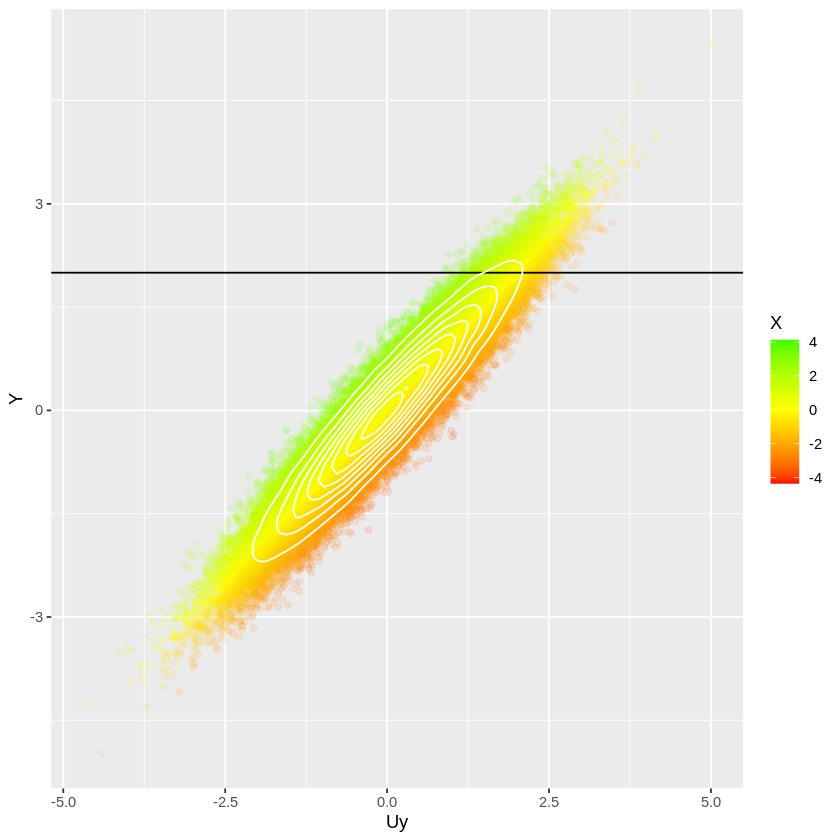

In [ ]:
library(ggplot2)

y <- 2

ggplot(df, aes(x = Uy, y = Y, color=X)) +
  geom_point(alpha = 0.1) +
  scale_color_gradient2(low = "red", mid="yellow", high = "green") +
  geom_hline(yintercept=y, color="black", linetype="solid") +
  geom_density_2d(color = "white")


Notice that, at $Y=2$, we need larger values for $X$ (green) for smaller values of $U_Y$.

Let's take a different view.  We'll plot the joint distribution for $X$ and $U_Y$, then color-code $Y$ such that $Y=2$ is bright red while more distant values become increasingly black.  I'll also add a line exactly for $Y=2$.

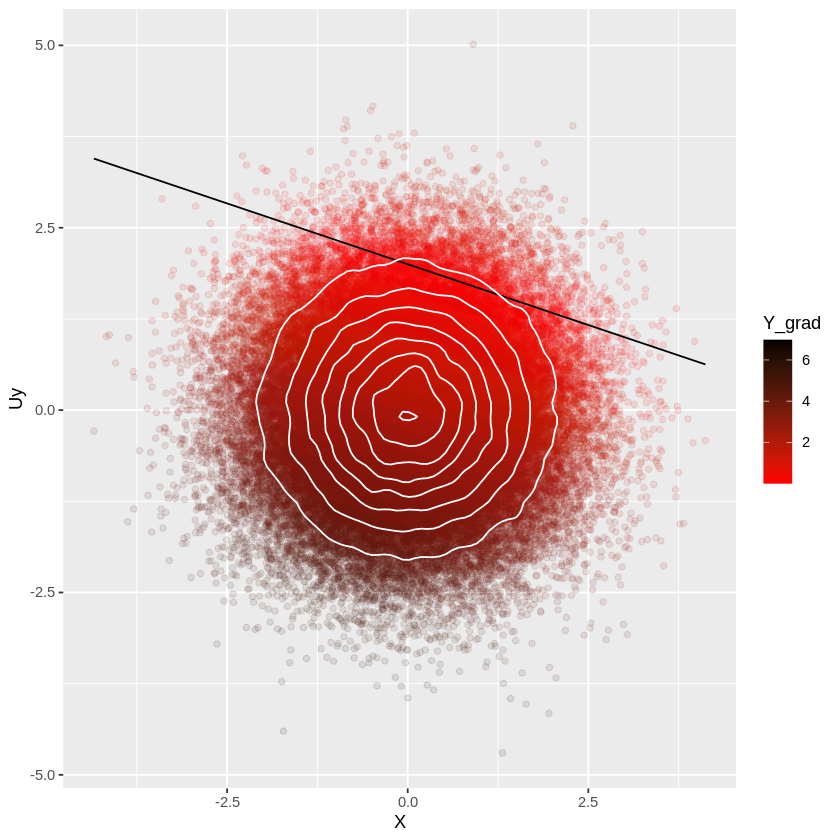

In [ ]:
Y_grad <- abs(Y-y)
curve_data <- data.frame(
  X = seq(min(df$X), max(df$X), length.out = 100),
  Uy = y - seq(min(df$X), max(df$X), length.out = 100) / 3
)

ggplot(df, aes(x = X, y = Uy, color=Y_grad)) +
  geom_point(alpha = 0.1) +
  scale_color_gradient(low = "red", high = "black") +
  geom_line(data = curve_data, aes(x = X, y = Uy), color = "black", linetype = "solid") +
  geom_density_2d(color = "white")

Notice again that $X$ and $U_Y$ are on a bit of a teeter-totter--higher values for one require a smaller value for the other.  The slope of the $Y=2$ line is the conditional relationship between $X$ and $U_Y$ (conditioned on $Y=2$).

Hence, we must account for the joint probability distribution between $X$ and $U_Y$.  Let's do that.  We'll find the joint distribution, then draw sample of $U_Y$ according to that distribution.

[1] 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 [38] 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 [75] 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
[112] 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
[149] 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
[186] 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
[223] 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
[260] 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
[297] 2 2 2 2

[1] 1.809231

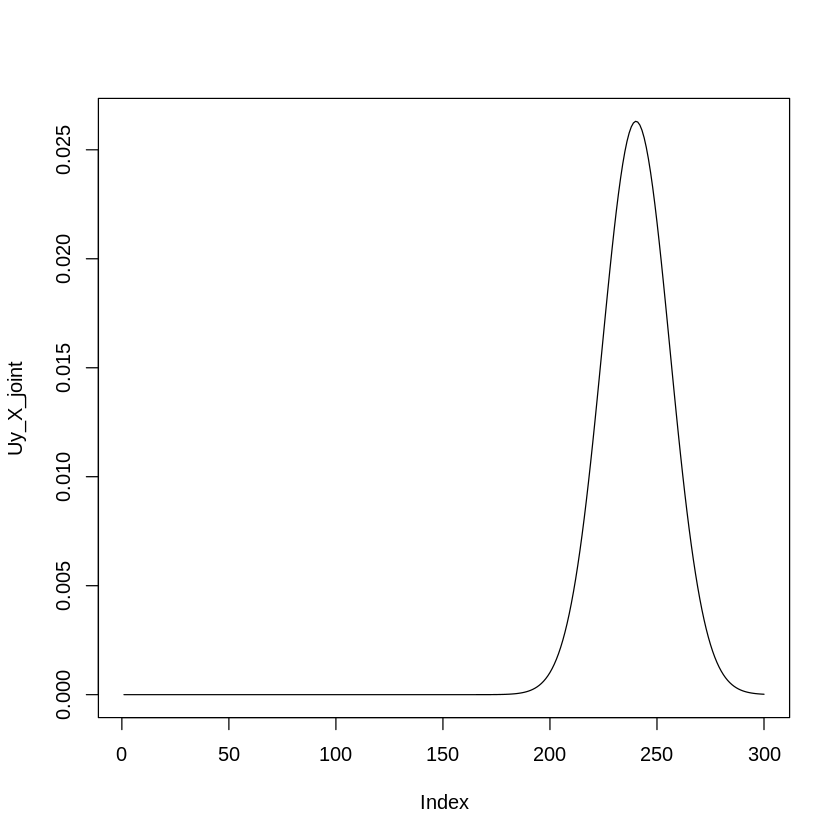

In [ ]:
#library(MASS)

Uy_seq <- seq(from=-3, to=3, length.out=300)
X_seq <- 3*(y-Uy_seq)
(Uy_X_sum <- (X_seq/3) + Uy_seq) # the sum of X_seq and Uy_seq will always = 2

# Since X and Uy are independent, we can make their joint distribution by simply multiplying their individual distributions
Uy_X_joint <- dnorm(Uy_seq) * dnorm(X_seq)

# Visualize the joint probability distribution.
plot(Uy_X_joint, type="l")

# Sample Uy (and X) in proportion to their joint probability distribution
Uy_samples <- sample(Uy_seq, 10000, replace=TRUE, prob=Uy_X_joint)
X_samples <- sample(Uy_seq, 10000, replace=TRUE, prob=Uy_X_joint)

# find E[Uy|Y=2]
mean(Uy_samples)
#mean(X_samples)

So $E[U_Y|Y=2] \approx 1.8$--which matches the analytic solution.

##### Answers to 1.5.1 e.ii
***(Advanced) Determine the best guess of $Y$, given that we observed $X = 1$ and $Z = 3$. [Hint: You may wish to use the technique of multiple regression, together with the fact that, for every three normally distributed variables, say $X$, $Y$, and $Z$, we have $E[Y|X = x, Z = z] = R_{YX⋅Z}x + R_{YZ⋅X}z$.]***

As per our hint, we should calculate $\beta_{X} = R_{YX⋅Z}$, the regression coefficient for the relation between $X$ and $Y$ conditioned on holding $Z$ constant, and $\beta_{Z} = R_{YZ⋅X}$.  These formulas are given in the book in equations 1.27 and 1.28.

$$\beta_{X} = \frac{\sigma_{YX} \sigma^2_Z - \sigma_{XZ} \sigma_{YZ}}{\sigma^2_X \sigma^2_Z - \sigma^2_{XZ}}$$

$$\beta_{Z} = \frac{\sigma_{YZ} \sigma^2_X - \sigma_{XZ} \sigma_{YX}}{\sigma^2_X \sigma^2_Z - \sigma^2_{XZ}}$$

Using the values we've already found, these expressions become

$$\beta_{X} = \frac{\frac{1}{3} \sigma^2_Z - \frac{1}{48} \frac{5}{72}}{(1) \sigma^2_Z - (\frac{1}{48})^2}$$

$$\beta_{Z} = \frac{\frac{5}{72}(1) - \frac{1}{48} \frac{1}{3}}{(1) \sigma^2_Z - (\frac{1}{48})^2}$$

Let's solve for the missing term:
$$
\begin{aligned}
\text{Var}[Z] &= \text{Var}\left[\frac{Y}{16} + U_Z \right] \\
&= \text{Var}\left[\frac{Y}{16} \right] + \text{Var}[U_Z] \\
&= \left(\frac{1}{16} \right)^2\text{Var}[Y] + 1 \\
&= \left(\frac{1}{16} \right)^2 \frac{10}{9} + 1 = \frac{10}{2304} + 1 = \frac{2314}{2304}
\end{aligned}
$$

Plugging this into our equations:

$$\beta_{X} = \frac{\frac{1}{3} \frac{2314}{2304} - \frac{1}{48} \frac{5}{72}}{(1) \frac{2314}{2304} - (\frac{1}{48})^2} \approx 0.33 $$

$$\beta_{Z} = \frac{\frac{5}{72}(1) - \frac{1}{48} \frac{1}{3}}{(1) \frac{2314}{2304} - (\frac{1}{48})^2} \approx 0.06$$

such that

$$E[Y|X = 1, Z = 3] \approx 0.33(1) + 0.06(3) \approx 0.52$$

In [ ]:
b_X <- ((1/3 * 2314/2304) - (1/48 * 5/72)) / (2314/2304 - (1/48)^2)
b_Z <- ((5/72) - (1/48 * 1/3)) / (2314/2304 - (1/48)^2)

x=1
z=3

x*b_X + z*b_Z

[1] 0.5188067

Let's check this with simulation.

In [ ]:
Y_XZ <- lm(Y ~ 0 + X + Z)
summary(Y_XZ)
coef(Y_XZ)[[1]]*1 + coef(Y_XZ)[[2]]*3


Call:
lm(formula = Y ~ 0 + X + Z)

Residuals:
    Min      1Q  Median      3Q     Max 
-4.8069 -0.6759 -0.0069  0.6704  5.0448 

Coefficients:
  Estimate Std. Error t value Pr(>|t|)    
X 0.324413   0.003133  103.56   <2e-16 ***
Z 0.057663   0.003137   18.38   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.9933 on 99998 degrees of freedom
Multiple R-squared:  0.1004,	Adjusted R-squared:  0.1004 
F-statistic:  5579 on 2 and 99998 DF,  p-value: < 2.2e-16


[1] 0.4974028

## Question 1.5.2
Assume that a population of patients contains a fraction $r$ of individuals who suffer from a certain fatal syndrome $Z$, which simultaneously makes it uncomfortable for them to take a life-prolonging drug $X$ (Figure 1.10). Let $Z = z_1$ and $Z = z_0$ represent, respectively, the presence and absence of the syndrome, $Y = y_1$ and $Y = y_0$ represent death and survival, respectively, and $X = x_1$ and $X = x_0$ represent taking and not taking the drug. Assume that patients not carrying the syndrome, $Z = z_0$, die with probability $p_2$ if they take the drug and with probability $p_1$ if they don’t. Patients carrying the syndrome, $Z = z_1$, on the other hand, die with probability $p_3$ if they do not take the drug and with probability $p_4$ if they do take the drug. Further, patients having the syndrome are more likely to avoid the drug, with probabilities $q_1 = P(x_1|z_0)$ and $q_2 = p(x_1|z_1)$.

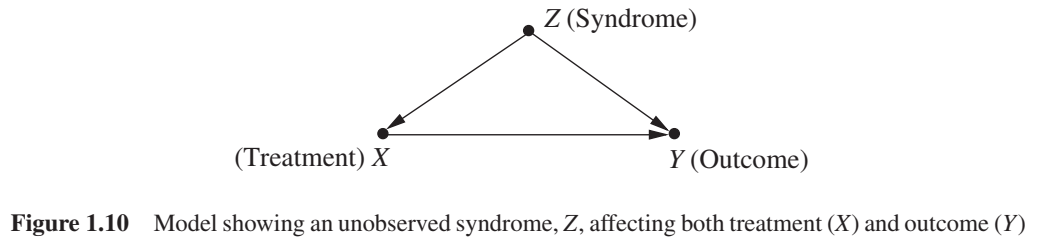

> (a) Based on this model, compute the joint distributions $P(x,y,z)$, $P(x, y)$, $P(x,z)$, and $P(y,z)$ for all values of $x$, $y$, and $z$, in terms of the parameters $(r, p1, p2, p3, p4, q1, q2)$. [Hint: Use the product decomposition of Section 1.5.2.]

> (b) Calculate the difference $P(y_1|x_1) - P(y_1|x_0)$ for three populations:
> 1. those carrying the syndrome,
> 2. those not carrying the syndrome, and
> 3.the population as a whole.

> (c) Using your results for (b), find a combination of parameters that exhibits Simpson’s reversal.

### Answer to 1.5.2 a
***Based on this model, compute the joint distributions $P(x,y,z)$, $P(x, y)$, $P(x,z)$, and $P(y,z)$ for all values of $x$, $y$, and $z$, in terms of the parameters $(r, p1, p2, p3, p4, q1, q2)$. [Hint: Use the product decomposition of Section 1.5.2.]***

Okay, let's decompose:
> $p(X, Y, Z) = p(Z) p(X|Z) p(Y|X, Z)$

>> $p(Z)$

>>> $p(Z=1) = p(Z_1) = r$

>>> $p(Z=0) = p(Z_0) = 1-r$


>> $p(X|Z)$

>>> $p(X=1|Z_0) = p(X_1|Z_0) = q_1$

>>> $p(X=0|Z_0) = p(X_0|Z_0) = 1-q_1$

>>> $p(X=1|Z_1) = p(X_1|Z_1) = q_2$

>>> $p(X=0|Z_1) = p(X_0|Z_1) = 1-q_2$

>> $p(Y|X,Z)$

>>> $p(Y=1|X_0, Z_0) = p(Y_1|X_0, Z_0) = p_1$

>>> $p(Y=0|X_0, Z_0) = p(Y_1|X_0, Z_0) = 1-p_1$

>>> $p(Y=1|X_1, Z_0) = p(Y_1|X_1, Z_0) = p_2$

>>> $p(Y=0|X_1, Z_0) = p(Y_1|X_1, Z_0) = 1-p_2$

>>> $p(Y=1|X_0, Z_1) = p(Y_1|X_0, Z_1) = p_3$

>>> $p(Y=0|X_0, Z_1) = p(Y_1|X_0, Z_1) = 1-p_3$

>>> $p(Y=1|X_1, Z_1) = p(Y_1|X_1, Z_1) = p_4$

>>> $p(Y=0|X_1, Z_1) = p(Y_1|X_1, Z_1) = 1-p_4$

Now, to get any joint distribution, we just substitute the correct terms.

> $p(X_0, Y_0, Z_0) = p(Z_0) p(X_0|Z_0) p(Y_0|X_0, Z_0) = (1-r)(1-q_1)(1-p_1)$

> $p(X_0, Y_0, Z_1) = p(Z_1) p(X_0|Z_1) p(Y_0|X_0, Z_1) = r(1-q_2)(1-p_3)$

> $p(X_0, Y_1, Z_0) = p(Z_0) p(X_0|Z_0) p(Y_1|X_0, Z_0) = (1-r)(1-q_1)p_1$

> $p(X_0, Y_1, Z_1) = p(Z_1) p(X_0|Z_01) p(Y_1|X_0, Z_1) = r(1-q_2)p_3$

> $p(X_1, Y_0, Z_0) = p(Z_0) p(X_1|Z_0) p(Y_1|X_1, Z_0) = (1-r)q_1(1-p_2)$

> $p(X_1, Y_0, Z_1) = p(Z_1) p(X_1|Z_1) p(Y_0|X_1, Z_1) = rq_2(1-p_4)$

> $p(X_1, Y_1, Z_0) = p(Z_0) p(X_1|Z_0) p(Y_1|X_1, Z_0) = (1-r)q_1p_2$

> $p(X_1, Y_1, Z_1) = p(Z_1) p(X_1|Z_1) p(Y_1| X_1 Z_1) = r q_2 p_4$

If we want the joint distribution of only 2 variables, say $X$ and $Y$, we need to *marginalize* over all values of the omitted variable ($Z$) like

$p(X, Y) = \sum_{Z=0}^{Z=1} p(X, Y, Z)$

> $\begin{aligned}
p(X_0, Y_0) &= p(X_0, Y_0, Z_0) + p(X_0, Y_0, Z_1) \\
&= p(Z_0) p(X_0|Z_0) p(Y_0|X_0, Z_0) + p(Z_1) p(X_0|Z_1) p(Y_0|X_0, Z_1) \\
&= (1-r)(1-q_1)(1-p_1) + r(1-q_1)(1-p_1) \\
\end{aligned}$

> $\begin{aligned}
p(X_0, Y_1) &= p(X_0, Y_1, Z_0) + p(X_0, Y_1, Z_1) \\
&= p(Z_0) p(X_0|Z_0) p(Y_1|X_0, Z_0) + p(Z_1) p(X_0|Z_1) p(Y_1|X_0, Z_1) \\
&= (1-r)(1-q_1)p_1 + r(1-q_2)p_3 \\
\end{aligned}$

> $\begin{aligned}
p(X_1, Y_0) &= p(X_1, Y_0, Z_0) + p(X_1, Y_0, Z_1) \\
&= p(Z_0) p(X_1|Z_0) p(Y_0|X_1, Z_0) + p(Z_1) p(X_1|Z_1) p(Y_0|X_1, Z_1) \\
&= (1-r)q_1(1-p_2) + rq_2(1-p_4) \\
\end{aligned}$

> $\begin{aligned}
p(X_1, Y_1) &= p(X_1, Y_1, Z_0) + p(X_1, Y_1, Z_1) \\
&= p(Z_0) p(X_1|Z_0) p(Y_1|X_1, Z_0) + p(Z_1) p(X_1|Z_1) p(Y_1|X_1, Z_1) \\
&= (1-r)q_1p_2 + rq_2p_4 \\
\end{aligned}$

\

$p(X, Z) = \sum_{Y=0}^{Y=1} p(X, Y, Z)$

> $\begin{aligned}
p(X_0, Z_0) &= p(X_0, Y_0, Z_0) + p(X_0, Y_1, Z_0) \\
&= p(Z_0) p(X_0|Z_0) p(Y_0|X_0, Z_0) + p(Z_0) p(X_0|Z_0) p(Y_1|X_0, Z_0) \\
&= (1-r)(1-q_1)(1-p_1) + (1-r)(1-q_1)p_1 \\
\end{aligned}$

> $\begin{aligned}
p(X_0, Z_1) &= p(X_0, Y_0, Z_1) + p(X_0, Y_1, Z_1) \\
&= p(Z_1) p(X_0|Z_1) p(Y_0|X_0, Z_1) + p(Z_1) p(X_0|Z_1) p(Y_1|X_0, Z_1) \\
&= r(1-q_2)(1-p_3) + r(1-q_2)p_3 \\
\end{aligned}$

> $\begin{aligned}
p(X_1, Z_0) &= p(X_1, Y_0, Z_0) + p(X_1, Y_1, Z_0) \\
&= p(Z_0) p(X_1|Z_0) p(Y_0|X_1, Z_0) + p(Z_0) p(X_1|Z_0) p(Y_1|X_1, Z_0) \\
&= (1-r)q_1(1-p_2) + (1-r)q_1p_2 \\
\end{aligned}$

> $\begin{aligned}
p(X_1, Z_1) &= p(X_1, Y_0, Z_1) + p(X_1, Y_1, Z_1) \\
&= p(Z_0) p(X_1|Z_1) p(Y_0|X_1, Z_1) + p(Z_1) p(X_1|Z_1) p(Y_1|X_1, Z_1) \\
&= rq_2(1-p_4) + rq_2p_4 \\
\end{aligned}$

\

$p(Y, Z) = \sum_{X=0}^{X=1} p(X, Y, Z)$

> $\begin{aligned}
p(Y_0, Z_0) &= p(X_0, Y_0, Z_0) + p(X_1, Y_0, Z_0) \\
&= p(Z_0) p(X_0|Z_0) p(Y_0|X_0, Z_0) + p(Z_0) p(X_1|Z_0) p(Y_0|X_1, Z_0) \\
&= (1-r)(1-q_1)(1-p_1) + (1-r)q_1(1-p_2) \\
\end{aligned}$

> $\begin{aligned}
p(Y_0, Z_1) &= p(X_0, Y_0, Z_1) + p(X_1, Y_0, Z_1) \\
&= p(Z_1) p(X_0|Z_1) p(Y_0|X_0, Z_1) + p(Z_1) p(X_1|Z_1) p(Y_0|X_1, Z_1) \\
&= r(1-q_2)(1-p_3) + rq_2(1-p_4) \\
\end{aligned}$

> $\begin{aligned}
p(Y_1, Z_0) &= p(X_0, Y_1, Z_0) + p(X_1, Y_1, Z_0) \\
&= p(Z_0) p(X_0|Z_0) p(Y_1|X_0, Z_0) + p(Z_0) p(X_1|Z_0) p(Y_1|X_1, Z_0) \\
&= (1-r)(1-q_1)p_1 + (1-r)q_1p_2 \\
\end{aligned}$

> $\begin{aligned}
p(Y_1, Z_1) &= p(X_0, Y_1, Z_1) + p(X_1, Y_1, Z_1) \\
&= p(Z_1) p(X_0|Z_1) p(Y_1|X_0, Z_1) + p(Z_1) p(X_1|Z_1) p(Y_1|X_1, Z_1) \\
&= r(1-q_2)p_3 + rq_2p_4 \\
\end{aligned}$

### Answer to 1.5.2 b
***Calculate the difference $P(y_1|x_1) - P(y_1|x_0)$ for three populations:***
> ***1. those carrying the syndrome,***

> ***2. those not carrying the syndrome, and***

> ***3.the population as a whole.***

Just so that we don't lose the plot, we're being asked to compare the probability of death ($y_1$) for those that took the treatment ($x_1$) vs those that did NOT take the treatment ($x_0$) across three different groups.

***1. those carrying the syndrome***

$p(y_1|x_1, z_1) - p(y_1|x_0, z_1) = p_4 - p_3$

***2. those not carrying the syndrome***

$p(y_1|x_1, z_0) - p(y_1|x_0, z_0) = p_2 - p_1$

***3.the population as a whole***

The first two were straightforward because we were looking at very-defined groups (with or without the syndrome).  But now we're asked about the entire population irrespective of syndrome status.  For this, we need to apply Bayes' Theorem and use some of the marginal probabilities we found in part a.

$\begin{aligned}
p(y_1|x_1) - p(y_1|x_0) &= \frac{p(x_1, y_1)}{p(x_1)} - \frac{p(x_0, y_1)}{p(x_0)} \\
&= \frac{p(x_1, y_1)}{p(x_1, y_1) + p(x_1, y_0)} - \frac{p(x_0, y_1)}{p(x_0, y_1) + p(x_0, y_0)} \\
&= \frac{(1-r)q_1p_2 + rq_2p_4}{((1-r)q_1p_2 + rq_2p_4)+((1-r)q_1(1-p_2) + rq_2(1-p_4))} - \frac{(1-r)(1-q_1)p_1 + r(1-q_2)p_3}{((1-r)(1-q_1)p_1 + r(1-q_2)p_3)+((1-r)(1-q_1)(1-p_1) + r(1-q_1)(1-p_1))}\\
\end{aligned}$

### Answer to 1.5.2, c
***Using your results for (b), find a combination of parameters that exhibits Simpson’s reversal.***

Remember that *Simpson's reversal* is a situation in which the inclusion or exclusion of a given variable reverses the sign (+\-) of an estimate.

An example of this would be if $p(y_1|x_1, z_1) - p(y_1|x_0, z_1) > 0$, but $p(y_1|x_1) - p(y_1|x_0) < 0$.  Whether a reversal would occur depends on the exact values of these terms.

## Question 1.5.3
Consider a graph $X_1 → X_2 → X_3 → X_4$ of binary random variables, and assume that the conditional probabilities between any two consecutive variables are given by

$$\begin{aligned}
& P(X_i = 1|X_{i−1} = 1) = p \\
& P(X_i = 1|X_{i−1} = 0) = q \\
& P(X_1 = 1) = p_0 \\
\end{aligned}$$

Compute the following probabilities

$$\begin{aligned}
& P(X_1 = 1, X_2 = 0, X_3 = 1, X_4 = 0) \\
& P(X_4 = 1|X_1 = 1) \\
& P(X_1 = 1|X_4 = 1) \\
& P(X_3 = 1|X_1 = 0, X_4 = 1) \\
\end{aligned}$$

### Answers

***$P(X_1 = 1, X_2 = 0, X_3 = 1, X_4 = 0)$***

Let's start by decomposing this according to our DAG.

$$P(X_1 = 1, X_2 = 0, X_3 = 1, X_4 = 0) = p(X_1=1) p(X_2=0|X_1=1) p(X_3=1|X_1=1, X_2=0) p(X_4=0|X_1=1, X_2=0, X_3=1)$$

We can simplify this when we recognize that each conditional probabilty $X_i$ only depends on the previous probability $X_{i-1}$.

$$P(X_1 = 1, X_2 = 0, X_3 = 1, X_4 = 0) = p(X_1=1) p(X_2=0|X_1=1) p(X_3=1|X_2=0) p(X_4=0|X_3=1)$$

Now we apply the probabilities provided to us in the question:

$$
\begin{aligned}
P(X_1 = 1, X_2 = 0, X_3 = 1, X_4 = 0) &= p(X_1=1) p(X_2=0|X_1=1) p(X_3=1|X_2=0) p(X_4=0|X_3=1) \\
&= p_0 \ (1-p) \ q \ (1-p) \\
&= p_0 \ (1-p)^2 q
\end{aligned}
$$


***$P(X_4 = 1|X_1 = 1)$***

You can see how this might be tricky: we want the conditional probability of the final variable in our DAG, $X_4$, given the first probability, $X_1$.  This is tricky because each mediating variable, $X_2$ and $X_3$, will take on values probabilistically.

To start, let's make our expression more explicit--which will include marginalizing over the mediating variables.

$$
\begin{aligned}
P(X_4 = 1|X_1 = 1) &= \frac{p(X_1=1, X_4=1)}{p(X_1=1)} \\
&= \frac{\sum_{X_2=0}^{1} \sum_{X_3=0}^{1} p(X_1=1, X_2, X_3, X_4=1)}{p(X_1=1)} \\
&= \frac{
p(X_1=1, X_2=0, X_3=0, X_4=1) + \\
p(X_1=1, X_2=1, X_3=0, X_4=1) + \\
p(X_1=1, X_2=0, X_3=1, X_4=1) + \\
p(X_1=1, X_2=1, X_3=1, X_4=1)
}{p(X_1=1)} \\
&= \frac{
p(X_1=1)p(X_2=0|X_1=1)p(X_3=0|X_2=0)p(X_4=1|X_3=0) + \\
p(X_1=1)p(X_2=1|X_1=1)p(X_3=0|X_2=1)p(X_4=1|X_3=0) + \\
p(X_1=1)p(X_2=0|X_1=1)p(X_3=1|X_2=0)p(X_4=1|X_3=1) + \\
p(X_1=1)p(X_2=1|X_1=1)p(X_3=1|X_2=1)p(X_4=1|X_3=1)
}{p(X_1=1)} \\
&= \frac{
p_0 (1-p) (1-q) q + \\
p_0 p (1-p) q  + \\
p_0 (1-p) q p + \\
p_0 p p p
}{p_0} \\
&= \frac{
p_0 (1-p) (1-q) q + \\
2p_0 p (1-p) q  + \\
p_0 p^3
}{p_0} \\
\end{aligned}
$$

***$P(X_1 = 1|X_4 = 1)$***

Now we do the reverse of what we just did.  The numerator will be the same; the only difference is that the denominator is no longer $p_0$; it is $p(X_4=1)$.  We'll need to marginalize over all other variables to find this.

$$
\begin{aligned}
P(X_4 = 1|X_1 = 1) &= \frac{p(X_1=1, X_4=1)}{p(X_1=1)} \\
&= \frac{\sum_{X_2=0}^{1} \sum_{X_3=0}^{1} p(X_1=1, X_2, X_3, X_4=1)}{p(X_4=1)} \\
&= \frac{
p_0 (1-p) (1-q) q + 2p_0 p (1-p) q  + p_0 p^3}{\sum_{X_1=0}^{1} \sum_{X_2=0}^{1} \sum_{X_3=0}^{1} p(X_1, X_2, X_3, X_4=1)} \\
\end{aligned}
$$

Let's pull out the denomiator so it's easier to focus.

$$
\begin{aligned}
p(X_4=1) &=  \sum_{X_1=0}^{1} \sum_{X_2=0}^{1} \sum_{X_3=0}^{1} p(X_1, X_2, X_3, X_4=1) \\
&= {
  p(X_1=0, X_2=0, X_3=0, X_4=1) + \\
  p(X_1=1, X_2=0, X_3=0, X_4=1) + \\
  p(X_1=0, X_2=1, X_3=0, X_4=1) + \\
  p(X_1=0, X_2=0, X_3=1, X_4=1) + \\
  p(X_1=1, X_2=1, X_3=0, X_4=1) + \\
  p(X_1=1, X_2=0, X_3=1, X_4=1) + \\
  p(X_1=0, X_2=1, X_3=1, X_4=1) + \\
  p(X_1=1, X_2=1, X_3=1, X_4=1) \\
} \\
&= {
  p(X_1=0)p(X_2=0|X_1=0)p(X_3=0|X_2=0)p(X_4=1|X_3=0) + \\
  p(X_1=1)p(X_2=0|X_1=1)p(X_3=0|X_2=0)p(X_4=1|X_3=0) + \\
  p(X_1=0)p(X_2=1|X_1=0)p(X_3=0|X_2=1)p(X_4=1|X_3=0) + \\
  p(X_1=0)p(X_2=0|X_1=0)p(X_3=1|X_2=0)p(X_4=1|X_3=1) + \\
  p(X_1=1)p(X_2=1|X_1=1)p(X_3=0|X_2=1)p(X_4=1|X_3=0) + \\
  p(X_1=1)p(X_2=0|X_1=1)p(X_3=1|X_2=0)p(X_4=1|X_3=1) + \\
  p(X_1=0)p(X_2=1|X_1=0)p(X_3=1|X_2=1)p(X_4=1|X_3=1) + \\
  p(X_1=1)p(X_2=1|X_1=1)p(X_3=1|X_2=1)p(X_4=1|X_3=1) + \\
} \\
&= {
  (1-p_0) (1-q) (1-q) q + \\
  p_0 (1-p) (1-q) q + \\
  (1-p_0) q (1-p) (1-q) + \\
  (1-p_0) (1-q) q p + \\
  p_0 p (1-p) q + \\
  p_0 (1-p) q p + \\
  (1-p_0) q p p + \\
  p_0 p p p \\
} \\
\end{aligned}
$$

So,

$$
\begin{aligned}
P(X_4 = 1|X_1 = 1) &= \frac{p_0 (1-p) (1-q) q + 2p_0 p (1-p) q  + p_0 p^3}{{
  (1-p_0) (1-q)^2 q + p_0 (1-p) (1-q) q + (1-p_0) q (1-p) (1-q) + (1-p_0) (1-q) q p + p_0 p (1-p) q + p_0 (1-p) q p + (1-p_0) q p^2 + p_0 p^3 \\
}} \\
\end{aligned}$$

This could probably be simplified, but you get the idea.

***$P(X_3 = 1|X_1 = 0, X_4 = 1)$***

$$
\begin{aligned}
P(X_3 = 1|X_1 = 0, X_4 = 1) &= \frac{p(X_1=0, X_3=1, X_4=1)}{p(X_1=0, X_4=1)} \\
&= \frac{\sum_{X_2} p(X_1=0, X_2, X_3=1, X_4=1)}{\sum_{X_2} \sum_{X_3} p(X_1=0, X_2, X_3, X_4=1)}
\end{aligned}
$$

Let's take the numerator and denominator in turn.

$$
\begin{aligned}
\sum_{X_2} p(X_1=0, X_2, X_3=1, X_4=1) &= {p(X_1=0, X_2=0, X_3=1, X_4=1) + \\
           p(X_1=0, X_2=1, X_3=1, X_4=1) \\} \\
&= {p(X_1=0) p(X_2=0|X_1=0) p(X_3=1|X_2=0) p(X_4=1|X_3=1) + \\
  p(X_1=0) p(X_2=1|X_1=0) p(X_3=1|X_2=1) p(X_4=1|X_3=1) \\} \\
&= (1-p_0) (1-q) q p + (1-p_0) q p p \\
\end{aligned}
$$

\

$$
\begin{aligned}
\sum_{X_2} \sum_{X_3} p(X_1=0, X_2, X_3, X_4=1) &= {p(X_1=0, X_2=0, X_3=0, X_4=1) + \\
p(X_1=0, X_2=1, X_3=0, X_4=1) + \\
p(X_1=0, X_2=0, X_3=1, X_4=1) + \\
p(X_1=0, X_2=1, X_3=1, X_4=1) \\} \\
&= {p(X_1=0) p(X_2=0|X_1=0) p(X_3=0|X_2=0) p(X_4=1|X_3=0) + \\
    p(X_1=0) p(X_2=1|X_1=0) p(X_3=0|X_2=1) p(X_4=1|X_3=0) + \\
    p(X_1=0) p(X_2=0|X_1=0) p(X_3=1|X_2=0) p(X_4=1|X_3=1) + \\
    p(X_1=0) p(X_2=1|X_1=0) p(X_3=1|X_2=1) p(X_4=1|X_3=1) \\} \\
&= {(1-p_0) (1-q) (1-q) (q) + \\
    (1-p_0) q (1-q) q + \\
    (1-p_0) (1-q) q p + \\
    (1-p_0) q p p} \\
\end{aligned}
$$

So,

$$
\begin{aligned}
P(X_3 = 1|X_1 = 0, X_4 = 1) &= \frac{(1-p_0) (1-q) q p + (1-p_0) q p^2}{(1-p_0) (1-q)^2 q + (1-p_0) q^2 (1-q) + (1-p_0) (1-q) q p + (1-p_0) q p^2} \\
\end{aligned}
$$

## Question 1.5.4
Define the structrual model that corresponds to the Monty Hall problem, and use it to describe the joint distribution of all variables.

### Answer to Question 1.5.4

Recall that the *Monty-Hall problem* is this:
> You are on a game show.  You are asked to pick 1 of 3 doors.  Behind 1 door is a brand new car ($Y$); behind the other 2 doors are goats.  You pick one of the doors ($X$); before seeing what prize it's concealing, the host (Monty Hall) opens one of the doors you didn't pick ($Z$), inevitably revealing a goat, and asks if you'd like to switch your pick to other unopened door.  Should you switch?

Without giving an explanation yet, the answer is "Yes, you should always switch".  This is counterintuitive, which is why we're asked to analyze it with a structural model. Our SCM may look like

$$V = \{X, Y, Z\}, \ U = \{U_X, U_Y, U_Z\}$$
$$X = U_X, \ Y = U_Y, \ Z = f(X, Y, U_Z)$$

The corresponding DAG may look like:

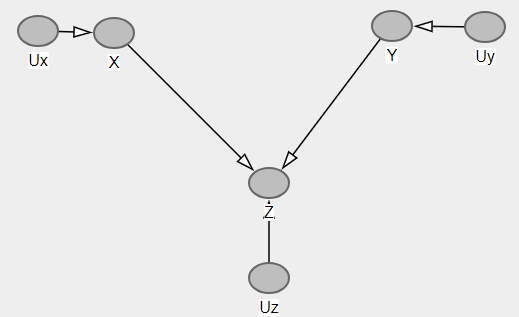

We want to know if we should switch our door.  Another way to say this is we want to know if $p(X=Y|Z) > p(X \not = Y|Z)$.  If so, we should NOT switch; otherwise, we SHOULD switch.

Let's get a handle on this by decomposing the joint probability distribution.

$$p(X, Y, Z) = p(Y) p(X) p(Z|Y, X)$$

Notice that neither $p(X)$ nor $p(Y)$ are conditional on other variables.  This should make sense: the door behind which the car is hiding ($Y$) was selected before we made our pick ($X$) and before Monty Hall opened a door ($Z$), and we made our pick without knowing where the car was ($Y$) and before Monty Hall opened a door ($Z$).

Since each door is equally likely to be hiding the car, $p(Y=y) = \frac{1}{3}$.  Similarly, since we are equally likely to initially pick each door, $p(X=x) = \frac{1}{3}$.

Now the interesting term, $p(Z|Y, X)$.  This term is necessarily conditional because Monty Hall will not opend the door we selected ($X$) and will not open the door hiding the car ($Y$).  Hence, $p(Z=x|X=x, Y=y) + p(Z=y|X=x, Y=y) = 0$.

When $X \not = Y$, the host MUST open the only remaining door: $p(Z \not = X \text{ or } Y | X=x, Y=y, X \not = Y) = 1$.  Otherwise, when $X=Y$, the host can choose from the two remaining doors: $p(Z=z|X=x, Y=y, x=y) = \frac{1}{2}$.

Now, $p(X=Y) = \sum_{door=1}^3 \frac{1}{3} \frac{1}{3} = \frac{1}{3}$.  This means that $\frac{1}{3}$ you should NOT switch, but $\frac{2}{3}$ you should switch.

# Chapter 2

## Question 2.3.1

(a) List all pairs of variables in Figure 2.5 that are independent conditional on the set $Z = \{R, V\}$.

\

***Figure 2.5***  *A directected graph for demonstrating conditional independence (error terms are not shown explicitly)*
$$X → R → S → T ← U ← V ← Y$$

\

(b) For each pair of nonadjacent variables in Figure 2.5, give a set of variables that, when conditioned on, renders that pair independent.

(c) List all pairs of variables in Figure 2.6 that are independent conditional on the set $Z = \{R, P\}$.

\

***Figure 2.6***  *A directed graph in which P is a descendant of a collider*
$$X → R → S → T ← U ← V ← Y$$
$$\downarrow$$
$$P$$

\

(d) For each pair of nonadjacent variables in Figure 2.6, give a set of variables that, when conditioned on, renders that pair independent.

(e) Suppose we generate data by the model described in Figure 2.5, and we fit them with the linear equation $Y = a + bX + cZ$. Which of the variables in the model may be chosen for Z so as to guarantee that the slope b would be equal to zero? [Hint: Recall, a non-zero slope implies that $Y$ and $X$ are dependent given $Z$.]

(f) Continuing question (e), suppose we fit the data with the equation: $Y = a + bX + cR + dS + eT + fP$ which of the coefficients would be zero?


### Answer to 2.3.1, a

***List all pairs of variables in Figure 2.5 that are independent conditional on the set $Z = \{R, V\}$.***

\

***Figure 2.5***  ***A directected graph for demonstrating conditional independence (error terms are not shown explicitly)***
***$$X → R → S → T ← U ← V ← Y$$***

\

You can break these down into a few groups:
* Relationshps blocked by the collider $T$, and are independent regardless of $R, V$:
 * $X \perp U, Y | R, V = X \perp U, Y$
 * $S \perp U, Y | R, V = S \perp U, Y$
* Relationships blocked by $R$:
 * $X \perp S, T | R, V = X \perp S, T | R$
* Relationships blocked by $V$:
 * $Y \perp U, T | R, V = Y \perp U, T | V$

### Answer to 2.3.1, b

***For each pair of nonadjacent variables in Figure 2.5, give a set of variables that, when conditioned on, renders that pair independent.***

\

***Figure 2.5***  ***A directected graph for demonstrating conditional independence (error terms are not shown explicitly)***
***$$X → R → S → T ← U ← V ← Y$$***

\

* $X \perp S | R$
* $X \perp T | R \cup S$
* $X \perp U | R \cup S; X \not \perp U | T$
* $X \perp V | R \cup S \cup U; X \not \perp U | T$
* $X \perp Y | R \cup S \cup U \cup V; X \not \perp U | T$
* $R \perp T | S$
* $R \perp U | S; R \not \perp U | T$
* $R \perp V | S \cup U; R \not \perp V | T$
* $R \perp Y | S \cup U \cup V; R \not \perp Y | T$
* $S \not \perp U | T$
* $S \perp V | U; S \not \perp V | T$
* $S \perp Y | U \cup V; S \not \perp Y | T$
* $T \perp V | U$
* $T \perp Y | U \cup V$
* $U \perp Y | V$

### Answer to 2.3.1, c

***List all pairs of variables in Figure 2.6 that are independent conditional on the set $Z = \{R, P\}$.***

\

***Figure 2.6 A directed graph in which P is a descendant of a collider***
***$$X → R → S → T ← U ← V ← Y$$***
***$$\downarrow$$***
***$$P$$***

There is something interesting about this question.  Notice that this DAG differs from the one used in part (a) in that we have a new additional variable $P$ which is a descendent of $T$.  Here, we are conditioning on $P$; when we condition on a descendent, it is like conditioning on that descendent's ancestor(s)--which here is $T$.  $T$ is a collider, which means that it is rendering $X$, $R$, and $S$ independent of $U$, $V$, and $Y$; but if we condition on the collider $T$, we open the gates and instead induce dependency among these sets of variables.  In conditioning on $T$'s descendent, $P$, we induce the same dependencies.  Only $X$ is blocked in this case because we condition on $R$, which is mediating all of $X$'s potential dependencies.  Thus, $X \perp S, T, U V, Y, P | R$.

### Answer to 2.3.1, d
***For each pair of nonadjacent variables in Figure 2.6, give a set of variables that, when conditioned on, renders that pair independent.***

***Figure 2.6 A directed graph in which P is a descendant of a collider***
***$$X → R → S → T ← U ← V ← Y$$***
***$$\downarrow$$***
***$$P$$***

* $X \perp S, T, P | R$
* $X \not \perp U, V, Y | T \cup P$
* $R \perp T, P | S$
* $R \not \perp U, V, Y | T \cup P$
* $S \perp P | T$
* $S \not \perp U, V, Y | T \cup P$
* $P \perp U, V, Y | T$
* $T \perp V, Y | U$
* $U \perp Y | V$

### Answer to 2.3.1, e

***Suppose we generate data by the model described in Figure 2.5, and we fit them with the linear equation $Y = a + bX + cZ$. Which of the variables in the model may be chosen for Z so as to guarantee that the slope b would be equal to zero? [Hint: Recall, a non-zero slope implies that $Y$ and $X$ are dependent given $Z$.]***

\

***Figure 2.5***  *A directected graph for demonstrating conditional independence (error terms are not shown explicitly)*
$$X → R → S → T ← U ← V ← Y$$

\


As per Figure 2.5, $X \perp Y | R, S, U, V$ but $X \not \perp Y | T$.  Hence, we can can $Z \in \{R, S, U V\}$ but $Z \not \in \{T\}$.

### Answer to 2.3.1, f

***Continuing question (e), suppose we fit the data with the equation: $Y = a + bX + cR + dS + eT + fP$ which of the coefficients would be zero?***

Apparently, either this question is referring to Figure 2.6 (instead of 2.5, as in the previous question) or the $fP$ term is a typo.  Since we are to be "Continuing question (e)", I'm going to assume this is a typo and ignore the $fP$ term.

Notice that conditioning in $T$ opens up the collider from $X$, $R$, and $S$ to $Y$.  If we only kept one of $X$, $R$, or $S$ along with with $T$, then their coefficients would NOT equal 0.  However, since $S$ blocks the collider-open path for both $R$ and $X$, their coefficients ($b$ and $c$) will be $0$.

If we were meant to use Figure 2.6, then $b$ and $c$ would still be $0$, as would the coefficient for $P$ ($f$) since $T$ blocks the path from $P$ to $Y$.

## Question 2.4.1

Figure 2.9 below represents a causal graph from which the error terms have been deleted. Assume that all those errors are mutually independent.

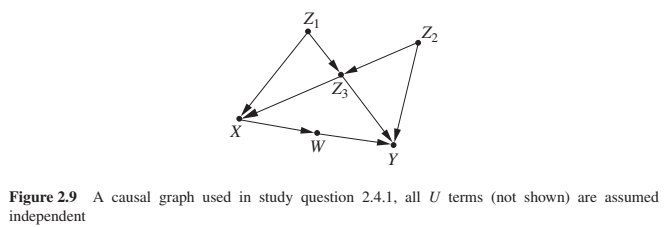

> (a) For each pair of nonadjacent nodes in this graph, find a set of variables that d-separates that pair. What does this list tell us about independencies in the data?

> (b) Repeat question (a) assuming that only variables in the set $\{Z_3, W, X, Z_1 \}$ can be measured.

> (c) For each pair of nonadjacent nodes in the graph, determine whether they are independent conditional on all other variables.

> (d) For every variable $V$ in the graph, find a minimal set of nodes that renders $V$ independent of all other variables in the graph.

> (e) Suppose we wish to estimate the value of $Y$ from measurements taken on all other variables in the model. Find the smallest set of variables that would yield as good an estimate of $Y$ as when we measured all variables.

> (f) Repeat question (e) assuming that we wish to estimate the value of $Z_2$.

> (g) Suppose we wish to predict the value of $Z_2$ from measurements of $Z_3$. Would the quality of our prediction improve if we add measurement of $W$? Explain.

### Answer to 2.4.1, a

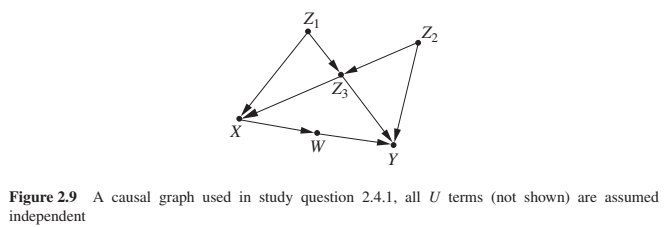

***For each pair of nonadjacent nodes in this graph, find a set of variables that d-separates that pair. What does this list tell us about independencies in the data?***

d-separation means that all paths between two non-adjacent variables are blocked.

* $W \perp Z_1 | X$
* $W \perp Z_2 | X \cup Z_3$
* $W \perp Z_3 | X$
* $X \perp Y | W \cap Z_3 \cap (Z_1 \cup Z_2)$
* $X \perp Z_2 | Z_1 \cap Z_3$
* $Y \perp Z | W \cap Z_3$
* $Y \perp Z_1 | Z_3 \cap (W \cup X)$
* $Z_1 \perp W | X$
* $Z_1 \perp Z_2$
* $Z_2 \perp W | X$
* $Z_2 \perp X | Z_1 \cap Z_3$
* $Z_2 \perp Z_1$
* $Z_3 \perp W | X$

### Answer to 2.4.1, b

***Repeat question (a) assuming that only variables in the set $\{Z_3, W, X, Z_1 \}$ can be measured.***

This is really just taking the subset of answer from (a) that only utilize $\{Z_3, W, X, Z_1 \}$.

* $W \perp Z_1 | X$
* $W \perp Z_2 | X \cup Z_3$
* $W \perp Z_3 | X$
* $Z_1 \perp W | X$
* $Z_3 \perp W | X$

### Answer to 2.4.1, c

***For each pair of nonadjacent nodes in the graph, determine whether they are independent conditional on all other variables.***

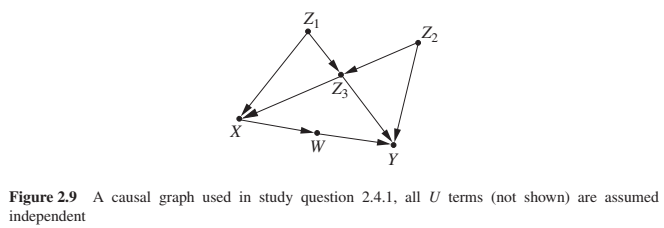

* $W \perp Z_1 | X, Y, Z_2, Z_3$
* $W \not \perp Z_2 | X, Y, Z_1, Z_3$
* $W \not \perp Z_3 | X, Y, Z_1, Z_2$
* $X \perp Y | W, Z_1, Z_2, Z_3$
* $X \perp Z_2 | W, Y, Z_1, Z_3$
* $Y \perp X | W, Z_1, Z_2, Z_3$
* $Y \perp Z_1 | W, X, Z_2, Z_3$
* $Z_1 \perp W | X, Y, Z_2, Z_3$
* $Z_1 \perp Y | W, X, Z_2, Z_3$
* $Z_1 \not \perp Z_2| W, X, Y, Z_3$
* $Z_2 \not \perp W | X, Y, Z_1, Z_3$
* $Z_2 \perp X | W, Y, Z_1, Z_3$
* $Z_2 \perp Z_1 | W, X, Y, Z_3$
* $Z_3 \not \perp W | X, Y, Z_1, Z_2$

### Answer to 2.4.1, d

***For every variable $V$ in the graph, find a minimal set of nodes that renders $V$ independent of all other variables in the graph.***

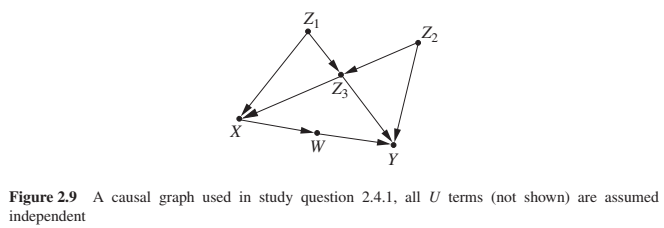

* $W: \{X, Y, Z_2, Z_3 \}$
* $X: \{W, Z_1, Z_3 \}$
* $Y: \{W, Z_2, Z_3 \}$
* $Z_1: \{X, Z_2, Z_3 \}$
* $Z_2: \{W, Y, Z_1, Z_3 \}$
* $Z_3: \{W, X, Y, Z_1, Z_2 \}$

### Answers to 2.4.1, e and f

***Suppose we wish to estimate the value of $Y$ from measurements taken on all other variables in the model. Find the smallest set of variables that would yield as good an estimate of $Y$ as when we measured all variables.***

\

***Repeat question (e) assuming that we wish to estimate the value of $Z_2$.***

\

We've actually already answered these in part (d).  To find the minimum set of variables we need to account for, which will have the same effect as measuring all variables, we need to find the minimum set of variables that renders our target variable independent.  Why?  Because doing so means that variables outside of our minimum set do not add any more information.  So,

* $Y: \{W, Z_2, Z_3 \}$
* $Z_2: \{W, Y, Z_1, Z_3 \}$

### Answer to 2.4.1, g

***Suppose we wish to predict the value of  $Z_2$  from measurements of $Z_3$. Would the quality of our prediction improve if we add measurement of $W$? Explain.***

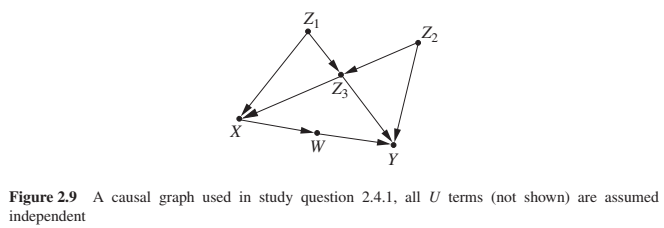

Understanding this answer is a bit tricky.  The answer is "Yes, because after conditioning on $Z_3$, there is an open path from $W \leftarrow X \leftarrow Z_1 \rightarrow Z_3 \leftarrow Z_2$."  So there is information about $Z_2$ contained in $W$ after conditioning on $Z_3$.  But notice that although we may improve our predictions of $Z_2$ by additionally conditioning on $W$, we would be mistaken if we inferred that $W$ *caused* $Z_2$.  PREDICTION AND CAUSAL INFERENCE ARE DIFFERENT ACTIVITIES!

## Question 2.5.1

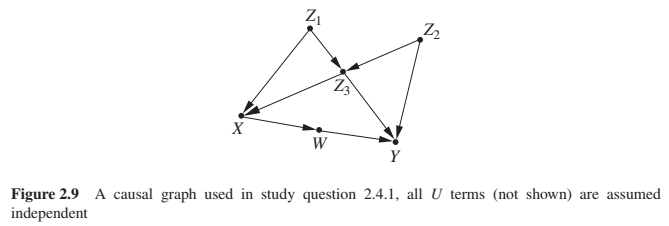

> (a) Which of the arrows in Figure 2.9 can be reversed without being detected by any statistical test? [Hint: Use the criterion for equivalence class.]

> (b) List all graphs that are observationally equivalent to the one in Figure 2.9.

> (c) List the arrows in Figure 2.9 whose directionality can be determined from nonexperimental data.

> (d) Write down a regression equation for $Y$ such that, if a certain coefficient in that equation is nonzero, the model of Figure 2.9 is wrong.

> (e) Repeat question (d) for variable $Z_3$.

> (f) Repeat question (e) assuming the $X$ is not measured.

> (g) How many regression equations of the type described in (d) and (e) are needed to ensure that the model is fully tested, namely, that if it passes all these tests it cannot be refuted additional tests of these kind. [Hint: Ensure that you test every vanishing partial regression coefficient that is implied by the product decomposition (1.29).]

### Answer to 2.5.1, a

Which of the arrows in Figure 2.9 can be reversed without being detected by any statistical test? [Hint: Use the criterion for equivalence class.]

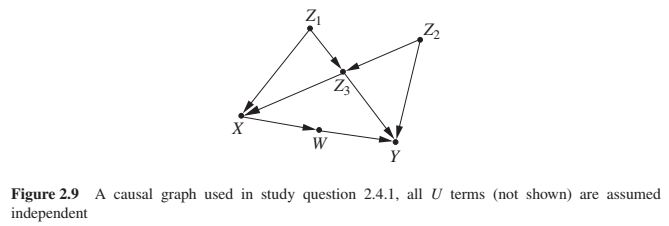

In the chapter, **eqivalance classes** are described as DAGs share the same nodes, *edges* (arrows, regardless of direction; e.g., $X \rightarrow W$ is the same edge as $X \leftarrow W$), and *v-structures* (aka, "colliders"; e.g., $Z_1 \rightarrow Z_3 \leftarrow Z_2$) whose parents are not adjacent.

So to answer our question, we simply need to 1) identify the arrows that are not a part of colliders (with adjacent parents) and 2) identify arrow that, if reversed, would not result in colliders.  Let's check each arrow in turn:

* $X \rightarrow W$ cannot be reversed since this will create new v-structures at $X$.
* $W \rightarrow Y$ cannot be reversed since this will crease a new v-sturcture at $W$.
* $Z_1 \rightarrow X$ cannot be reversed without losing the v-strucutre at $X$.
* $Z_1 \rightarrow Z_3$ cannot be reversed without losing the v-strucutre at $Z_3$.
* $Z_2 \rightarrow Y$ cannot be reversed without losing the v-strucutre at $Y$.
* $Z_2 \rightarrow Z_3$ cannot be reverse without losing the v-strucutre at $Z_3$.
* $Z_3 \rightarrow X$ cannot be reversed without losing the v-structure at $X$ and creating new v-structures at $Z_3$.
* $Z_3 \rightarrow Y$ cannot be reversed without losing the v-structure at $Y$ and creating new v-structures at $Z_3$.

So on examination, there are no arrows that can be reversed while retaining the eqivalance class; the conditional dependecies within this data will (typically) reflect this- and only this DAG.

### Answer to 2.5.1, b

***List all graphs that are observationally equivalent to the one in Figure 2.9.***

Since, as we found in part a, there are no additional DAGs in the equivalence class, there are also no other DAGs that are observationally eqivalent to Figure 2.9.

### Answer to 2.5.1, c

***List the arrows in Figure 2.9 whose directionality can be determined from nonexperimental data.***

Since we there are no alternative DAGs, all arrow directions can be determined from (sufficient) data.

### Answer to 2.5.1, d

***Write down a regression equation for $Y$ such that, if a certain coefficient in that equation is nonzero, the model of Figure 2.9 is wrong.***

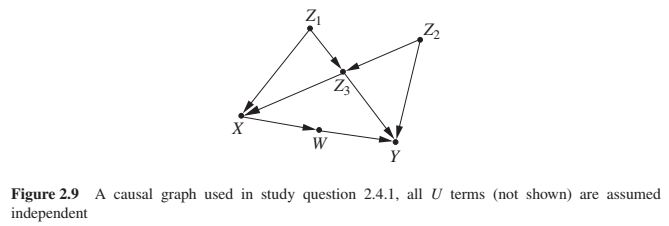

There are (at least) two answers here.  We need to include terms for variables that are d-separated from $Y$ while including all adjacent variables of $Y$; these d-separated variables are $X$ and $Z_1$.

$$Y = \beta_X X + \beta_W W + \beta_{Z_2} Z_2 + \beta_{Z_3} Z_3$$

or

$$Y = \beta_W W + \beta_{Z_1} Z_1 + \beta_{Z_2} Z_2 + \beta_{Z_3} Z_3$$

### Answer to 2.5.1, e

***Repeat question (d) for variable $Z_3$.***

I think the only variable that is conditionally independent of $Z_3$ is $W|X$.  So we have

$$Z_3 = \beta_X X + \beta_W W$$

### Answer to 2.5.1, f

***Repeat question (e) assuming the  $X$  is not measured.***

Since the only conditional independence for $Z_3$ is $W|X$, we cannot construct a regression to test this part of DAG (without measuring $X$).

### Answer to 2.5.1, g

***How many regression equations of the type described in (d) and (e) are needed to ensure that the model is fully tested, namely, that if it passes all these tests it cannot be refuted additional tests of these kind. [Hint: Ensure that you test every vanishing partial regression coefficient that is implied by the product decomposition (1.29).]***

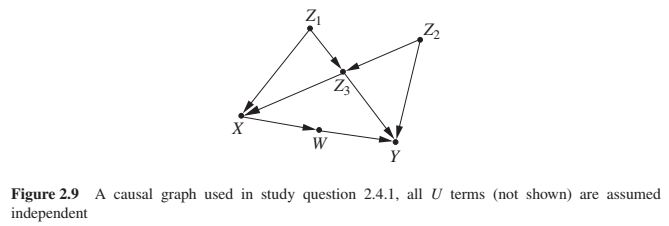

The hint suggests that we should start byu decomposing the joint probability distribution according to the DAG:

$$p(W, X, Y, Z_1, Z_2, Z_3) = p(Z_1) p(Z_2) p(Z_3|Z_1, Z_2) p(X|Z_1, Z_3) p(W|X) p(Y|W, Z_2, Z_3)$$

The idea is to see if conditioning on the parents (if they exist) renders a variable independent of all non-descendents (according to the DAG) and test this with regression.

For starters, neither $Z_1$ nor $Z_2$ have parents and only they are non-descendents of one another.  So we can test with $Z_1 = \beta_{Z_2} Z_2$ or $Z_2 = \beta_{Z_1} Z_1$, where the $\beta$ terms should be zero if the DAG is correct.

Next we have $Z_3$, but $Z_3$'s only non-descendents are its parents $Z_1$ and $Z_2$, so no tests here.

$X$'s only non-parent non-descendent is $Z_2$.  So if we condition on $Z_2$ as well as its parents, $X = \beta_{Z_1} Z_1 + \beta_{Z_2} Z_2 + \beta_{Z_3} Z_3$, then $\beta_{Z_2}$ should be zero.

All but $Y$ are non-descendents of $W$, and $X$ is the only parent.  So all but $\beta_X$ should be zero in $W = \beta_X X + \beta_{Z_1} Z_1 + \beta_{Z_2} Z_2 + \beta_{Z_3} Z_3$.

Finally, $Y$ is a descendent of everything but the only $X$ and $Z_1$ are not parents.  So only $\beta_X$ and $\beta_{Z_1}$ should be zero in $Y = \beta_W W + \beta_X X + \beta_{Z_1} Z_1 + \beta_{Z_2} Z_2 + \beta_{Z_3} Z_3$.

# Chapter 3

## Question 3.2.1

Referring to Study question 1.5.2 (Figure 1.10) and the parameters listed therein,

> (a) Compute $P(y|do(x))$ for all values of $x$ and $y$, by simulating the intervention $do(x)$ on the model.

> (b) Compute $P(y|do(x))$ for all values of $x$ and $y$, using the adjustment formula (3.5)

> (c) Compute the ACE

$$ACE = P(y_1|do(x_1)) − P(y_1|do(x_0))$$

> and compare it to the Risk Difference

$$RD = P(y_1|x_1) − P(y_1|x_0)$$

> What is the difference between ACE and the RD? What values of the parameters would minimize the difference?

> (d) Find a combination of parameters that exhibit Simpson’s reversal (as in Study question 1.5.2(c)) and show explicitly that the overall causal effect of the drug is obtained from the desegregated data.

\

I'm going to reproduce part of the question and the image from question 1.5.2:

> Assume that a population of patients contains a fraction $r$ of individuals who suffer from a certain fatal syndrome $Z$, which simultaneously makes it uncomfortable for them to take a life-prolonging drug $X$ (Figure 1.10). Let $Z = z_1$ and $Z = z_0$ represent, respectively, the presence and absence of the syndrome, $Y = y_1$ and $Y = y_0$ represent death and survival, respectively, and $X = x_1$ and $X = x_0$ represent taking and not taking the drug. Assume that patients not carrying the syndrome, $Z = z_0$, die with probability $p_2$ if they take the drug and with probability $p_1$ if they don’t. Patients carrying the syndrome, $Z = z_1$, on the other hand, die with probability $p_3$ if they do not take the drug and with probability $p_4$ if they do take the drug. Further, patients having the syndrome are more likely to avoid the drug, with probabilities $q_1 = P(x_1|z_0)$ and $q_2 = p(x_1|z_1)$.

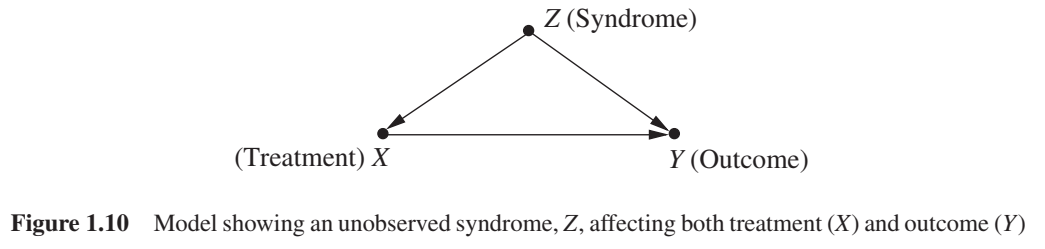

### Answer to 3.2.1, a

***Compute $P(y|do(x))$ for all values of $x$ and $y$, by simulating the intervention $do(x)$ on the model.***

Recall that the $do()$ operator is a way to simulate a randomized intervention on a system.  The term "randomized" implies that we cut any incidental causes of the intervention (the *parents* of $X$).  In our DAG, this means cutting the link $Z \rightarrow X$ to simulate a randomized intervention.

The way we do this is to *marginalize* over the incidental causes we're trying to eliminate.  Hence,

$$\sum_Z{p(Y=y | X=x, Z=z) \times p(Z=z)}$$

We can get there another way: by conditioning on the *propensity* for receiving treatment (the "propensity score").  Recall that the conditional probability $p(A|B) = \frac{p(A,B)}{p(B)}$.  Hence,

$$\begin{aligned}
p(y|do(x)) &= \sum_Z{\frac{p(X=x, Y=y, Z=z)}{p(X=x | Z=z)}} \\
\
&= \sum_Z{\frac{p(Y=y|X=x, Z=z) \times p(X=x | Z=z) \times p(Z=z)}{p(X=x | Z=z)}} \\
&= \sum_Z{p(Y=y | X=x, Z=z) \times p(Z=z)} \\
\end{aligned}$$



Now we need to find all 4 combinations of $x$ and $y$ for this expression.

* $p(y_1|do(x_1)) = p(y_1|x_1, z_0) p(z_0) + p(y_1|x_1, z_1) p(z_1) = r p_4 + (1-r)p_2$
* $p(y_0|do(x_1)) = 1 - p(y_1|do(x_1)) = 1 - p(y_0|x_1, z_0) p(z_0) + p(y_0|x_1, z_1) p(z_1) = 1 - (r p_4 + (1-r)p_2)$
> > $= p(y_0|x_1, z_0) p(z_0) + p(y_0|x_1, z_1) p(z_1) = 1 - (r p_4 + (1-r)p_2)$
* $p(y_1|do(x_0)) = p(y_1|x_0, z_0) p(z_0) + p(y_1|x_0, z_1) p(z_1) = r p_3 + (1-r)p_1$
* $p(y_0|do(x_0)) = 1 - p(y_1|do(x_0)) = 1 -  p(y_1|x_0, z_0) p(z_0) + p(y_1|x_0, z_1) p(z_1) = 1 - (r p_3 + (1-r)p_1$
> > $= p(y_0|x_0, z_0) p(z_0) + p(y_0|x_0, z_1) p(z_1) = 1 - (r p_3 + (1-r)p_1$

### Answer to 3.2.1, b

***Compute $P(y|do(x))$ for all values of $x$ and $y$, using the adjustment formula (3.5)***

We looked at Formula 3.5 in part a above:

$$p(Y=y|do(X=x)) = \sum_Z p(Y=y|X=x, Z=z) p(Z=z)$$

As far as I can tell, this is the same question as part a.  So the same answers hold.

### Answer to 3.2.1, c

***Compute the ACE***

***$$ACE = P(y_1|do(x_1)) − P(y_1|do(x_0))$$***

***and compare it to the Risk Difference***

***$$RD = P(y_1|x_1) − P(y_1|x_0)$$***

***What is the difference between ACE and the RD? What values of the parameters would minimize the difference?***

> $\begin{aligned}
ACE &= P(y_1|do(x_1)) − P(y_1|do(x_0)) \\
&= \left(p(y_1|x_1, z_0) p(z_0) + p(y_1|x_1, z_1) p(z_1) \right) - \left(p(y_1|x_0, z_0) p(z_0) + p(y_1|x_0, z_1) p(z_1) \right) \\
&= (r p_4 + (1-r)p_2) - (r p_3 + (1-r)p_1) \\
\end{aligned}$

\

> $\begin{aligned}
RD &= p(y_1 | x_1) - p(y_1 | x_0) \\
&= \frac{r p_4 q_2 + (1-r)p_2 q_1}{r q_2 + (1-r)q_1} - \frac{r p_3(1-q_2) + (1-r)p_1(1-q_1)}{r(1-q_2) + (1-r)(1-q_1)}
\end{aligned}$

We obviously get different expressions for ACE vs RD.  What's important is that these different expression encode the qualitative difference between ACE vs RD: whereas RD measures the *change* in $Y$ *observed* with a change in $X$, ACE is the *effect* on $Y$ due to a change in $X$.

### Answer to 3.2.1, d

***Find a combination of parameters that exhibit Simpson’s reversal (as in Study question 1.5.2(c)) and show explicitly that the overall causal effect of the drug is obtained from the desegregated data.***

Remember that *Simpson's reversal* is a situation in which the inclusion or exclusion of a given variable reverses the sign (+\-) of an estimate.  

An example of this would be if $p(y_1|x_1, z_1) - p(y_1|x_0, z_1) > 0$, but $p(y_1|x_1) - p(y_1|x_0) < 0$.  Whether a reversal would occur depends on the exact values of these terms.

I'm a little unclear about the relevance of this question here since

$$p(y_1|do(x_1), z) - p(y_1|do(x_0), z) = p(y_1|do(x_1)) - p(y_1|do(x_0))$$

## Question 3.3.1

Consider the graph in Figure 3.8

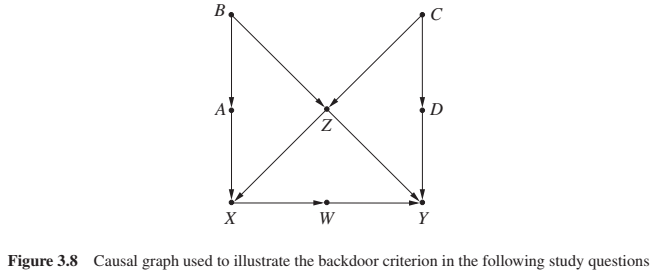

> (a) List all of the sets of variables that satisfy the backdoor criterion to determine the causal effect of $X$ on $Y$.

> (b) List all of the minimal sets of variables that satisfy the backdoor criterion to determine the causal effect of $X$ on $Y$ (i.e., any set of variables such that, if you removed any one of the variables from the set, it would no longer meet the criterion).

> (c) List all minimal sets of variables that need be measured in order to identify the effect of $D$ on $Y$. Repeat, for the effect of $\{W, D\}$ on $Y$.

### Answer to 3.3.1, a

***List all of the sets of variables that satisfy the backdoor criterion to determine the causal effect of $X$ on $Y$.***

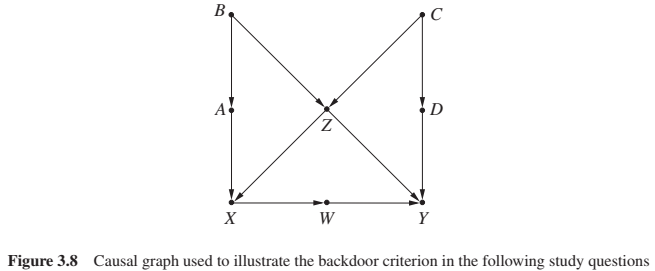

So we need to find sets of variables that block all open non-causal paths between $X$ and $Y$ *without* opening otherwise-closed paths.

One non-negotiable node that we must condition on is $Z$, so $Z$ is a part of every set.  This blocks open paths $X \leftarrow Z \rightarrow Y$ and $X \leftarrow A \leftarrow B \rightarrow Z \rightarrow Y$.  But notice that it also opens a collider $X \leftarrow A \leftarrow B \rightarrow Z \leftarrow C \rightarrow D \rightarrow Y$, so in addition to $Z$, we additionally need to condition on $A \cup B \cup C \cup D$.

We could delineate every combination implied here ($Z \cap (A \cup B \cup C \cup D)$), but I'm too lazy.

### Answer to 3.3.1, b

***List all of the minimal sets of variables that satisfy the backdoor criterion to determine the causal effect of $X$ on $Y$  (i.e., any set of variables such that, if you removed any one of the variables from the set, it would no longer meet the criterion).***

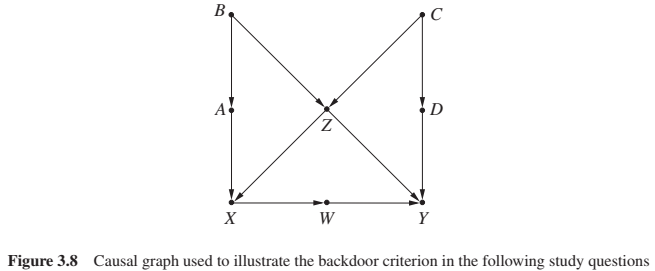

This is just the sets above with $Z$ and any other single node from $\{A, B, C, D\}$

### Answer to 3.3.1, c

***List all minimal sets of variables that need be measured in order to identify the effect of $D$ on $Y$. Repeat, for the effect of $\{W, D\}$ on $Y$.***

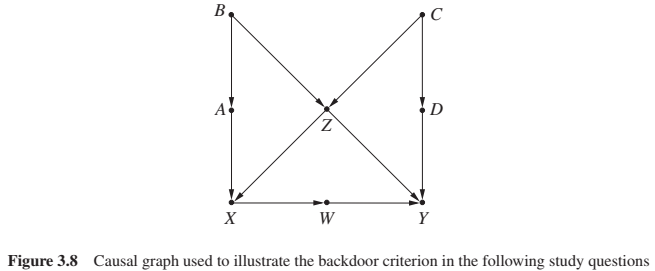

For $D \rightarrow Y$, in order to block all backdoor paths with the minimal set of other variables, the most obvious minimal set is $\{C\}$.  If we do not condition of $C$, then we must condition on $Z$; but conditioning on $Z$ alone is not sufficient because it opens the collider $W \leftarrow X \leftarrow A \leftarrow B \rightarrow Z \leftarrow C \rightarrow D \rightarrow Y$. So if we condition on $Z$, we need to additionally condition on one of the other non-$Z$ variables in this chain; the one we choose must precede $Z$ ($W, X, A, B$) since conditioning on $C$ is already a minimal set (i.e., conditioning on $\{C, Z\}$ is not minimal).

If, in addition to $D \rightarrow Y$ we also want to estimate $W \rightarrow Y$, we must condition on $Z \cap (A \cup B \cup X)$.

## Question 3.3.2 (Lord's paradox)

At the beginning of the year, a boarding school offers its students a choice between two meal plans for the year: Plan A and Plan B. The students’ weights are recorded at the beginning and the end of the year. To determine how each plan affects students’ weight gain, the school hired two statisticians who, oddly, reached different conclusions.

* The first statistician calculated the difference between each student’s weight in June ($W_F$) and in September ($W_I$) and found that the average weight gain in each plan was zero.
* The second statistician divided the students into several subgroups, one for each initial weight, $W_I$. He finds that for each initial weight, the final weight for Plan B is higher than the final weight for Plan A.

So, the first statistician concluded that there was no effect of diet on weight gain and the second concluded there was.

Figure 3.9 illustrates data sets that can cause the two statisticians to reach conflicting conclusions.

* Statistician-1 examined the weight gain $W_F − W_I$, which, for each student, is represented by the shortest distance to the 45° line. Indeed, the average gain for each diet plan is zero; the two groups are each situated symmetrically relative to the zero-gain line, $W_F = W_I$.
* Statistician-2, on the other hand, compared the final weights of plan A students to those of plan B students who entered school with the same initial weight $W_0$ and, as the vertical line in the figure indicates, plan B students are situated above plan A students along this vertical line. The same will be the case for any other vertical line, regardless of $W_0$.

> (a) Draw a causal graph representing the situation.

> (b) Determine which statistician is correct.

> (c) How is this example related to Simpson’s paradox?

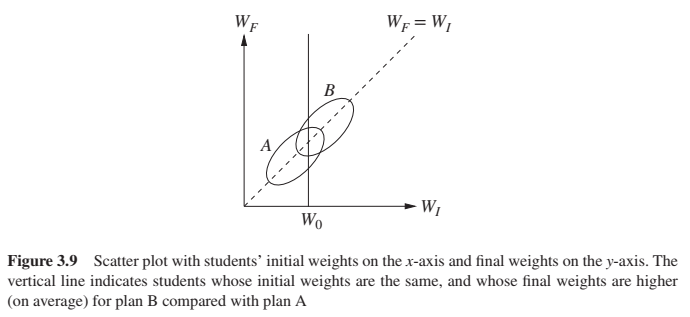

### Answer to 3.3.2, a

***Draw a causal graph representing the situation.***

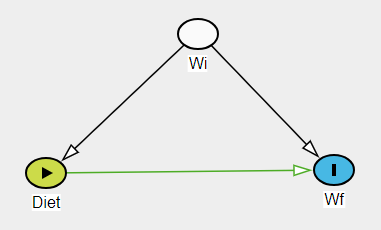

### Answer to 3.3.2, b

***Determine which statistician is correct.***

This is an interesting problem.  When I read the question, my gut reaction is to believe that Statistician 1 is correct, since he is actually using measurements of individuals' weight gains.  But this is wrong for a reason that would be easy to overlook.

Notice that Statistician 1 is conditioning on $\text{Gain}$.  Enter that into the DAG and you'll see the problem.

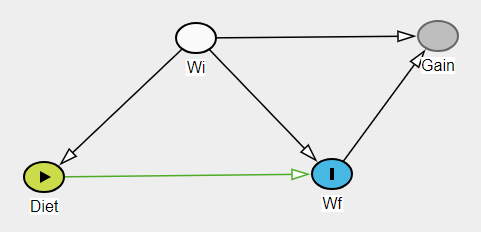

$\text{Gain}$ acts as a collider; by conditioning on $\text{Gain}$, we open a spurious path between $W_i \rightarrow \text{Gain} \leftarrow W_f$.

Statistician 2, on the otherhand, does not introduce a collider and instead correctly closes the backdoor path between $\text{Diet} \leftarrow W_i \rightarrow W_f$ by conditioning on $W_i$.  Thus, Statistician 2 is correct.

### Answer to 3.3.2, c

***How is this example related to Simpson’s paradox?***

Once again, recall that Simpson's paradox is when the estimated relationship between two variables reverses when conditioning on a third variable.

This is a clear case of Simpson's paradox: **before** conditioning on $\text{Gain}$, we estimate that the diets lead to differences in body-weight changes; **after** conditioning of $\text{Gain}$, we estimate that the diets are not different.

## Question 3.3.3

Revisit the lollipop story of Study question 1.2.4

> *In an attempt to estimate the effectiveness of a new drug, a randomized experiment is conducted. In all, 50% of the patients are assigned to receive the new drug and 50% to receive a placebo. A day before the actual experiment, a nurse hands out lollipops to some patients who show signs of depression, mostly among those who have been assigned to treatment the next day (i.e., the nurse’s round happened to take her through the treatment-bound ward). Strangely, the experimental data revealed a Simpson’s reversal: Although the drug proved beneficial to the population as a whole, drug takers were less likely to recover than nontakers, among both lollipop receivers and lollipop nonreceivers.*

and answer the following questions:

> (a) Draw a graph that captures the story.

> (b) Determine which variables must be adjusted for by applying the backdoor criterion.

> (c) Write the adjustment formula for the effect of the drug on recovery.

> (d) Repeat questions (a)–(c) assuming that the nurse gave lollipops a day after the study, still preferring patients who received treatment over those who received placebo.

### Answer to 3.3.3, a

***Draw a graph that captures the story.***

I'm copy-pasting the DAG I made for question 1.2.4.

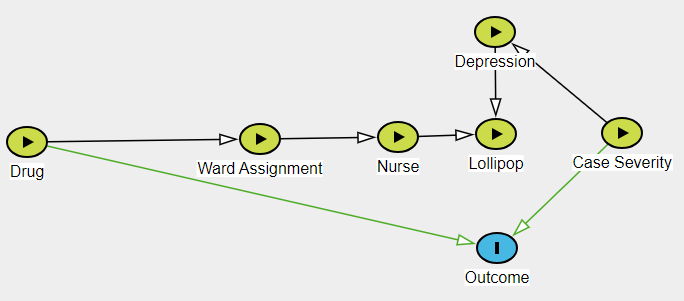

### Answer to 3.3.3, b

***Determine which variables must be adjusted for by applying the backdoor criterion.***

It's left implied, but I'm sure we're meant to adjust in order to get an estimate for the effect of $\text{Drug}$ on $\text{Outcome}$.

By my DAG, we do not need to adjust for anything.  In fact, doing threatens to confound our estimate by opening the collider at $\text{Lollipop}$.

### Answer to 3.3.3, c

***Write the adjustment formula for the effect of the drug on recovery.***

The basic adjustment formula is:

$$p(y | \text{do}(x)) = \sum_Z{p(Y=y | X=x, Z=z) \times p(Z=z)}$$

But as we answered in part c, we don't adjust here.  So,

$$p(y | \text{do}(x)) = \sum_Z{p(Y=y | X=x, Z=z) \times p(Z=z)} = p(y|x)$$

### Answer to 3.3.3, d

***Repeat questions (a)–(c) assuming that the nurse gave lollipops a day after the study, still preferring patients who received treatment over those who received placebo.***

Nothing changes.  Giving lollipops *after* the study cannot have any impact on the study.

## Question 3.4.1

Assume that in Figure 3.8

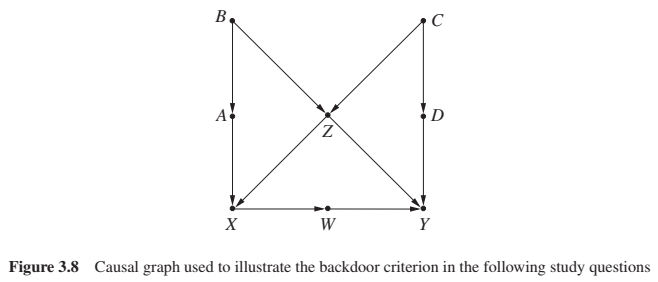

only $X$, $Y$, and one additional variable can be measured.  Which variable would allow the identification of the effect of $X$ on $Y$?  What would that effect be?

### Answer to 3.4.1

The effect of $X$ on $Y$ runs through the *front door* via $W$; without accounting for $W$, we won't get an unbiased estimate of $X \rightarrow Y$.

Notice that $W$ meets the "front-door criteria":
* $W$ intercepts all all direct paths from $X$ to $Y$.
* There are no unblocked paths from $X$ to $W$.
* All backdoor paths from $W$ to $Y$ are blocked by $X$.

So we can apply the "front-door adjustment", which will control for $W$.  Let's build up to the final expression.

First, we need to estimate the effect of $X$ on $W$ with the backdoor adjustment:

$$p(w|\text{do}(x)) = \sum_{\text{backdoors}} p(w|x, \text{ backdoors}) \times p(\text{backdoors}) = p(w|x)$$

where $\text{backdoors}$ drops out because they're all blocked already.  

Now, for each value of $W$, we need estimate the causal effect of $W$ on $Y$ by again using the backdoor adjustment.  For a single value of $W$, this is:

$$p(y|\text{do}(w)) = \sum_x p(y|w, x) \times p(x)$$

So we have $\text{do}$ expression for both legs in our problem.  Now we just need to tie them together.  There's going to be one addition, though: since $X=x$ may probabilistically cause several different values of $W=w$, we need to sum over all $w$.

$$p(y|\text{do}(x)) = \sum_w p(w|x) \sum_{x'} p(y|x', w) p(x')$$

The $'$ marking some of the $x$'s is just for notational clarity, separaing the second $\text{do}$ expression from the first and insuring we only sum $x$ over the second.

## Question 3.4.2

I went to a pharmacy to buy a certain drug, and I found that it was available in two different bottles: one priced at $\$1$, the other at $\$10$. I asked the druggist, “What’s the difference?” and he told me, “The $\$10$ bottle is fresh, whereas the $\$1$ bottle one has been on the shelf for 3 years. But, you know, data shows that the percentage of recovery is much higher among those who bought the cheap stuff. Amazing isn’t it?” I asked if the aged drug was ever tested. He said, “Yes, and this is even more amazing; 95% of the aged drug and only 5% of the fresh drug has lost the active ingredient, yet the percentage of recovery among those who got bad bottles, with none of the active ingredient, is still much higher than among those who got good bottles, with the active ingredient.”

Before ordering a cheap bottle, it occurred to me to have a good look at the data. The data were, for each previous customer, the type of bottle purchased ($\text{aged}$ or $\text{fresh}$), the concentration of the active ingredient in the bottle ($\text{high}$ or $\text{low}$), and whether the customer recovered from the illness ($\text{recovered}$ or $\text{unrecovered}$). The data perfectly confirmed the druggist’s story. However, after making some additional calculations, I decided to buy the expensive bottle after all; even without testing its content, I could determine that a fresh bottle would offer the average patient a greater chance of recovery.

Based on two very reasonable assumptions, the data show clearly that the fresh drug is more effective. The assumptions are as follows:

> (i) Customers had no information about the chemical content ($\text{high}$ or $\text{low}$) of the specific bottle of the drug that they were buying; their choices were influenced by $\text{price}$ and $\text{shelf-age}$ alone.

> (ii) The effect of the drug on any given individual depends only on its chemical content, not on its shelf age ($\text{aged}$ or $\text{fresh}$).


(a) Determine the relevant variables for the problem, and describe this scenario in a causal graph.

(b) Construct a data set compatible with the story and the decision to buy the expensive bottle.

(c) Determine the effect of choosing the $\text{fresh}$ versus the $\text{aged}$ drug by using assumptions (i) and (ii), and the data given in (b).

### Answers to 3.4.2

I've looked at this question quite a bit.  My conclusion is that it somehow escaped editing.  As a result, my answers don't really conform with the topics discussed in this section of the book (i.e., front-door adjustments, do-operators, etc.).  

### Answer to 3.4.2, a

***Determine the relevant variables for the problem, and describe this scenario in a causal graph***

This is actually a bit difficult because, although the question asserts that customers had no information about $\text{concentration}$, but it's hard to ignore that most people would probably guess that the relationship between $\text{price}$ and $\text{shelf-age}$ reflected some difference in $\text{concentration}$.  It is almost impossible not to add an edge from $\text{concentration}$ to $\text{Selected}$

This may be a quirky limitation to DAGs in general: I conjecture that *if a node within a DAG is capable of understanding the DAG's structure, assume edges from that all descendents of that nodes parents to the conscious node*.

But we'll continue as though my conjecture is false, as per the question.

Here's my DAG:

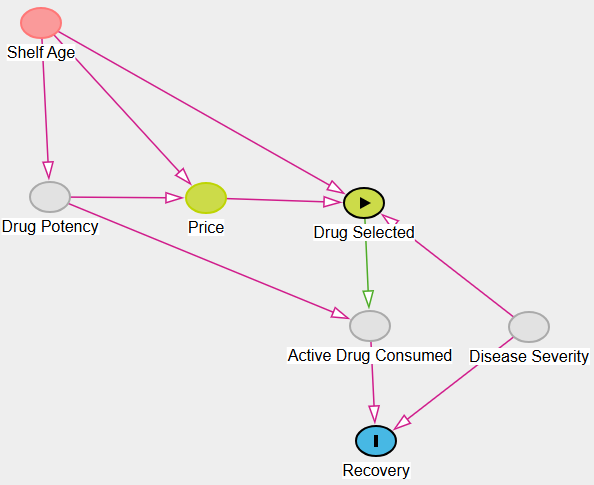

Notice that I'm hypothesizing an additional unobserved variable, $\text{Disease Severity}$.  I'm guessing that $\text{Disease Severity}$ will influence which drug is selected.  But this flouts assumption (i), which says that customers only made their decision based on $\text{Shelf Age}$ and $\text{Price}$, because they will obviously know how poorly they feel.  So let's move forward keeping this in mind.

### Answer to 3.4.2, b

***Construct a data set compatible with the story and the decision to buy the expensive bottle.***

I suspect that $\text{Disease Severity}$ is actually meant to be part of the answer here (even though it disobeys assumption (i)) because this section is about the **front-door adjustment**, and including $\text{Disease Severity}$ establishes a situation in which we can deploy the front-door adjustment.  I mention that because it means we can simply repurpose a dataset (Table 3.2) from earlier in the chapter.

|       |\$1, Aged|    |\$10, Fresh|    |All   |    |
|-------|---------|----|-----------|----|------|----|
|       |400      |    |400        |    |800   |    |
|       |NoDrug   |Drug|NoDrug     |Drug|NoDrug|Drug|
|Recov  |323      |18  |1          |38  |324   |56  |
|NoRecov|57       |2   |19         |324 |76    |344 |
|       |380      |20  |20         |380 |400   |400 |


### Answer to 3.4.2, c

***Determine the effect of choosing the $\text{fresh}$ versus the $\text{aged}$ drug by using assumptions (i) and (ii), and the data given in (b).***

So we want to find

$$\text{ACE} = p(\text{recover}|do(\text{fresh})) - p(\text{recover}|do(\text{aged}))$$

If we take assumption (i) seriously, and assume that $\text{Disease Severity}$ is not playing a role here, then

$$\begin{aligned}
\text{ACE} &= p(\text{recover}|do(\text{fresh}) - p(\text{recover}|do(\text{aged}) \\
&= p(\text{recover}|\text{fresh}) - p(\text{recover}|\text{aged}) \\
&= \frac{1+38}{20+380} - \frac{323+18}{380+20} \\
&= \frac{39}{400} - \frac{341}{400} \\
&= -\frac{302}{400} = -75.5\%
\end{aligned}$$

This is simple; there are no backdoors to account for or anything.  But again, we shouldn't expect that consuming the active drug decreases probability of recovery.  So let's see what happens if we assume that $\text{Disease Severity}$ *does* play a role here.  Now we use the front-door adjustment.

$$\begin{aligned}
\text{ACE} &= p(\text{recover}|do(\text{fresh})) - p(\text{recover}|do(\text{aged})) \\
&= p(y_1 | do(x_1)) - p(y_1 | do(x_0)) \\
\end{aligned}$$

So let $y_1$ and $y_0$ represent *recovered* and *non-recovered*, respectively; let $x_1$ and $x_0$ represent *expensive/fresh drug selected* and *cheap/aged drug selected*, respectively; and let $z_1$ and $z_0$ represent *active drug consumed* and *inactive drug consumed* respectively.

$\begin{aligned}
p(y_1 | do(x_1)) &= \sum_Z p(z|x_1) \sum_{X'} p(y_1 | x', z) p(x') \\
&= p(z_1 | x_1) \left(p(y_1 | x_1, z_1) p(x_1) + p(y_1 | x_0, z_1) p(x_0) \right) + p(z_0 | x_1) \left(p(y_1 | x_1, z_0) p(x_1) + p(y_1 | x_0, z_0) p(x_0) \right) \\
&= 0.95(0.1 \times 0.5 + 0.9 \times 0.5) + 0.05(0.05 \times 0.5 + 0.85 \times 0.5) \\
&= 0.4975
\end{aligned}$

$\begin{aligned}
p(y_1 | do(x_0)) &= \sum_Z p(z|x_0) \sum_{X'} p(y_1 | x', z) p(x') \\
&= p(z_1 | x_0) \left(p(y_1 | x_1, z_1) p(x_1) + p(y_1 | x_0, z_0) p(x_0) \right) \\
&= 0.05(0.1 \times 0.5 + 0.9 \times 0.5) + 0.95(0.05 \times 0.5 + 0.85 \times 0.5) \\
&= 0.4525
\end{aligned}$

Plugging these into our expression for $\text{ACE}$

$$\text{ACE} = 0.4975 - 0.4525 = 0.045 > 0$$

Hence, the fresh/expensive drug is efficacious than the aged/cheap drug.

## Question 3.5.1

Consider the causal model of Figure 3.8.

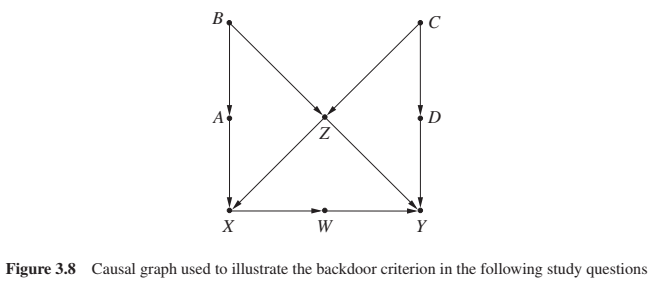

> (a) Find an expression for the $c$-specific effect of $X$ on $Y$.

> (b) Identify a set of four variables that need to be measured in order to estimate the $z$-specific effect of $X$ on $Y$, and find an expression for the size of that effect.

> (c) Using your answer to part (b), determine the expected value of $Y$ under a $Z$-dependent strategy, where $X$ is set to $0$ when $Z$ is smaller or equal to $2$ and $X$ is set to $1$ when $Z$ is larger than $2$. (Assume $Z$ takes on integer values from $1$ to $5$.)

### Answer to 3.5.1, a

***Find an expression for the  c -specific effect of  X  on  Y .***

In the vocabulary of this section, we looking for

$$p(Y=y|\text{do}(X=g(C)))$$

In other words, the effect of $X$ on $Y$ may be some function $g()$ of $C$.  So we want to set $C=c$ and ensure that all backdoor paths from $X$ to $Y$, as per the backdoor rule, remain closed.  This is encapsulated in *Rule 2* (p.70):

> The c-specific effect $p(Y=y|\text{do}(X=g(C)))$ is identified whenever we can measure a set $S$ of variables such that $S \cup C$, where $C \not \in S$, satisfies the backdoor criterion.  Moreover, the c-specific effect is given by

$$\begin{aligned}
p(Y=y|\text{do}(X=g(C))) &= p(Y=y|\text{do}(X=g(C)), C=c) \\
&= \sum_S p(Y=y | X=x, S=s, C=c) \times p(S=s | C=c)
\end{aligned}$$

Applying this to our problem, we block all backdoor paths by conditioning on $Z$ (so here, $S=Z$).

$$p(Y=y|\text{do}(X=g(C))) = \sum_{Z} p(Y=y | X=x, Z=z, C=c) \times p(Z=z | C=c)$$

### Answer to 3.5.1, b

***Identify a set of four variables that need to be measured in order to estimate the $z$-specific effect of $X$ on $Y$, and find an expression for the size of that effect.***

Now, instead of a $c$-specific effect, we're looking for a $z$-specific effect.  We need to follow the same logic as we did for part a.  We start by making explicit what we're looking for:

$$p(Y=y | \text{do}(X = g(Z)))$$

Now reiterating *Rule 2*, but now in terms of $Z$

> The $z$-specific effect $p(Y=y|\text{do}(X=g(Z)))$ is identified whenever we can measure a set $S$ of variables such that $S \cup Z$, where $Z \not \in S$, satisfies the backdoor criterion.  Moreover, the $z$-specific effect is given by

$$\begin{aligned}
p(Y=y|\text{do}(X=g(Z))) &= p(Y=y|\text{do}(X=g(Z)), Z=z) \\
&= \sum_S p(Y=y | X=x, S=s, Z=z) \times p(S=s | Z=z)
\end{aligned}$$

When we apply this to our problem, we see that the only open backdoor path from $Z$ to $Y$ is $Z \leftarrow C \rightarrow D \rightarrow Y$.  So we can set $S = {C \cup D}$.

$$\begin{aligned}
p(Y=y|\text{do}(X=g(Z))) &= \sum_{C} p(Y=y | X=x, Z=z, C=c) \times p(C=c | Z=z) \\
&= \sum_{D} p(Y=y | X=x, Z=z, D=d) \times p(D=d | Z=z) \\
\end{aligned}$$



### Answer to 3.5.1, c

***Using your answer to part (b), determine the expected value of $Y$ under a $Z$-dependent strategy, where $X$ is set to $0$ when $Z$ is smaller or equal to $2$ and $X$ is set to $1$ when $Z$ is larger than $2$. (Assume $Z$ takes on integer values from $1$ to $5$.)***

$$\begin{aligned}
𝔼[Y=y|\text{do}(X=g(Z))] &= \sum_{Z=1}^2 p(Y=y | \text{do}(X=0), Z=z) \times p(Z=z) + \sum_{Z=3}^5 p(Y=y | \text{do}(X=1), Z=z) \times p(Z=z)\\
\end{aligned}$$

## Question 3.8.1

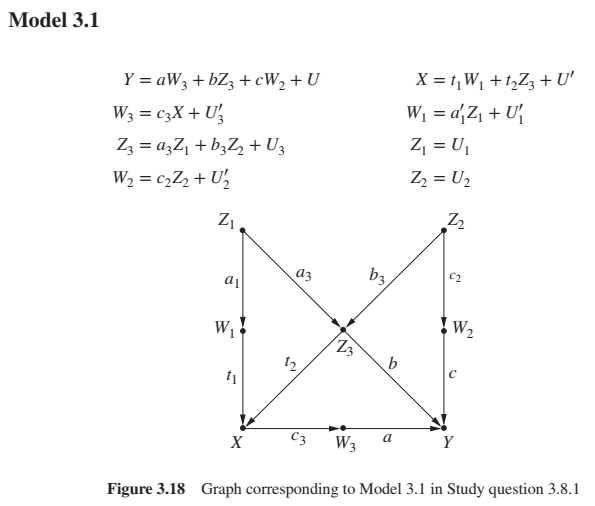

Given the model depicted above, answer the following questions:
(All answers should be given in terms of regression coefficients in specified regression equations.)

> (a) Identify three testable implications of this model.

> (b) Identify a testable implication assuming that only $X$, $Y$, $W_3$, and $Z_3$ are observed.

> (c) For each of the parameters in the model, write a regression equation in which one of the coefficients is equal to that parameter. Identify the parameters for which more than one such equation exists.

> (d) Suppose $X$, $Y$, and $W_3$ are the only variables observed. Which parameters can be identified from the data? Can the total effect of $X$ on $Y$ be estimated?

> (e) If we regress $Z_1$ on all other variables in the model, which regression coefficient will be zero?

> (f) The model in Figure 3.18 implies that certain regression coefficients will remain invariant when an additional variable is added as a regressor. Identify five such coefficients with their added regressors.

> (g) Assume that variables $Z_2$ and $W_2$ cannot be measured. Find a way to estimate $b$ using regression coefficients. [Hint: Find a way to turn $Z_1$ into an instrumental variable for $b$.]

### Answer to 3.8.1, a

***Identify three testable implications of this model.***

Testable implications are extracted from the "conditional independencies" of the DAG.  In our DAG, there are many conditional independencies--way more than 3.

* $W_1 \perp W_3 | X$
* $Z_1 \perp W_3 | X$
* $Z_1 \perp X | W_1, Z_3$
* $Z_1 \not \perp Z_2 | Z_3$

How could we test these?  With linear regression, using the "regression rule" (p. 83):

* $W_1 = \beta_{W_3}^0 W_3 + \beta_X X$
* $Z_1 = \beta_{W_3}^0 W_3 + \beta_X X$
* $Z_1 = \beta_X^0 X + \beta_{W_1} W_1 + \beta_{Z_3} Z_3$
* $Z_1 = \beta_{Z_2}^0 Z_2; Z_1 = \beta_{Z_2} Z_2 + \beta_{Z_3} Z_3$

In each case, the $\beta^0$ term should approximate 0 if the model is accurate.  Notice in the last one that the $\beta_{Z_2}^0$ is replaced with $\beta_{Z_2}$ after additionally conditioning on $Z_3$.


### Answer to 3.8.1, b

***Identify a testable implication assuming that only $X$, $Y$, $W_3$, and $Z_3$ are observed.***

* $W_3 \perp Z_3 | X$ such that $W_3 = \beta_{Z_3}^0 Z_3 + \beta_X X$
* $W_3 \not \perp Z_3 | X, Y$ such that $W_3 = \beta_{Z_3} Z_3 + \beta_X X + \beta_Y Y$ since conditioning on $Y$ opens the collider $Z_3 \rightarrow Y \leftarrow W_3$.

### Answer to 3.8.1, c

***For each of the parameters in the model, write a regression equation in which one of the coefficients is equal to that parameter. Identify the parameters for which more than one such equation exists.***

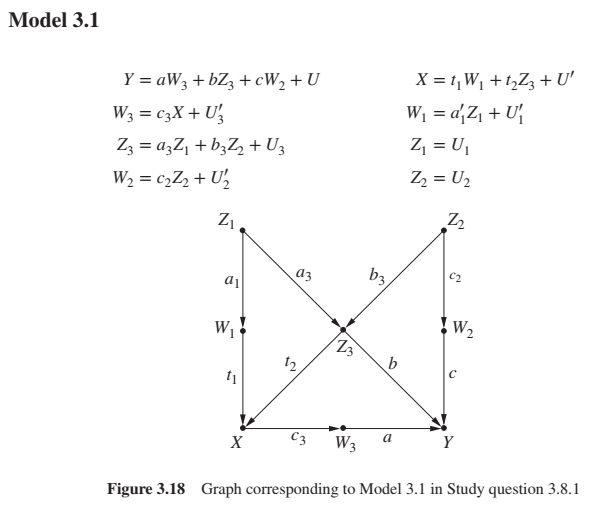

* $a, b, c:$
  * $Y = \beta_{W_3} W_3 + \beta_{Z_3} Z_3 + \beta_{W_2} W_2$
    * $a = \beta_{W_3}$
    * $b = \beta_{Z_3}$
    * $c = \beta_{W_2}$

* $a_1:$
  * $ W_1 = \beta_{Z_1} Z_1$
    * $a_1 = \beta_{Z_1}$

* $a_3, b_3:$
  * $Z_3 = \beta_{Z_1} Z_1 + \beta_{Z_2} Z_2$
    * $a_3 = \beta_{Z_1}$
    * $b_3 = \beta_{Z_2}$

* $c_2:$
  * $W_2 = \beta_{Z_2} Z_2$
    * $c_2 = \beta_{Z_2}$

* $c_3:$
  * $W_3 = \beta_{X} X$
    * $c_2 = \beta_{X}$

* $t_1, t_2:$
  * $X = \beta_{W_1} W_1 + \beta_{Z_3} Z_3$
    * $t_1 = \beta_{W_1}$
    * $t_2 = \beta_{Z_3}$

As for parameters with >1 equation, there are several trivial examples, where we additionally condition on something inconsequential like:

* $a_1:$
  * $W_1 = \beta_{Z_1} Z_1 + \beta_{W_2} W_2$
    * $a_1 = \beta_{Z_1}$

But those cases aren't very interesting.  Instead, imagine we want to estimate $t_1$ but can't measure $Z_3$.  In this case, we could get an estimate by:

* $t_1:$
  * $X = \beta_{W_1} W_1 + \beta_{Z_2} Z_2$
     * $t_1 = \beta_{W_1}$

But notice that we are no longer getting an estimate for $t_2$.

### Answer to 3.8.1, d

***Suppose $X$, $Y$, and $W_3$ are the only variables observed. Which parameters can be identified from the data? Can the total effect of $X$ on $Y$ be estimated?***

We'll answer this by applying the "regression rule (p. 84).
 But let's additionally verify our answers with some simulation.  I'll build the model below.

In [ ]:
n <- 100000

Z1 <- rnorm(n)
  a1 <- 2
  a3 <- 3
Z2 <- rnorm(n)
  b3 <- 2
  c2 <- 3
W1 <- Z1*a1 + rnorm(n)
  t1 <- 2
Z3 <- Z1*a3 + Z2*b3 + rnorm(n)
  t2 <- 2
  b <- 3
W2 <- Z2*c2 + rnorm(n)
  c <- 4
X <- W1*t1 + Z3*t2 + rnorm(n)
  c3 <- 2
W3 <- X*c3 + rnorm(n)
  a <- 3
Y <- W3*a + W2*c + + Z3*b + rnorm(n)

With only $W_3$, $X$, and $Y$, our only candidate parameters are $c_3$ and $a$.

$c_3$ is estimable.  Using the "regression rule" (p. 84), we remove the $c_3$ edge between $X$ and $W_3$ to give the modified graph $G_{c_3}$.  In $G_{c_3}$, $W_3$ is d-separated from $X$, so we need only regress $W_3 = c_3 X + U'_3$; $c_3$ is the direct effect of $X$ on $W_3$.

In [ ]:
W3_Y.m <- lm(W3 ~ 0 + X)
c3_est <- W3_Y.m$coef["X"]
paste("The coded value for c3 equals", c3)
paste("The estimate for c3 equals", round(c3_est,2))

[1] "The coded value for c3 equals 2"

[1] "The estimate for c3 equals 2"

So our estimate of `c3` gets pretty close to the value we set.

$a$ is also estimable.  Again, using the *regression rule*, remove the $a$ edge between $W_3$ and $Y$ to give the modified graph $G_a$.  In $G_a$, $X$ d-separates $W_3$ and $Y$, so we regress $Y = \beta_{X} X + \beta_{W_3} W_3 + \epsilon$ where $a = \beta_{W_3}$.

In [ ]:
Y_W3.m <- lm(Y ~ 0 + W3 + X)
a_est <- Y_W3.m$coef["W3"]
paste("The coded value for a equals", a)
paste("The estimate for a equals", round(a_est,2))

[1] "The coded value for a equals 3"

[1] "The estimate for a equals 2.99"

This one is a little bit unclear.  If you go back to the first code block, set `n <- 100`, and you're likely to get an estamate for `a` very far from the hard-set value.  Try it a few times.

Now repeat a few times with `n <- 1000`, then `n <- 10000`, and `n <- 100000`.  Not until `n <- 10000` or `n <- 100000` do you consistently get stable estimates...which *do* approximate the hard-set coefficient for $a$.

What about the total effect of $X$ on $Y$?  We already know that this is estimatable since we can apply the front-door method (3.4.1).  Here, we know its total effect is

$TE(X \rightarrow Y) = a \times c_3$

We can't get this with simple regression because of the open backdoors between $X$ and $Y$:

In [ ]:
Y_X.m <- lm(Y ~ 0 + X)
ac3_est <- Y_X.m$coef["X"]
paste("The coded value for a*c3 equals", a*c3)
paste("The estimate for a*c3 equals", round(ac3_est,2))

[1] "The coded value for a*c3 equals 6"

[1] "The estimate for a*c3 equals 7.34"

Instead, we combine our previous estimates:

In [ ]:
paste("The coded value for a*c3 equals", a*c3)
paste("The estimate for a*c3 equals", round(a_est*c3_est,2))

[1] "The coded value for a*c3 equals 6"

[1] "The estimate for a*c3 equals 5.98"

### Answer to 3.8.1, e

***If we regress $Z_1$ on all other variables in the model, which regression coefficients will be zero?***

So our regression will look like

$$Z_1 = \beta_{W_1} W_1 + \beta_{W_2} W_2 + \beta_{W_3} W_3 + \beta_{X} X + \beta_{Y} Y + \beta_{Z_2} Z_2 + \beta_{Z_3} Z_3 + U_1$$

Let's look at the DAG.

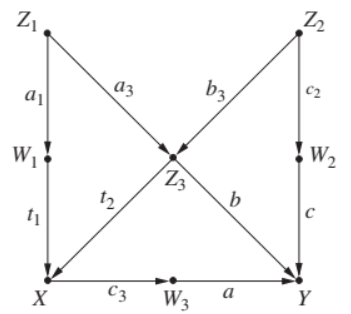

We render $Z_1$ d-separated from $W_2, W_3, X, Y$ once we condition on $W_1, Z_2, Z_3$.  So $\beta_{W_2} = \beta_{W_3} = \beta_{X} = \beta_{Y} = 0$.  Let's simulate this.

In [ ]:
round(summary(lm(Z1 ~ 0 + W1 + W2 + W3 + X + Y + Z2 + Z3))$coef,2)

,Estimate,Std. Error,t value,Pr(>|t|)
W1,0.14,0.01,25.25,0.00
W2,0.01,0.01,0.70,0.48
W3,0.00,0.01,0.44,0.66
X,0.00,0.01,0.30,0.76
Y,0.00,0.00,-0.63,0.53
Z2,-0.43,0.01,-49.11,0.00
Z3,0.22,0.01,22.88,0.00


### Answer to 3.8.1, f

***The model in Figure 3.18 implies that certain regression coefficients will remain invariant when an additional variable is added as a regressor. Identify five such coefficients with their added regressors.***

For this to happen, the dependent variable must be independent of the *new* regressor(s) given the *old* regressors.  So if we find potential regressors that are downstream of the old regressors, which do not open any additional paths, we answer the question.  Here are couple examples.

* $W_3 = \beta_{X} X + U'_3 \ (+ \beta_{W_1} W_1)^*$
* $Y = \beta_{W_3} W_3 + \beta_{Z_3} Z_3 + \beta_{W_2} W_2 + U \ (+ \beta_{X} X)^*$

I've denoted the new regressors like $()^*$.

Let's run simulations; I'll estimate the coefficients for both $W_3$ and $Y$, with and without the new regressors.

In [ ]:
round(summary(lm(W3 ~ 0 + X))$coef,2)
round(summary(lm(W3 ~ 0 + X + W1))$coef,2)

round(summary(lm(Y ~ 0 + W3 + Z3 + W2))$coef, 2)
round(summary(lm(Y ~ 0 + W3 + Z3 + W2 + X))$coef, 2)

,Estimate,Std. Error,t value,Pr(>|t|)
X,2,0,2239.23,0


,Estimate,Std. Error,t value,Pr(>|t|)
X,2,0.00,1068.03,0.00
W1,0,0.01,0.10,0.92


,Estimate,Std. Error,t value,Pr(>|t|)
W3,3,0.00,1631.57,0
Z3,3,0.01,250.07,0
W2,4,0.00,887.66,0


,Estimate,Std. Error,t value,Pr(>|t|)
W3,3.00,0.01,299.93,0.00
Z3,3.00,0.01,246.01,0.00
W2,4.00,0.00,882.57,0.00
X,0.01,0.02,0.26,0.79


Notice that the old regressors remain unchanged and the new regressors are (statistically) zero.

### Answer to 3.8.1, g

***Assume that variables $Z_2$ and $W_2$ cannot be measured. Find a way to estimate $b$ using regression coefficients. [Hint: Find a way to turn $Z_1$ into an instrumental variable for $b$.]***

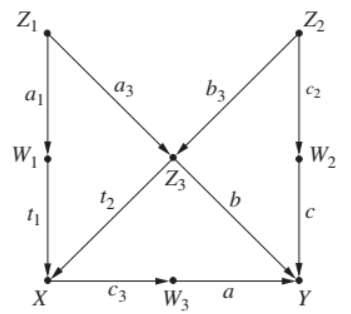

First, notice why we finding $b$ is not straightforward if we can't measure $Z_2$ and $W_2$: there is a backdoor path from $Z_3$ the runs through these variables; if we can't measure them, then we can't close that path.

In this case, we can use an "instrumental variable".  From p. 85-86, "A variable is called an 'instrument' if it is d-separated from $Y$ in $G_{\alpha}$ and it is d-connected to $X$".  You might need to read the page and look at Figure 3.17 to get the full context, but let's try to reason ourselves to an answer.

Notice that the total effect of $Z_3$ on $Y$ is $\tau_{Z_3} = b + t_2 c_3 a$.  So $b = \tau_{Z_3} - t_2 c_3 a$.

Next, notice that we can get an estimate for the total effect of $Z_1$ on $Y$ with $Y = \beta_{Z_1} Z_1 + U$ such that $\tau_{Z_1} = \beta_{Z_1} = a_3 \tau_{Z_3} + a_1 t_1 c_3 a$; the fact that $Z_2$ and $W_2$ cannot be measured is not a problem since these are downstream of a collider at $Z_3$, which is already closed by defualt.  

But by our definition of an instrumental variable, we want $Z_1$ to be d-separated from $Y$; this is no problem since we can measure other variables that accomplishes this, like $Y = \beta_{Z_1}' Z_1 + \beta_{W_1} W_1 + U$.  With this, we close one of the paths between $Z_1$ and $Y$ such that the estimated effect of $Z_1$ on $Y$ is $\tau_{Z_1}' = \beta_{Z_1}' = a_3 \tau_{Z_3}$

We can get an estimate of $a_3$ with $Z_3 = \gamma_{Z_1} Z_1 + U_3$ such that $a_3 = \gamma_{Z_1}$.

Plugging this into our estimate $\beta_{Z_1}' = \gamma_{Z_1} \tau_{Z_3}$

If you expand $\tau_{Z_3}$ and use algebra to solve for $b$, you get $\tau_{Z_3} = b + t_2 c_3 a = \frac{\beta_{Z_1}'}{\gamma_{Z_1}}$ such that

$$b = \frac{\beta_{Z_1}'}{\gamma_{Z_1}} - t_2 c_3 a$$

We can get estimates for each of
* $t_2$: $X = \beta_{Z_3} Z_3 + \beta_{Z_1} Z_1 + U'$; $t_2 = \beta_{Z_3}$
* $c_3$: $W_3 = \beta_{X} X + U_3'$; $C_3 = \beta_{X}$
* $a$: $Y = \beta_{W_3} W_3 + \beta_{X} X + U$; $a = \beta_{W_3}$

Let's simulate this.

In [ ]:
Y_Z1 <- lm(Y ~ 0 + Z1 + W1)
  beta_Z1 <- coef(Y_Z1)["Z1"]
Z3_Z1 <- lm(Z3 ~ 0 + Z1)
  gamma_Z1 <- coef(Z3_Z1)["Z1"]

X_Z3 <- lm(X ~ 0 + Z3 + Z1)
  t2_est <- coef(X_Z3)["Z3"]
W3_X <- lm(W3 ~ 0 + X)
  c3_est <- coef(W3_X)["X"]
Y_W3 <- lm(Y ~ W3 + X)
  a_est <-coef(Y_W3)["W3"]

b_est <- (beta_Z1 / gamma_Z1) - (t2_est * c3_est * a_est)

paste("The coded value for b equals", b)
paste("The estimate for a equals", round(b_est,2))

[1] "The coded value for b equals 3"

[1] "The estimate for a equals 3.21"

# Chapter 4

## A primer for counterfactuals

When I first learned about counterfactuals with this book, I found them very confusing.  I want to try to explain my initial confusion to keep you from the headache, and present the conception of counterfactuals that helps keep me straight.

Whereas the tools we've learned so far attempt to estimate <u>causal effects</u> as <u>averages across many cases</u>, counterfactuals attempt to estimate the <u>outcomes</u> of <u>individual</u> cases.  (There's some flexibility in both operations, but this is the gist).

This simple explanation is represented in the notation; take

$$𝔼[Y_{X=x'} | Z=z]$$

We should read this like "The expected value of $Y$ if $X=x'$, in cases where $Z=z$".  The last part about *cases where $Z=z$* needs a little explanation.

Think of each "case" as a single person.  For each measured variable, $X$ or $Z$, each person will have many things that makes them unique and which coalesce to affect the value of those measured variables, $U_1, U_2$.  So by focusing on scenarios where $Z=z$, we constrain the people we're considering.  So we can reinterpret $𝔼[Y_{X=x'} | Z=z]$ as something like "The expected value of $Y$ if $X=x'$ in people for whom $Z=z$".  In addition to a counterfactual, we might call this the "z-specific effect of...".

To get traction, let's look at the causal model that will be used in Question 4.3.1.

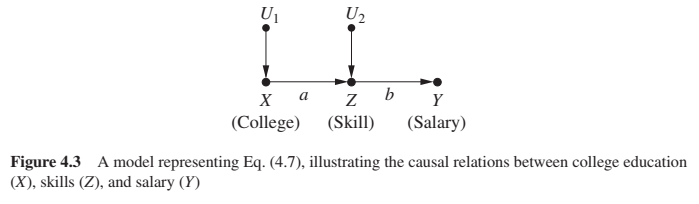

where, $U_1, U_2 \sim N(0,1); \ U_1 \perp U_2$.

Let's start with an easier problem than $𝔼[Y_{X=x'}|Z=z]$:

$$𝔼[Y_{X=x'} | X=x]$$

the expected value of $Y$ if $X=x'$ for scenarios (people) where $X=x$.

It is trivial to identify these scenarios because the only individuals for whom $X=x$ are those for whom $U_1 = x$.  So we can straightfowardly find $𝔼[Y_{X=x'} | X=x] = 𝔼[Y|X=x'] = Z_{X=x'}b = (x'a)b$.

Let's simulate this.

In [ ]:
N <- 100000

U1 <- rnorm(N)
  X <- round(U1)
    a <- 2
U2 <- rnorm(N)
  Z <- round(a*X + U2)
    b <- 3
U3 <- rnorm(N)
  Y <- b*Z + U3

We know from our model that $Y = x'ab$; we can test this directly.

In [ ]:
x_prime <- 2
Zx <- x_prime * a

# What's in our data
round(mean(Y[X==x_prime]),1)
round(mean(Y[Z==Zx]),1)

# Recreating the model
x_prime*a*b
Zx*b

[1] 12

[1] 12

[1] 12

[1] 12

Or we could see if our estimate bears this out.

In [ ]:
beta.x_Y <- summary(lm(Y[X==x_prime]~0+X[X==x_prime]))$coef[1]
  round(beta.x_Y*x_prime,1)

beta.x_Z <- summary(lm(Z[X==x_prime]~0+X[X==x_prime]))$coef[1]
  Zx.est <- x_prime*beta.x_Z
beta.Zx_Y <- summary(lm(Y[X==x_prime]~0+Z[X==x_prime]))$coef[1]
  round(beta.Zx_Y*Zx.est,1)

[1] 12

[1] 12

But what about when it's not so simple to identify specific scenarios?  That's the case with

$$𝔼[Y_{X=x'}|Z=z]$$

Why?  Notice that $z = aX + U_2 = aU_1 + U_2$.  Here, $z$ and $a$ are known, but not $U_1, U_2$.  So we have 1 equation and two unknowns.  Thus, there are many solutions-- nudge $U_1$ up a bit and nudge $U_2$ down a bit from any single solution and you get another solution--described by a probability distribution $p(U_1=u_1, U_2=u_2 | Z=z)$ (see Question 1.5.1, e).

Solving for this counterfactual is the topic of Question 4.3.1.

## Question 4.3.1

Consider the model in Figure 4.3 and assume that $U_1$ and $U_2$ are two independent Gaussian variables, each with zero mean and unit variance.

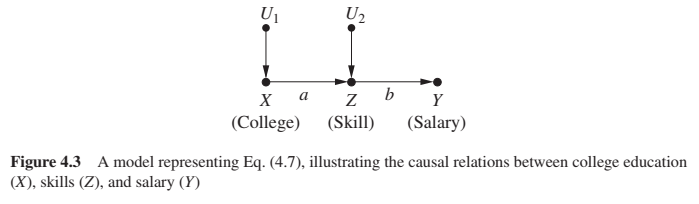

> (a) Find the expected salary of workers at skill level $Z = z$ had they received $x'$ years of college education. [Hint: Use Theorem 4.3.2, with e ∶ $Z = z$, and the fact that for any two Gaussian variables, say $X$ and $Z$, we have $E[X|Z = z] = E[x] + R_{XZ}(z − E[Z])$. Use the material in Sections 3.8.2 and 3.8.3 to express all regression coefficients in terms of structural parameters, and show that $E[Y_x|Z = z] = abx + bz∕(1 + a^2)]$.

> (b) Based on the solution for (a), show that the skill-specific effect of education on salary is independent on the skill level.

### Answer to 4.3.1, a

***Find the expected salary of workers at skill level $Z = z$ had they received $x'$ years of college education. [Hint: Use Theorem 4.3.2, with e ∶ $Z = z$, and the fact that for any two Gaussian variables, say $X$ and $Z$, we have $E[X|Z = z] = E[x] + R_{XZ}(z − E[Z])$. Use the material in Sections 3.8.2 and 3.8.3 to express all regression coefficients in terms of structural parameters, and show that $E[Y_{x'}|Z = z] = abx + bz∕(1 + a^2)]$.***

So we want to find

$$𝔼[Y_{X=x'} | Z=z]$$

Let's start by simulating this.

I'll start by generating some data.

In [ ]:
N <- 10000

U1 <- rnorm(N)
  X <- (U1)
    a <- 2
U2 <- rnorm(N)
  Z <- round(a*X + U2) # rounding so I can select Z==z below
    b <- 3
U3 <- rnorm(N)
  Y <- (b*Z + U3)

The first thing we want to do is to find which individuals we refer to when $Z=z$.

In [ ]:
z_obs <- 2
U1_z <- U1[Z==z_obs]
U2_z <- U2[Z==z_obs]
U3_z <- U3[Z==z_obs]

Now we need to replace $X=U_1$ with $x'$ in our causal model.

In [ ]:
x_prime <- 3
Zx <- a*x_prime

and enter the error terms $U|Z=z$.

In [ ]:
Yx_z <- (b*(Zx + U2_z) + U3_z)
round(mean(Yx_z),1)

[1] 19.2

This agrees with the analytical statement we're meant to use:

$$\begin{aligned}
𝔼[Y_{X=x} | Z=z] &= 𝔼[Y|Z=z] + \tau (x' - 𝔼[X|Z=z]) \\
&= abx' + \frac{bz}{1 + a^2}
\end{aligned}
$$

where $\tau$ is the slope of the total effect of $X$ on $Y$, $\beta_{XY}$ from $𝔼[Y|\text{do}(X=x')] = \beta_{XY} X$.

In [ ]:
E.Y_z <- round(summary(lm(Y~0+Z))$coef[1] * z_obs,1)
tau <- round(summary(lm(Y~0+X))$coef[1],1)
E.X_z <- round(summary(lm(X~0+Z))$coef[1] * z_obs,1)

E.Y_z + tau*(x_prime - E.X_z)
a*b*x_prime + ((b*z_obs)/(1 + a^2))

[1] 19.2

[1] 19.2

This is a very interesting result: it turns out that our procedure for finding $U|z$ and then estimating $Y_x | u$, we get the same output as if we employed the basic linear model

$$𝔼[Y_{X=x} | Z=z] = \alpha + \beta \tilde{x}$$

where $\alpha = 𝔼[Y|Z=z]$, $\beta = \tau$, and $\tilde{x} = x' - 𝔼[X|Z=z]$.  In other words, the counterfactual (in linear systems) is just a basic linear model.

Every bit of the linear model makes sense: When $x' = 𝔼[X|Z=z]$, we need only be concerned with $\alpha = 𝔼[Y|Z=z]$; when $x' \not = 𝔼[X|Z=z]$, we must adjust our estimate $\alpha = 𝔼[Y|Z=z]$ by $\beta$ scaled by the discrepency between $x'$ and $𝔼[X|Z=z]$, $(x' - 𝔼[X|Z=z])$.  The reason why $\beta = \tau$ is because we have essentially regressed $Y$ on $X$, which we did to find $\tau$, but adjusted for $Z=z$ by centering $x'$ on $Z=z$ and setting the intercept to the values $Y$ when $Z=z$.

I feel like we might arrive at either approach by ourselves once we clearly understood the intention of counterfactuals.

### Answer to 4.3.1, b

***Based on the solution for (a), show that the skill-specific effect of education on salary is independent of the skill level.***

We're asked to show that, according to (a),

$$\begin{aligned}
𝔼[Y_{X=x_1} | Z=z] - 𝔼[Y_{X=x_0} | Z=z] &= 𝔼[Y_{X=x_1} - Y_{X=x_0} | Z=z] \\
&= 𝔼[Y_{X=x_1} - Y_{X=x_0}]
\end{aligned}$$

This is apparent in our basic linear model

$$𝔼[Y_{X=x'} | Z=z] = \alpha + \beta \tilde{x}$$

because it does not depend on $Z$.  We can go furhter, though, with

$$\begin{aligned}
𝔼[Y_{X=x_1} - Y_{X=x_0} | Z=z] &= (𝔼[Y|Z=z] + \tau (x_1 - 𝔼[X|Z=z])) - (𝔼[Y|Z=z] + \tau (x_0 - 𝔼[X|Z=z])) \\
&= (\tau (x_1 - 𝔼[X|Z=z]) - (\tau (x_0 - 𝔼[X|Z=z]) \\
&= (\tau x_1 - \tau 𝔼[X|Z=z]) - (\tau x_0 - \tau 𝔼[X|Z=z]) \\
&= \tau x_1 - \tau x_0 \\
&= \tau(x_1 - x_0)
\end{aligned}$$

which does not depend on $Z$.

Similarily, we could use

$$\begin{aligned}
𝔼[Y_{X=x_1} - Y_{X=x_0} | Z=z] &= (abx_1 + \frac{bz}{1 + a^2}) - (abx_0 + \frac{bz}{1 + a^2}) \\
&= abx_1 - abx_0 \\
&= ab(x_1 - x_0) \\
\end{aligned}
$$

which, again, does not depend on $Z$.

## Question 4.3.2

> (a) Describe how the parameters $a$, $b$, $c$ of Model 2 (Figure 4.1) can be estimated from nonexperimental data.

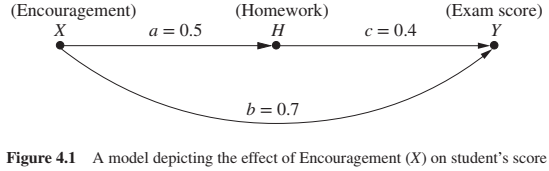

> (b) In the model of Figure 4.3, find the effect of education on those students whose salary is $Y = 1$. [Hint: Use Theorem 4.3.2 to compute $E[Y_1 − Y_0|Y = 1]$.]

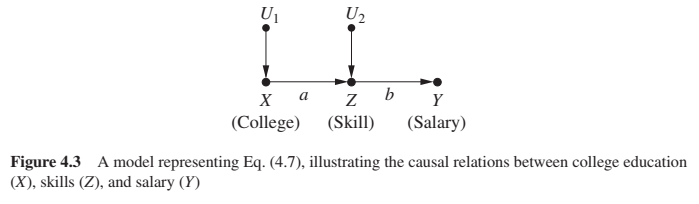


> (c) Estimate $𝜏$ and the $ETT = E[Y_1 − Y_0|X = 1]$ for the model described in Eq. (4.19). [Hint: Use the basic definition of counterfactuals, Eq. (4.5) and the equality $E[Z|X = x′] = R_{ZX}x′$.]

> **Eqn (4.19):** $Y = bX + cH + \delta XH + U_Y$

### Answer to 4.3.2, a

***Describe how the parameters $a$, $b$, $c$ of Model 2 (Figure 4.1) can be estimated from nonexperimental data.***

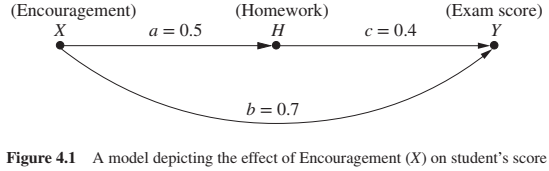

* $a:$
 * $H = \beta_{XH} X + U_H$
  * $a = \beta_{XH}$
* $b, c:$
 * $Y = \beta_{XY} X + \beta_{HY} H + U_Y$
  * $b = \beta_{XY}, c = \beta_{HY}$

### Answer to 4.3.2, b

***In the model of Figure 4.3, find the effect of education on those students whose salary is $Y = 1$. [Hint: Use Theorem 4.3.2 to compute $E[Y_1 − Y_0|Y = 1]$.]***

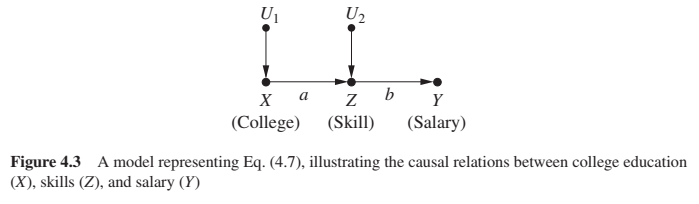

We're asked to find the *effect of treatment in the the treated (ETT)* for individuals with $Y=1$.  For this, we first identify individuals for whom $Y=1$.  Then, in this group, we find the effects of $X$ on $Y$ with regression.  Finally, we use the estimates from the regression to simulate $X=1$ and $X=0$, subtracting the latter from the former.

$$\begin{aligned}
\text{ETT} &= 𝔼[Y_{X=1} - Y_{X=0} | Y=1] \\
&= 𝔼[Y_{X=1} | Y=1] - 𝔼[Y_{X=0} | Y=1] \\
&= (𝔼[Y|Y=1] + \tau(1 - 𝔼[X|Y=1]) - (𝔼[Y|Y=1] + \tau(0 - 𝔼[X|Y=1]) \\
&= (\tau(1 - 𝔼[X|Y=1]) - (\tau(0 - 𝔼[X|Y=1]) \\
&= \tau \\
\end{aligned}$$

where $\tau = \beta_{XY}$ from $𝔼[Y|\text{do}(X=x)] = \beta_{XY} X$.

Of course this is the answer.  What else could the effect of treatment be if not the effect of treatment?

### Answer to 4.3.2., c

***Estimate $𝜏$ and the $ETT = E[Y_1 − Y_0|X = 1]$ for the model described in Eq. (4.19). [Hint: Use the basic definition of counterfactuals, Eq. (4.5) and the equality $E[Z|X = x′] = R_{ZX}x′$.]***

***Eqn (4.19): $Y = bX + cH + \delta XH + U_Y$***

The critical things here are that Eqn (4.19) is describing a situation where we have a non-linear interaction term in the mix $\delta XH$ and our model has changed such that $X \leftarrow H$ rather than $X \rightarrow H$.

So our model $M$ is:
* $H = U_H$
* $X = aH + U_X$
* $Y = bX + cH + \delta XH + U_Y$

The book does not give clear instructions for how to deal with the interaction term, so we'll need to do some experimentation.

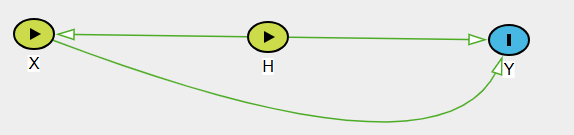

It's actually unclear what variable we're suppossed to find a counterfacutal for; do the subscripts $_1$ and $_0$ represent $X$ or $H$?  So let's do both.

#### Counterfactual for $X$

##### Discovering the formula in the book is misleading

It seems that we want to find

$$\begin{aligned}
\text{ETT} &= 𝔼[Y_{X=1} - Y_{X=0} | X=1] \\
&= 𝔼[Y_{X=1} | X=1] - 𝔼[Y_{X=0} | X=1] \\
&= (𝔼[Y|X=1] + \tau(1 - 𝔼[X|X=1])) - (𝔼[Y|X=1] + \tau(0 - 𝔼[X|X=1])) \\
\end{aligned}$$

where

$\tau = 𝔼[Y|\text{do}(x'+1)] - 𝔼[Y|\text{do}(x')]$.

Due to the interaction term, this will turn out to be incorrect; but let's push ahead anyway.

Let's find each of our terms.

> $\begin{aligned}
𝔼[Y|X=1] &= 𝔼[b + cH + dH + U_Y | X=1] \\
&= b + c𝔼[H|X=1] + d𝔼[H|X=1] \\
\end{aligned}$

> > $\begin{aligned}
𝔼[H|X=1] &= \beta_{XH} \\
&= \frac{\text{cov}(X,H)}{\text{var}(X)} \\
&= \frac{\text{cov}(aH + U_X, U_H)}{\text{var}(aH + U_X)} \\
&= \frac{\text{cov}(aH, U_H)+\text{cov}(U_X, U_H)}{\text{var}(aH) + \text{var}(U_X)} \\
&= \frac{a \ \text{cov}(H, U_H)+0}{a^2 \text{var}(H) + 1} \\
&= \frac{a \ \text{cov}(U_H, U_H)}{a^2 \text{var}(U_H) + 1} \\
&= \frac{a \ \text{var}(U_H)}{a^2 (1) + 1} \\
&= \frac{a \ (1)}{a^2 + 1} \\
&= \frac{a}{a^2 + 1} \\
\end{aligned}$

> > $\begin{aligned}
𝔼[Y|X=1] &= b + c\frac{a}{a^2 + 1} + d\frac{a}{a^2 + 1} \\
&= b + \frac{a(c+d)}{a^2 + 1} \\
\end{aligned}$

> $\begin{aligned}
\tau &= 𝔼[Y|\text{do}(X=1)] - 𝔼[Y|\text{do}(X=0)] \\
&= 𝔼[b + cH + dH + U_Y] - 𝔼[cH + U_Y] \\
&= (b + c𝔼[H] + d𝔼[H]) - (c𝔼[H]) \\
&= b + d𝔼[H] \\
&= b + d(0) \\
&= b \\
\end{aligned}$

> $𝔼[X|X=1]=1$

Putting this all together,

$$\begin{aligned}
\text{ETT} &= 𝔼[Y_{X=1} - Y_{X=0} | X=1] \\
&= 𝔼[Y_{X=1} | X=1] - 𝔼[Y_{X=0} | X=1] \\
&= ((𝔼[Y|X=1] + \tau(1 - 𝔼[X|X=1])) - ((𝔼[Y|X=1] + \tau(0 - 𝔼[X|X=1])) \\
&= \left(\left((b + \frac{a(c+d)}{a^2 + 1}\right) + b(1-1) \right) - \left(\left((b + \frac{a(c+d)}{a^2 + 1}\right) + b(0-1) \right) \\
&= b \\
\end{aligned}$$

The reason we know this is wrong is twofold: first, we know that the effect of changing $X$ acts through both $b$ and $dH$ but our answer here only reflects $b$; second, assuming the book is correct, we're told that $\tau-\text{ETT}=\frac{da}{1+a^2} \rightarrow \text{ETT} = \tau - \frac{da}{1+a^2}$.

##### A more-general expression

Let's try to get a different expression for

$$\text{ETT} = 𝔼[Y_{X=x'_2}|Z=z] - 𝔼[Y_{X=x'_1}|Z=z]$$

where I'm using $z$ to denote evidence rather that $e$, which is $X=1$ in this problem.  The two terms are basically identical except for the counterfactual value of $x'$ in either case, so let's blow up a generic version of these terms.

$$\begin{align}
𝔼[Y_{x'}|z] &= 𝔼[(bX + cH + dXH + U_Y)_{x'}|z] \\
&= 𝔼[(bX)_{x'}|z] + 𝔼[(cH)_{x'}|z] + 𝔼[(dXH)_{x'}|z] + 𝔼[(U_Y)_{x'}|z] \\
&= b𝔼[X_{x'}|z] + c𝔼[H_{x'}|z] + d𝔼[(XH)_{x'}|z] + 𝔼[(U_Y)_{x'}|z] \\
&= b𝔼[x'|z] + c𝔼[H|z] + d𝔼[x'H|z] + 𝔼[U_Y|z] \\
&= bx' + c(\beta_{ZH}z) + dx'(\beta_{ZH}z) + 𝔼[U_Y|z] \\
&= bx' + (c+dx')\beta_{ZH}z + 𝔼[U_Y|z] \\
&= bx' + (c+dx')\frac{a}{a^2+1}z + 𝔼[U_Y|z] \text{ (see above)}\\
\end{align}$$

Now, let's plug this into our expression for $\text{ETT}$.

$$\begin{align}
\text{ETT} &= 𝔼[Y_{x'_2}|z] - 𝔼[Y_{x'_1}|z] \\
&= \left(bx'_2 + (c+dx'_2)\frac{a}{a^2+1}z + 𝔼[(U_Y)_x'|z] \right) - \left(bx'_1 + (c+dx'_1)\frac{a}{a^2+1}z + 𝔼[(U_Y)_x'|z] \right) \\
&= \left(bx'_2 + \frac{ac}{a^2+1}z + \frac{adx'_2}{a^2+1}z + 𝔼[(U_Y)_x'|z] \right) - \left(bx'_1 + \frac{ac}{a^2+1}z + \frac{adx'_1}{a^2+1}z + 𝔼[(U_Y)_x'|z] \right) \\
&= b(x'_2 - x'_1) + \frac{ad}{a^2+1}(x'_2-x'_1)z \\
&= \left(b + \frac{ad}{a^2+1}z\right)(x'_2-x'_1) \\
\end{align}$$

Finally, let's insert our problems' values for $x'_2=1, x'_1=0, z: X=x=1$

$$\begin{align}
\text{ETT} &= \left(b + \frac{ad}{a^2+1}z\right)(x'_2-x'_1) \\
&= \left(b + \frac{ad}{a^2+1}1\right)(1-0) \\
&= b + \frac{ad}{a^2+1}
\end{align}$$

From above, we know that $\tau=b$ such that

$$\begin{align}
\text{ETT} &= b + \frac{ad}{a^2+1} \\
&= \tau + \frac{ad}{a^2+1} \\
\end{align}$$

which is what we meant to show.

Let's do some simulation.

First, we'll generate some data.

In [ ]:
# Generate Data
n <- 10000

U_H <- rnorm(n)
  H <- (U_H)
    a <- 1.5
    c <- 2.5
U_X <- rnorm(n)
  X <- round(a*H + U_X)
    b <- 2
d <- 3
U_Y <- rnorm(n)
  Y <- b*X + c*H + d*X*H + U_Y

Now let's find ETT as per our expression above:

$$\text{ETT} = b + \frac{ad}{a^2 + 1}$$

In [ ]:
(ETT0 <- round(b + (a*d)/(a^2 + 1), 1))

[1] 3.4

Now let's use the (i) Abduction, (ii) Action, (iii) Prediction process described in the chapter.

In [ ]:
# (i) Abduction: Find U's given X=1
U_H.x <- U_H[X==1]
U_X.x <- U_X[X==1]
U_Y.x <- U_Y[X==1]

In [ ]:
# (ii) Action, Replace X=x'
x_prime1 <- 0
x_prime2 <- 1

H.x1 <- U_H.x
X.x1 <- x_prime1
Y.x1 <- b*X.x1 + c*H.x1 + d*X.x1*H.x1 + U_Y.x

H.x2 <- U_H.x
X.x2 <- x_prime2
Y.x2 <- b*X.x2 + c*H.x2 + d*X.x2*H.x2 + U_Y.x

In [ ]:
# (iii) Predict
E_Y.x1 <- round(mean(Y.x1),1)
E_Y.x2 <- round(mean(Y.x2),1)

In [ ]:
# ETT
(ETT1 <- round(E_Y.x2 - E_Y.x1, 2))

[1] 3.4

Here, we used the hard-coded values for $a, b, c, d$, but let's repeat this by estimating them.

In [ ]:
a_est <- summary(lm(X ~ 0+H))$coef["H", "Estimate"]

bcd_M <- summary(lm(Y ~ 0+X*H))$coef[,"Estimate"]
  b_est <- bcd_M["X"]
  c_est <- bcd_M["H"]
  d_est <- bcd_M["X:H"]

In [ ]:
Y.x1_ <- b_est*X.x1 + c_est*H.x1 + d_est*X.x1*H.x1 + U_Y.x
Y.x2_ <- b_est*X.x2 + c_est*H.x2 + d_est*X.x2*H.x2 + U_Y.x

E_Y.x1_ <- round(mean(Y.x1_),1)
E_Y.x2_ <- round(mean(Y.x2_),1)

(ETT1_ <- round(E_Y.x2_ - E_Y.x1_, 1))

[1] 3.4

#### Counterfactual for $H$

$$\begin{align}
𝔼[Y_{h'}|z] &= 𝔼[(bX + cH + dXH + U_Y)_{h'}|z] \\
&= 𝔼[(bX)_{h'}|z] + 𝔼[(cH)_{h'}|z] + 𝔼[(dXH)_{h'}|z] + 𝔼[(U_Y)_{h'}|z] \\
&= b𝔼[X_{h'}|z] + c𝔼[H_{h'}|z] + d𝔼[X_{h'}|z]H_{h'} + 𝔼[(U_Y)_{h'}|z] \\
&= b𝔼[X|z] + ch' + d𝔼[X|z]h' + 𝔼[(U_Y)_{h'}|z] \\
\end{align}$$

$$\begin{align}
\text{ETT} &= 𝔼[Y_{h'_2}|z] - 𝔼[Y_{h'_2}|z] \\
&= \left(b𝔼[X|z] + ch'_2 + d𝔼[X|z]h'_2 + 𝔼[(U_Y)_{h'_2}|z] \right) - \left(b𝔼[X|z] + ch'_1 + d𝔼[X|z]h'_1 + 𝔼[(U_Y)_{h'_1}|z] \right) \\
&= c(h'_2 - h'_1) + d𝔼[X|z](h'_2 - h'_1) \\
&= (c + d𝔼[X|z])(h'_2 - h'_1) \\
\end{align}$$

$$\begin{align}
\text{ETT}(z: X=x=1; h'_2 = 1, h'_1 = 0) &= (c+d𝔼[X|z])(h'_2 - h'_1) \\
&= (c + d𝔼[X|X=1])(1-0) \\
&= (c+d(1))(1) \\
&= c+d
\end{align}$$

In [ ]:
(ETT0 <- c + d)

[1] 5.5

In [ ]:
# (i) Abduction: Find U's given X=1
U_H.x <- U_H[X==1]
U_X.x <- U_X[X==1]
U_Y.x <- U_Y[X==1]

In [ ]:
# (ii) Action, Replace H=h'
h_prime1 <- 0
h_prime2 <- 1

H.x1h1 <- h_prime1
X.x1h1 <- 1
Y.x1h1 <- b*X.x1h1 + c*h_prime1 + d*X.x1h1*h_prime1 + U_Y.x

H.x1h2 <- h_prime2
X.x1h2 <- 1
Y.x1h2 <- b*X.x1h2 + c*h_prime2 + d*X.x1h2*h_prime2 + U_Y.x

In [ ]:
# (iii) Predict
E_Y.x1h1 <- round(mean(Y.x1h1),1)
E_Y.x1h2 <- round(mean(Y.x1h2),1)

In [ ]:
# ETT
(ETT1 <- round(E_Y.x1h2 - E_Y.x1h1, 2))

[1] 5.5

## Example 4.4.1, Recruitment to a Program

*(As good as this book is, I feel that the final sections (4.4 and 4.5) are a little short on the details.  So in addition to the Questions, I thought I'd also treat the examples in these final sections.)*

A government is funding a job training program aimed at getting jobless people back into the workforce. A pilot randomized experiment shows that the program is effective; a higher percentage of people were hired among those who finished the program than among those who did not go through the program. As a result, the program is approved, and a recruitment effort is launched to encourage enrollment among the unemployed, by offering the job training program to any unemployed person who elects to enroll.

Lo and behold, enrollment is successful, and the hiring rate among the program’s graduates turns out even higher than in the randomized pilot study. The program developers are happy with the results and decide to request additional funding.

Oddly, critics claim that the program is a waste of taxpayers’ money and should be terminated. Their reasoning is as follows: While the program was somewhat successful in the experimental study, where people were chosen at random, there is no proof that the program accomplishes its mission among those who choose to enroll of their own volition. Those who self-enroll, the critics say, are more intelligent, more resourceful, and more socially connected than the eligible who did not enroll, and are more likely to have found a job regardless of the training. The critics claim that what we need to estimate is the differential benefit of the program on those enrolled: the extent to which hiring rate has increased among the enrolled, compared to what it would have been had they not been trained.

> **Who is correct?**

The first thing I want to do is draw some DAGs.  I can think of at least 3 models.

**Training affects hiring, independently of aptitude:**

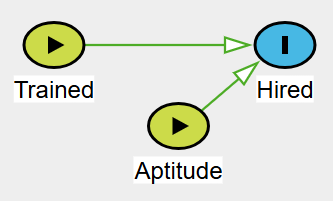

**Aptitude affects both training and hiring, but training doesn't affect hiring:**

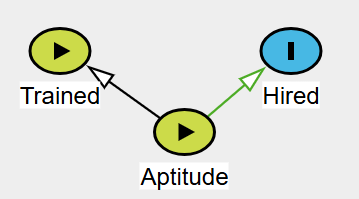

**Aptitude affects both training and hiring, and training affects hiring:**

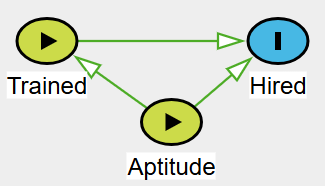

The "critics" believe that DAG 2 is correct, while the "believers" believe that DAG 1 or DAG 3 are correct.  (Critics may also believe that DAG 3 is correct, but that the link between Trained and Hired is null).

From here, things get a little nuanced: The prompt says that there was a randomized experiment in which training was found to increase hiring.  But the critics are responding to post-experiment reporting in which training was found to have an even higher success rate.  Their claim is NOT that the program does not work for a randomly-selected set of participants, which was refuted in the randomized experiment, but rather that those choose to enroll in the real world may have found employeement regradless of the training because they may also have above-average aptitude.  Hence, they view the success of the program as potentially stemming from a selection bias--presenting the possibility that the program has no effect on employment in the real world.

This is interesting because this critique cannot be addressed by a randomized experiment; we actually have to use observational data and counterfactuals.

(However, I think we could reason ourselves to the correct conclusion without any math: the randomized experiment has already assured us that at least some of the trained individuals represent those that would enroll in the real world, and further that training had an effect.)

In other words, we must find the effect of training in the trained (ETT).

$$\text{ETT} = 𝔼[H_{T=1}|T=1] - 𝔼[H_{T=0}|T=1]$$

This represents the difference in hiring for trained individuals between the actual scenario in which they recieved training ($𝔼[H_{T=1}|T=1]$) and the hypothetical scenario in which they received no training ($𝔼[H_{T=0}|T=1]$).

In this case, the actual scenario is trivial to estimate: since we observed this: $𝔼[H_{T=1}|T=1] = 𝔼[H|T=1]$ by the "consistency rule" (If $X=x$, then $Y_x = y$; Eqn 4.6, p. 94).  But the tricky term is the hypothetical one, $𝔼[H_{T=0}|T=1] = 𝔼[H|T=1]$, since we don't know what it would have been like had these individuals ($T=1$) not received training ($H_{T=0}$).

If we could model the scenario, we might stand a chance.  If we're dealing with linear functions, our expression might be:

$$\begin{align}
𝔼[H_{T=1}|T=1] &= 𝔼[(aA + bT + U_H)_{T=1}|T=1] \\
&= 𝔼[(aA)_{T=1}|T=1] + 𝔼[(bT)_{T=1}|T=1] + 𝔼[(U_H)_{T=1}|T=1] \\
&= 𝔼[aA|T=1] + 𝔼[b(1)|T=1] + 𝔼[U_H|T=1] \\
&= a𝔼[A|T=1] + b + 𝔼[U_H|T=1] \\
&= a \frac{\text{cov}(A, T)}{\text{var}(T)} + b + 𝔼[U_H|T=1] \\
&= a \frac{\text{cov}(U_A, cA+U_T)}{\text{var}(U_T)} + b + 𝔼[U_H|T=1] \\
&= a \frac{\text{cov}(U_A, cA) + \text{cov}(U_A, U_T)}{\sigma^2_T} + b + 𝔼[U_H|T=1] \\
&= a \frac{\text{cov}(U_A, A)c + 0}{\sigma^2_T} + b + 𝔼[U_H|T=1] \\
&= a \frac{\text{cov}(U_A, U_A)c}{\sigma^2_T} + b + 𝔼[U_H|T=1] \\
&= a \frac{\text{var}(U_A)c}{\sigma^2_T} + b + 𝔼[U_H|T=1] \\
&= a \frac{\sigma^2_A c}{\sigma^2_T} + b + 𝔼[U_H|T=1] \\
&= ac \frac{\sigma^2_A}{\sigma^2_T} + b + 𝔼[U_H|T=1] \\
\end{align}$$

\

$$\begin{align}
𝔼[H_{T=0}|T=1] &= 𝔼[(aA + bT + U_T)_{T=0}|T=1] \\
&= 𝔼[(aA)_{T=0}|T=1] + 𝔼[(bT)_{T=0}|T=1] + 𝔼[(U_T)_{T=0}|T=1] \\
&= 𝔼[aA|T=1] + 𝔼[b(0)|T=1] + 𝔼[U_H|T=1] \\
&= a𝔼[A|T=1] + 0 \\
&= a \frac{\text{cov}(A, T)}{\text{var}(T)} + 𝔼[U_H|T=1] \\
&= a \frac{\text{cov}(U_A, cA+U_T)}{\text{var}(U_T)} + 𝔼[U_H|T=1] \\
&= a \frac{\text{cov}(U_A, cA) + \text{cov}(U_A, U_T)}{\sigma^2_T} + 𝔼[U_H|T=1] \\
&= a \frac{\text{cov}(U_A, A)c + 0}{\sigma^2_T} + 𝔼[U_H|T=1] \\
&= a \frac{\text{cov}(U_A, U_A)c}{\sigma^2_T} + 𝔼[U_H|T=1] \\
&= a \frac{\text{var}(U_A)c}{\sigma^2_T} + 𝔼[U_H|T=1] \\
&= a \frac{\sigma^2_A c}{\sigma^2_T} + 𝔼[U_H|T=1] \\
&= ac \frac{\sigma^2_A}{\sigma^2_T} + 𝔼[U_H|T=1] \\
\end{align}$$

\

$$\begin{align}
\text{ETT} &= 𝔼[H_{T=1}|T=1] - 𝔼[H_{T=0}|T=1] \\
&= \left(ac \frac{\sigma^2_A}{\sigma^2_T} + b + 𝔼[U_H|T=1] \right) - \left(ac \frac{\sigma^2_A}{\sigma^2_T} + 𝔼[U_H|T=1] \right) \\
&= b \\
\end{align}$$

Which is convenient because we can get an estimate for $b$ from the randomized trial.

So actually, this is no more difficult than the answer to 4.3.2, c.

But in this example, the authors are drawing our attention to a connection with the backdoor criterion: if the backdoors can be closed between the exposure of interest ($T$) and the outcome ($H$) by conditioning on a set of variables ($A$), then we can derive an expression for even hypothetical counterfactuals.

In our model, we can close the backdoor between $T$ and $H$ by conditioning on $A$.  The book derives the expression for the counterfactuals with a modified backdoor-adjustment formula:

$$p(H_{T=t'}|T=t) = \sum_A{p(H=h|T=t', A=a) \times p(A=a|T=t)}$$

## Question 4.4.1

> (a) Prove that, if $X$ is binary, the effect of treatment on the treated can be estimated from both observational and experimental data. Hint: Decompose $E[Y_x]$ into
> $$E[Y_{x'}] = E[Y_{x'}|x']P(x') + E[Y_{x'}|x]P(x)$$

> (b) Apply the result of Question (a) to Simpson’s story with the nonexperimental data of Table 1.1, and estimate the effect of treatment on those who used the drug by choice. [Hint: Estimate $E[Y_x]$ assuming that gender is the only confounder.]

> > 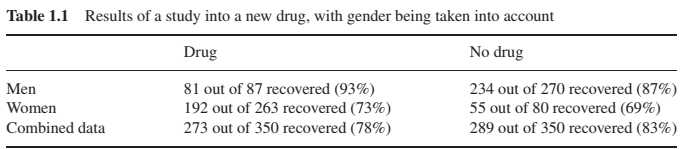

> (c) Repeat Question (b) using Theorem 4.3.2 and the fact that $Z$ in Figure 3.3 satisfies the backdoor criterion. Show that the answers to (b) and (c) coincide.

> > **Theorem 4.3.2** Let $𝜏$ be the slope of the total effect of $X$ on $Y$,

> > $$𝜏 = E[Y|do(x + 1)] − E[Y|do(x)]$$

> > then, for any evidence $Z = e$, we have

> > $$E[Y_{X=x}|Z = e] = E[Y|Z = e] + 𝜏(x − E[X|Z = e]) \ \ \ \ \ \text{ (4.17)}$$

> > 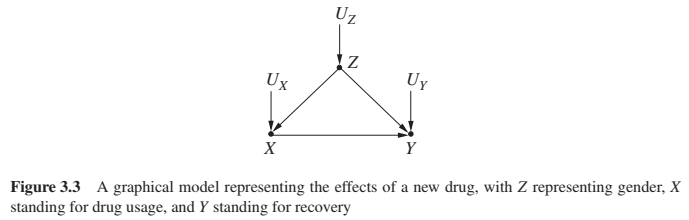

### Answer to Question 4.4.1, a

***Prove that, if $X$ is binary, the effect of treatment on the treated can be estimated from both observational and experimental data. Hint: Decompose $E[Y_x]$ into***
> ***$$E[Y_{x'}] = E[Y_{x'}|x']P(x') + E[Y_{x'}|x]P(x)$$***

Roughly speaking, we're being asked to find expressions for $𝔼[Y_{x'}]$ that don't invoke counterfactual notation $Y_{x'}$.  We'll then use these in the expression for $\text{ETT} = 𝔼[Y_{x'=1}|X=1] - 𝔼[Y_{x'=0}|X=1]$.

We can take the Hint because $X$ is binary: $1$ or $0$.  Here, $x=1$ (hence, in the treated) and $x' \in \{0, 1\}$.

When $x' = x = 1$, then $𝔼[Y_{x'}|x'] = 𝔼[Y|x'] = 𝔼[Y|X=1]$ by the consistency rule (mentioned in Example 4.4.1).

So now we're left with trying to find an expression for $𝔼[Y_{x'}|x]P(x)$ when $x' = 0 \not= x = 1$, $𝔼[Y_{x'=0}|X=1]$.  Again, notice this is the tricky part because we don't have data wherein the treated individuals ($X=1$) did NOT receive treatment ($X=0$).

Let's start with our decomposed Hint, then algebraically isolating $𝔼[Y_{x'}|x] = \frac{𝔼[Y_{x'}] - 𝔼[Y_{x'}|x']p(x')}{p(x)} = \frac{𝔼[Y_{x'}] - 𝔼[Y|x']p(x')}{p(x)}$.  If interested in $𝔼[Y_{x'=0}|X=1]$, then $𝔼[Y_{x'=0}|X=1] = \frac{𝔼[Y_{x'=0}] - 𝔼[Y|X=x'=0]p(X=x'=0)}{p(X=1)} = \frac{𝔼[Y_{x'=0}] - 𝔼[Y|X=0]p(X=0)}{p(X=1)}$. Let us now plug this into the expression for $\text{ETT}$:

$$\begin{align}
\text{ETT} &= 𝔼[Y_{x'=1}|X=1] - 𝔼[Y_{x'=0}|X=1] \\
&= 𝔼[Y|X=1] - \frac{𝔼[Y_{x'=0}] - 𝔼[Y|{X=0}]p(X=0)}{p(X=1)} \\
\end{align}$$

We're very close to an counterfactual-free expression, expcept for the $𝔼[Y_{x'=0}]$ in the numerator of the second right-hand term.  How do we get this?  We can only get it if we have data for $Y|(X=0)$; if we have this data, then

1. **Abduction:** Recall that $Y_{x'=0} = Y_{x'=0}(u)$, where we use evidence $E=e$ to find $U=u$.  Here, $E=e=(X=0)$ such that $u$ are the cases in which $X=0$.  So we're left with $Y_{x'=0}(u) = Y|X=0$
2. **Modify:** Now we modify our SCM to apply the exposure $X=x'$.  If $Y=bX+cZ+U_Y$, we modify as $Y_{x'}=bx'+cZ+U_Y$ where $x=0$ such that $Y_{x'=0}=cZ+U_Y$.
3. **Predict:** Using cases $u$ and our modified model, we predict $Y$.

Notice here, assuming Figure 3.3 is an appropriate DAG, that $Y_{x'=0} = Y|do(X=0)$.  Hence, $𝔼[Y_{x'=0}] = 𝔼[Y|do(X=0)]$

Plugging this into our ETT expression, we get

$$\begin{align}
\text{ETT} &= 𝔼[Y_{x'=1}|X=1] - 𝔼[Y_{x'=0}|X=1] \\
&= 𝔼[Y|X=1] - \frac{𝔼[Y|\text{do}(X=0)] - 𝔼[Y|X=0]p(X=0)}{p(X=1)} \\
\end{align}$$

### Answer to Question 4.4.1, b

***Apply the result of Question (a) to Simpson’s story with the nonexperimental data of Table 1.1, and estimate the effect of treatment on those who used the drug by choice. [Hint: Estimate $E[Y_x]$ assuming that gender is the only confounder.]***

> > 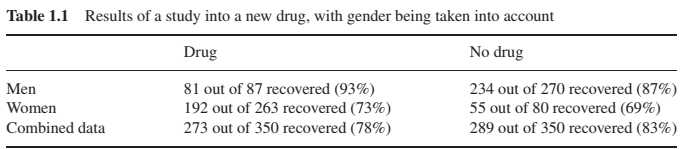

To comport with the result from part a, let us assign

> $X: \text{drug status}; \ 0=\text{no drug}, 1=\text{yes drug}$

> $Y: \text{recovery status}; \ 0=\text{not recovered}, 1=\text{yes recovered}$

> $Z: \text{sex}; \ 0=\text{female}, 1=\text{male}$

and then use the following DAG

> > 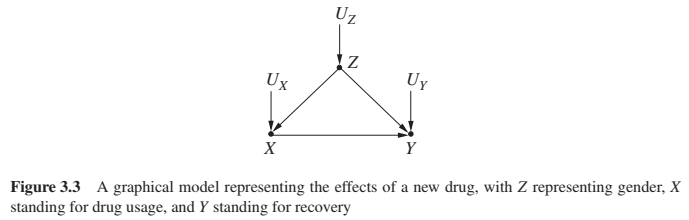

Can we discover the ETT by the result in part a?

$$\begin{align}
\text{ETT} &= 𝔼[Y|X=1] - \frac{𝔼[Y_{x'=0}] - 𝔼[Y|X=0]p(X=0)}{p(X=1)} \\
&= \frac{81+192}{87+263} - \frac{𝔼[Y|\text{do}(X=0)] - \left(\frac{234+55}{270+80} \times \frac{270+80}{(87+263)+(270+80)}\right)}{\frac{87+263}{(87+263)+(270+80)}} \\
&= \frac{273}{350} - \frac{(1 \times p[Y|\text{do}(X=0)]) - \left(\frac{289}{350} \times \frac{350}{350+350}\right)}{\frac{350}{350+350}} \\
&\approx 0.78 - \frac{p[Y=1|\text{do}(X=0)] - \left(0.83 \times 0.50\right)}{0.50} \\
&\approx 0.78 - \frac{\sum_{z=0}^1 p(Y=1|X=0, Z=z)p(Z=z) - 0.42}{0.50} \\
&\approx 0.78 - \frac{(p(Y=1|X=0, Z=0)p(Z=0) + p(Y=1|X=0, Z=1)p(Z=1)) - 0.42}{0.50} \\
&\approx 0.78 - \frac{\frac{55}{80}\frac{343}{700} + \frac{234}{270}\frac{357}{700} - 0.42}{0.50} \\
&\approx 0.78 - \frac{(0.69\times0.49) + (0.87\times0.51) - 0.42}{0.50} \\
&\approx 0.78 - \frac{0.34 + 0.44 - 0.42}{0.50} \\
&\approx 0.78 - \frac{0.34 + 0.44 - 0.42}{0.50} \\
&\approx 0.06 \\
\end{align}$$

### Answer to Question 4.4.1, c

***Repeat Question (b) using Theorem 4.3.2 and the fact that $Z$ in Figure 3.3 satisfies the backdoor criterion. Show that the answers to (b) and (c) coincide.***

> > **Theorem 4.3.2** Let $𝜏$ be the slope of the total effect of $X$ on $Y$,

> > $$𝜏 = E[Y|do(x + 1)] − E[Y|do(x)]$$

> > then, for any evidence $Z = e$, we have

> > $$E[Y_{X=x}|Z = e] = E[Y|Z = e] + 𝜏(x − E[X|Z = e]) \ \ \ \ \ \text{ (4.17)}$$

> > 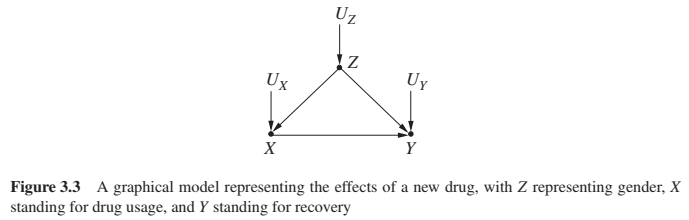

Once again, I find Theorem 4.3.2 a little hard to work with.  Instead, I think we need to go to Equation (4.21)--which we're entited to use because the backdoor criterion is met.

$$\begin{align}
\text{ETT} &= 𝔼[Y_{x'=1}|X=1] - 𝔼[Y_{x'=0}|X=1] \\
&= 𝔼[Y|X=1] - \sum_Y \sum_Z Y \times p(Y|X_{x'=0}, Z) \times p(Z|X=1) \\
&= \frac{81+192}{87+263} - \left(\sum_Y Y \times p(Y|X=0, Z=0) \times p(Z=0|X=1) - Y \times p(Y|X=0, Z=1) \times p(Z=1|X=1) \right) \\
&= \frac{273}{350} - [(1\times (p(Y=1|X=0, Z=0) \times p(Z=0|X=1) + p(Y=1|X=0, Z=1) \times p(Z=1|X=1)) + (0\times (p(Y=1|X=0, Z=0) \times p(Z=0|X=1) + p(Y=1|X=0, Z=1) \times p(Z=1|X=1))] \\
&= 0.78 - [(p(Y=1|X=0, Z=0) \times p(Z=0|X=1)) + (p(Y=1|X=0, Z=1) \times p(Z=1|X=1))] \\
&\approx 0.78 - \left[\left(\frac{55}{80} \times \frac{263}{350} \right) + \left(\frac{234}{270} \times \frac{87}{350} \right) \right] \\
&\approx 0.78 - [(0.69 \times 0.75) + (0.87 \times 0.25)] \\
&\approx 0.78 - [0.52 + 0.22] \\
&\approx 0.78 - 0.74 \\
&\approx 0.04 \\
\end{align}$$

which, after rounding errors, is approximately equal to the answer in part b.

## Example 4.4.2, Additive Interventions

In many experiments, the external manipulation consists of adding (or subtracting) some amount from a variable $X$ without disabling preexisting causes of $X$, as required by the $\text{do(x)}$ operator. For example, we might give 5 mg/l of insulin to a group of patients with varying levels of insulin already in their systems. Here, the preexisting causes of the manipulated variable continue to exert their influences, and a new quantity is added, allowing for differences among units to continue.

> **Can the effect of such interventions be predicted from observational studies, or from experimental studies in which $X$ was set uniformly to some predetermined value $x$?**

I'm imagining a DAG like this:

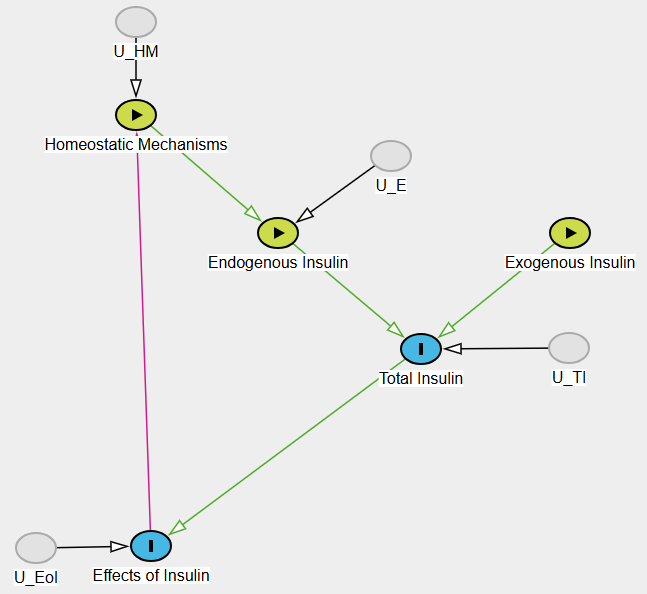

Only, this isn't a DAG because it isn't acyclic: there's a cycle on the left-hand side...so this should be interesting.  Notice that I've added to error terms to each node to ease my thinking in counterfactuals.

Next, I need to get my head aound what we're being asked to find...and why it requires counterfactuals.

This is a little unclear to me because I think we're asked to find the effect of the intervention (exogenous insulin) on some outcome (effects of insulin).  Then it's not clear to me why we can't simply find

$$𝔼[Y|\text{do}(Q=q)] - 𝔼[Y] = 𝔼[Y|Q=q] - 𝔼[Y]$$

where $Y$ is the outcome and $Q$ is the intervention.  After all, endogenous insulin will vary across individuals such that the average effect across individuals should center on the true value of the effect.

But the explanation goes on to say that we cannot use $\text{do}()$ expressions.  But since there are no backdoors between exogenous insulin and effects of insulin, I think we *can* use a $\text{do}()$ expression, as I already put forward: $𝔼[Y|\text{do}(Q=q)] - 𝔼[Y] = 𝔼[Y|Q=q] - 𝔼[Y]$.

So I suppose that if we looked at this in terms of total insulin, we actually want to find $𝔼[Y_{x'=x+q}|X=x] - 𝔼[Y_{x'=x}|X=x]$ across all values $X=x$:

$$\begin{align}
& \sum_X \left(𝔼[Y_{x'=x+q}|X=x] - 𝔼[Y_{x'=x}|X=x] \right) \times p(X=x) \\
&= \sum_X 𝔼[Y_{x'=x+q}|X=x] \times p(X=x) - 𝔼[Y_{x'=x}|X=x] \times p(X=x) \\
&= \sum_X 𝔼[Y_{x'=x+q}|X=x] \times p(X=x) - \sum_X 𝔼[Y_{x'=x}|X=x] \times p(X=x) \\
&= \sum_X 𝔼[Y_{x'=x+q}|X=x] \times p(X=x) - 𝔼[Y] \\
\end{align}$$

where $x$ is the baseline level of insulin and $x'$ is the amount of insulin in the hypothetical scenario (either with or without exogenous insulin).

The book goes on to say that we can expand this to

$$=\sum_X \sum_Z 𝔼[Y|X=x+q, Z=z] \times p(Z=z|X=x) \times p(X=x) - 𝔼[Y]$$

where $Z$ is some set of covariates that satisfy the backdoor criteria.  In our model, this might be measurable quantities like age, sex, etc. that are upstream of homeostatic mechanisms.

But why would we we *want* to look at this through the lense of total insulin rather than as strictly an intervention? counterfactuals versus interventions?

I think the book goes on to distinguish between a scientific-based interest in the question, which focuses on global effect of exogenous insulin, and a policy-based interest.  The claim is that enactment of a policy should consider $p(X)$, and hence apply counterfactuals.  I'm not sure if this is a fair assessment of scientific-based interest, but the point is that a policy *should* consider the people that will be affected by the policy.

## Question 4.4.2

Joe has never smoked before but, as a result of peer pressure and other personal factors, he decided to start smoking. He buys a pack of cigarettes, comes home, and asks himself: “I am about to start smoking, should I?”

> (a) Formulate Joe’s question mathematically, in terms of ETT, assuming that the outcome of interest is lung cancer.

> (b) What type of data would enable Joe to estimate his chances of getting cancer given that he goes ahead with the decision to smoke, versus refraining from smoking.

> (c) Use the data in Table 3.1 to estimate the chances associated with the decision in (b).

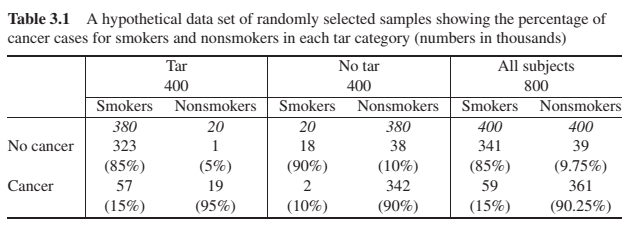

### Answer to Question 4.4.2, a

***Formulate Joe’s question mathematically, in terms of ETT, assuming that the outcome of interest is lung cancer.***

$$\begin{align}
\text{ETT} &= 𝔼[Y_{x'=1} | X=1] - 𝔼[Y_{x'=0} | X=1] \\
&= 𝔼[Y|X=1] - \frac{𝔼[Y|\text{do}(X=0)] - 𝔼[Y|X=0]p(X=0)}{p(X=1)} \\
\end{align}$$

Where
* $Y = \text{Cancer}$
* $X = \text{Smoking}$

### Answer to Question 4.4.2, b

***What type of data would enable Joe to estimate his chances of getting cancer given that he goes ahead with the decision to smoke, versus refraining from smoking.***

I'm not sure what is meant here, but we'd need data on the rate of cancer in both smokers and non-smokers; in addition, we could make better estimates if we additionally had this data across many values of relevant covariates (e.g., ages) on which we can condition on.

I think this question is trying to draw connections to the backdoor discussion in Question 4.4.1: if we can condition on covariates that block backdoors between $X$ and $Y$, then we can make this estimate.

### Answer to Question 4.4.2, c

***Use the data in Table 3.1 to estimate the chances associated with the decision in (b).***

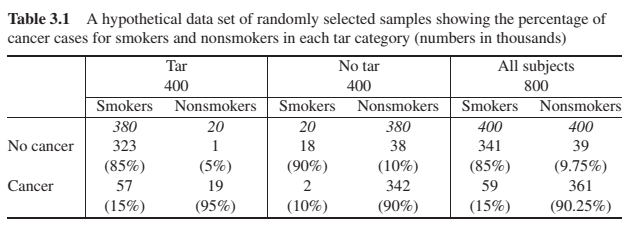

If we're going to use the data from Table 3.1, I think it's a good idea to ascribe a causal model to it.  Let's use Figure 3.10 (b).

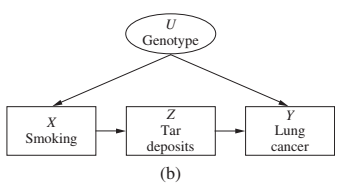

We are tasked with, I think, estimating the risk of lung cancer in those that smoke--that is, once again, the ETT.

$$\begin{align}
\text{ETT} &= 𝔼[Y_{x'=1}|X=1] - 𝔼[Y|_{x'=0}|X=1] \\
&= 𝔼[Y|X=1] - \frac{𝔼[Y|\text{do}(X=0)] - 𝔼[Y|X=0]p(X=0)}{p(X=1)} \\
\end{align}$$

Let's look at $𝔼[Y|\text{do}(X=0)]$ separately, then plug it back in.  For this, we need to apply the front-door adjustment.

$$\begin{align}
𝔼[Y|\text{do}(X=0)] &= \sum_Z p(Z=z)|X=0) \sum_X p(Y=1|X=x, Z=z) p(X=x) \\
&= \ \ \ \ \ \  p(Z=0|X=0) p(Y=1|X=0, Z=0)p(X=0) \\
& \ \ \ + \ \ \ p(Z=0|X=0) p(Y=1|X=1, Z=0)p(X=1) \\
& \ \ \ + \ \ \ p(Z=1|X=0) p(Y=1|X=0, Z=1)p(X=0) \\
& \ \ \ + \ \ \ p(Z=1|X=0) p(Y=1|X=1, Z=1)p(X=1) \\
&= \ \ \ \ \ \ p(Z=0|X=0) \times \left[p(Y=1|X=0, Z=0)p(X=0) + p(Y=1|X=1, Z=0)p(X=1) \right] \\
& \ \ \ + \ \ \ p(Z=1|X=0) \times \left[p(Y=1|X=0, Z=1)p(X=0) + p(Y=1|X=1, Z=1)p(X=1) \right] \\
& = \ \ \ \ \ \ \frac{380}{400} \left[0.90(0.50) + 0.10(0.50) \right] + \frac{20}{400} \left[0.95(0.50) + 0.15(0.50) \right] \\
&= 0.95[0.45 + 0.05] + 0.05[0.475 + 0.075] \\
&= 0.95[0.50] + 0.05[0.55] \\
&= 0.475 + 0.0275 \\
&= 0.5025 \\
\end{align}$$

Now we can plug this back into our initial equation for ETT.

$$\begin{align}
\text{ETT} &= 𝔼[Y_{x'=1}|X=1] - 𝔼[Y|_{x'=0}|X=1] \\
&= 𝔼[Y|X=1] - \frac{𝔼[Y|\text{do}(X=0)] - 𝔼[Y|X=0]p(X=0)}{p(X=1)} \\
&= 0.15 - \frac{0.5025 - 0.9025(0.50)}{0.50} \\
&= 0.0475 \\
\end{align}$$

Since $\text{ETT} > 0$, there is an increased risk of cancer if Joe starts smoking.

## Example 4.4.3, Personal Decision Making

Ms Jones, a cancer patient, is facing a tough decision between two possible treatments: (i) lumpectomy alone or (ii) lumpectomy plus irradiation. In consultation with her oncologist, she decides on (ii). Ten years later, Ms Jones is alive, and the tumor has not recurred. She speculates: Do I owe my life to irradiation?

Mrs Smith, on the other hand, had a lumpectomy alone, and her tumor recurred after a year. And she is regretting: I should have gone through irradiation.

> **Can these speculations ever be substantiated from statistical data?**

> **Moreover, what good would it do to confirm Ms Jones’s triumph or Mrs Smith’s regret?**

This example is just introducing a few cool concepts that are expanded on over the next few sections:

* **Probability of Necessity (PN)**: The probability that an event would NOT have occurred *if* a specified exposure did NOT occur, given that both the event and exposure DID occur.
$$PN = p(Y_{x'=0}=0 | X=1, Y=1)$$
> (I suspect that PN can be interpretted more broadly by conditioning on any arbitrary set of conditions $Z$, including $Y=y$: *The probability that an event would NOT have occurred if a specified exposure did NOT occur*.  I also suspect that the outcome may take on any particular value.
$$PN = p(Y_{x'}=y' | Z=z)$$
where $Z=z$ may include $X=x$ and/or $Y=y$.)

* **Probability of Sufficiency (PS)**: The probability that an event WOULD HAVE occured *if* a specified exposure DID occur, given that both the event and the exposure did NOT occur.
$$PS = p(Y_{x'=1}=1 | X=0, Y=0)$$
> (I suspect that PS can be interpretted more broadly by conditioning on any arbitrary set of conditions $Z$, including : *The probability that an event WOULD HAVE occured if a specified exposure DID occur*.  I also suspect that the outcome may take on any particular value.
$$PS = p(Y_{x'}=y' | Z=z)$$
where $Z=z$ may include $X=x$ and/or $Y=y$.)

* **Probability of Necessity and Sufficiency (PNS)**: The probability that an exposure is both necessary and sufficient for an outcome.
$$\begin{align}
PNS &= p(Y_{X=1}=1, Y_{X=0}=0) \\
\end{align}$$

## Example 4.4.4, Sex Discrimination in Hiring (should be "Sexual-Orientation Discrimination")

Mary files a law suit against the New York-based XYZ International, alleging discriminatory hiring practices. According to her, she has applied for a job with XYZ International, and she has all the credentials for the job, yet she was not hired, allegedly because she mentioned, during the course of her interview, that she is gay. Moreover, she claims, the hiring record of XYZ International shows consistent preferences for straight employees.

**Does she have a case?  Can hiring records prove whether XYZ International was discriminating when declining her job application?**



This example just expands on the PS presented in the previous example.  Here, we're being asked about the probability of a person being hired $Y=1$ if were straight $X=1$, given that they were not hired $Y=0$ and are (preceived as) gay $X=0$.

$$PS = p(Y_{x'=1}=1 | X=0, Y=0)$$

## Example 4.4.5 Mediation and Path-disabling Interventions

A policy maker wishes to assess the extent to which gender disparity in hiring can be reduced by making hiring decisions gender-blind, rather than eliminating gender inequality in education or job training.

Like the previous example, this example is merely introducing some concepts that are followed-up in subsequent sections.  Here, the concept is the "natural indirect effect" (NIE).  Roughly stated, the NIE is the effect of some variable $X$ on outcome $Y$ when the causal variable $Q$ is held constant at $Q=q$, where $Q$ is examined for all values $q$.

Unfortunately, the necessary concepts for this are not fully presented until section 4.5.  But I think we can get an intuition here.  Let's start by drawing a DAG.



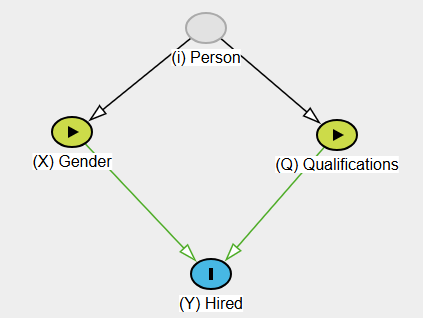

The idea is that we are interested in the effect of gender ($X$) on hiring ($Y$).  What would be some (probably) **bad** options to assess this?

1. **Looking at the overall numbers of males and females that are hired.**  ***Why?***  Because males and females may apply in different numbers.  If 100 males apply for every female, we should expect more males to be hired than females.
2. **Comparing the ratio of males:females that apply compared to the ratio of males:females that have been hired.** ***Why?*** Because the males and females that apply may have systematically different levels of qualifications.  For example, one position opens up for which 50 males and 50 females apply.  Presumably, the company wishes to hire the most qualified applicant.  Even if males and females have the same average level of qualification, if the most extreme outliers tend to be females, then females will be hired disproportionately.

Now, determining if discirmination is taking place is tricky; of course a company accused of discrimination can always *claim* some version of 2.  So to get to the bottom of it, we want to run an experiment.

Imagine creating 100 resumes of varying qualification levels.  We submit each resume twice: once where gender is marked as male and once where gender is marked as female.  Since the only thing different between submissions is gender, differences in the number of hired applicants can be ascribed to gender (and therefore, gender discrimination).

Alternatively, we could try to *simulate* this experiment.  That's what is happening in this example.  We are simulating the expected hiring decisions for the same set of qualifications when gender changes.  How do we do this?

First, we need the expected number of male and female applicants to be hired *if sex was not a factor in the hiring decisions*.  This is the product of two terms: the average hiring decision for a person of $\text{gender} = x'$ and $\text{qualifications} = q'$ ($𝔼[Y_{X=x', Q=q'}]$) and the probability of $\text{qualifications} = q'$ given $\text{gender} = x'$ ($p(Q=q'|X=x')$).  We need this for both genders.  Then, since we're trying to ignore qualifications, we marginalize it out by summing over all $Q=q'$.  The final expression looks like:

$$\begin{align}
\text{NIE} &= \sum_{q'} 𝔼[Y_{X=x'_1, Q=q'}] \ \times p(Q=q'|X=x'_0) - \sum_{q'} 𝔼[Y_{X=x'_1, Q=q'}] \ \times p(Q=q'|X=x'_1) \\
&= \sum_{q'} 𝔼[Y_{X=x'_1, Q=q'}] \ \times [p(Q=q'|X=x'_0) - p(Q=q'|X=x'_1)] \\
&= \sum_{q'} 𝔼[Y|X=x'_1, Q=q'] \ \times \left[p(Q=q'|X=x'_0) - p(Q=q'|X=x'_1) \right] \\
\end{align}$$

where the final expression is only permitted when there is no confounding.

In this example, we're interested in the effect of $X = \text{gender}$, and so we compare $X = x_0 = \text{female}$ versus $X = x_1 \text{male}$, averaging over the female and male distributions for qualifications $Q$.  We are basically asking "What if women retained all of their attributes they would bring to bear for a job, but the hiring company believed they were men?".

We use counterfactuals because, well, we are building a counterfactual ("What if employers thought these women were men?").

## Example 4.5.1, Attribution in Legal Setting

A lawsuit is filed against the manufacturer of drug $x$, charging that the drug is likely to have caused the death of Mr A, who took it to relieve back pains. The manufacturer claims that experimental data on patients with back pains show conclusively that drug $x$ has only minor effects on death rates. However, the plaintiff argues that the experimental study is of little relevance to this case because it represents average effects on patients in the study, not on patients like Mr A who did not participate in the study. In particular, argues the plaintiff, Mr A is unique in that he used the drug of his own volition, unlike subjects in the experimental study, who took the drug to comply with experimental protocols. To support this argument, the plaintiff furnishes nonexperimental data on patients who, like Mr A, chose drug $x$ to relieve back pains but were not part of any experiment, and who experienced higher death rates than those who didn’t take the drug. **The court must now decide, based on both the experimental and nonexperimental studies, whether it is “more probable than not” that drug $x$ was in fact the cause of Mr A’s death.**

To illustrate the usefulness of the bounds in Eq. (4.30), consider hypothetical data associated with two studies, shown in Table 4.5.  (In the analysis below, we ignore sampling variability.)

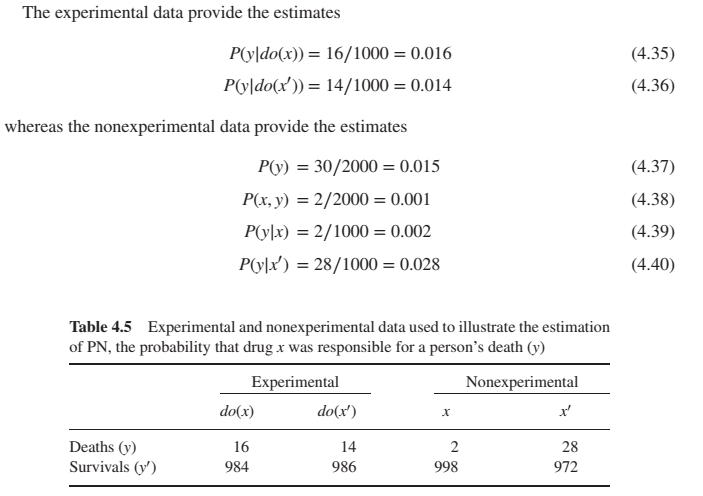

This question is asking about the probability of necessity ($\text{PN}$); we saw this in Example 4.4.3:

> **Probability of Necessity (PN)**: The probability that an event would NOT have occurred *if* a specified exposure did NOT occur, given that both the event and exposure DID occur.
> $$PN = p(Y_{x'=0}=0 | X=1, Y=1)$$

As applied here, we're asked how probable it is that the drug was necessary in the death of Mr A.  In other words: *What is the probability that Mr A would NOT have died $Y=0$ if he had not received the drug $x'=0$, given that Mr A DID die $Y=1$ and took the drug $X=1$?*  

Let's try to figure this out with the tools we already have.  I'm going to start by drawing a DAG.

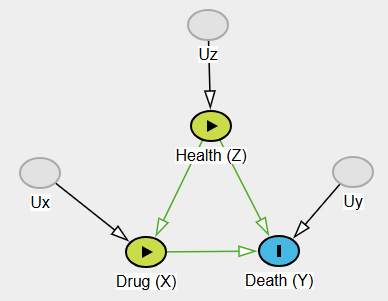

In the experimental study, the researchers (presumably) blocked the $X \leftarrow Z \rightarrow Y$ backdoor by randomizing on receipt of the drug.  In an observational study, we'd block that backdoor by conditioning on $Z$.

The defense lawyer is marshalling the experimental evidence which shows that the drug has little effect on death.

But Mr A's lawyer is arguing that Mr A was not like the experimental subjects; that rather than having been *assigned* the drug, Mr A *chose* to take the drug such that the biasing backdoor path remained open.  Hence, the plantiff argues that the defense's arguement is invalid and the drug manufacturer was negligent by making this drug available to Mr A (or perhaps by not making clear how Mr A's $Z$-status may affect his response).

### A surprising connection to $\text{ETT}$

We want to find the the difference in the probability of dying with and without the drug.  This kinda sounds like the $\text{ETT}$, except we additionally condition on $Y=1$.

$$\begin{align}
\text{PN} &= 𝔼[Y_{x'=1} | X=1, Y=1] - 𝔼[Y_{x'=0} | X=1, Y=1] \\
&= 1 - (0 \times p(Y_{x'=0}=0|X=1, Y=1) + 1 \times p(Y_{x'=0}=1|X=1, Y=1) \\
&= 1 - p(Y_{x'=0}=1|X=1, Y=1) \\
&= 1 - (1 - p(Y_{x'=0}=0|X=1, Y=1)) \\
&= 1 - (1 - \text{PN}) \\
&= 1 - 1 + \text{PN} \\
&= \text{PN} \\
\end{align}$$

Interesting...using the same framework as we did for $\text{ETT}$, but additionally conditioning on the outcome $Y=1$, we get the $\text{PN}$.

### Towards deriving an expression for $\text{PN}$

Let's go back to the expression we're provided with for PN.

$$PN = p(Y_{x'=0}=0 | X=1, Y=1)$$

Even though we've primarily focused on variables $X$ and $Y$, don't forget that we also have $Z$.  We can write a more general version of $\text{PN}$ that accounts for $Z$:

$$\text{PN}_{X,Y,Z} = p(Y_{x'=0}=0 | X=1, Y=1, Z=z)$$

We get back our simple $X, Y$ version by marginalizing over $Z$.

$$\text{PN}_{X,Y} = \sum_Z{p(Y_{x'=0}=0 | X=1, Y=1, Z=z) p(Z=z|X=1, Y=1)}$$

Anyway, we need to derive a usable expression for PN; the problem with what we have now, $PN = p(Y_{x'=0}=0 | X=1, Y=1)$, is that we want to know $Y_{x'=0}=0$ when all we have is $X=1, Y=1$.

We can't use the same counterfactual-analysis methods we used previously, at least not directly, because those are used on 𝔼xpectations but we have a probability.  So we need a different approach.

#### Delineating the possibilities

Let's start by taking a step back.  Roughly, we want to know the probabilities of drug outcomes.  A little more accurately, we want to know what will happen to *specific* people when they take the drug.  We can identify 4 types of specific people:

|Type|$Y_1$|$Y_0$|Name      |
|----|-----|-----|----------|
|A   |1    |1    |**Always** Dies, regardless of drug|
|C   |1    |0    |Drug **Causes** Death|
|N   |0    |0    |**Never** Dies, regardless of drug|
|P   |0    |1    |Drug **Prevents** Death|

These types of people exist in proportions of populations defined by $Z=z$:
* $p_A(z)$
* $p_C(z)$
* $p_N(z)$
* $p_P(z)$

where
$$p_A(z) + p_C(z) + p_N(z) + p_P(z) = 1$$

We can combine all $z$-defined populations into the total population by marginalizing over $z$
$$p_{T} = \sum_Z{p_{T}(z) \times p(Z=z)}$$
such that
$$p_A + p_C + p_N + p_P = 1$$

Further, we assume that a person's drug-responder type is conditionally independent of $X$: $\{A, C, N, P\} \perp X | Z$

But here's the rub: **We do NOT know these values.**  Why? Because they all rely on both giving- and not giving the drug to everybody to see how they respond.  For instance, for the problem at hand, we observed that Mr A died after taking the drug, but we don't know if he would've died anyway ($p_A$) or if the drug caused him to die ($p_C$).  So was Mr A a $p_A$ or a $p_C$?

In order to answer this, we'll need to build an expression for $\text{PN}$.  Be prepared because this is a bit of a lengthy process.

##### Building-block probabilities

Let's start by listing some basic generic probabilities that may be helpful:

$\textbf{Joint probability: } p(Y=y,X=x) = \sum_Z{p(Y=y|X=x, Z=z) p(X=x|Z=z) p(Z=z)}$

$\begin{align}
\textbf{Conditional probability: } p(Y=y|X=x) &= \frac{p(Y=y, X=x)}{p(X=x)} \\
&= \sum_Z{\frac{p(Y=y|X=x, Z=z) p(X=x|Z=z) p(Z=z)}{p(X=x)}} \\
&= \sum_Z{\frac{p(Y=y|X=x, Z=z) p(Z=z|X=x) p(X=x)}{p(X=x)}} \\
&= \sum_Z{p(Y=y|X=x, Z=z) p(Z=z|X=x)} \\
\end{align}$

$\textbf{Interventional probability: } p(Y=y|\text{do}(X=x')) = \sum_Z p(Y=y|X=x', Z=z) p(Z=z)$

$\textbf{Marginal probability for X: } p(X=x) = \sum_Z{p(X=x|Z=z)p(Z=z)}$

$\textbf{Marginal probability for Y: } p(Y=y) = \sum_Z{\sum_X{p(Y=y|X=x, Z=z) p(X=x|Z=z) p(Z=z)}}$

We can express these differently by incorporating the $p_T$ terms given above.  I'll derive a few, for $X=1, Y=1$, and put the rest in a table.

$\begin{align}
\textbf{Marginal probability for Y: } p(Y=1) &= \sum_Z{\sum_X{p(Y=1|X=x, Z=z) p(X=x|Z=z) p(Z=z)}} \\
&= \sum_Z{p(Y=1|X=0, Z=z) p(X=0|Z=z) p(Z=z) + p(Y=1|X=1, Z=z) p(X=1|Z=z) p(Z=z)}\\
&= \sum_Z{[p(Y=1|X=0, Z=z) p(X=0|Z=z) + p(Y=1|X=1, Z=z) p(X=1|Z=z)] \times p(Z=z)}\\
&= \sum_Z{[(p_A(z) + p_P(z))p(X=0|Z=z) + (p_A(z) + p_C(z))p(X=1|Z=z)] \times p(Z=z)} \\
\end{align}$


$\begin{align}
\textbf{Joint probability: } p(Y=1, X=1) &= \sum_Z{p(Y=1|X=1, Z=z)p(X=1|Z=z)p(Z=z)} \\
&= \sum_Z{(p_A(z) + p_C(z)) p(X=1|Z=z) p(Z=z)} \\
\end{align}$


$\begin{align}
\textbf{Conditional probability: } p(Y=1|X=1) &= \sum_Z{p(Y=1|X=1, Z=z) p(Z=z|X=1)} \\
&= \sum_Z{(p_A(z) + p_C(z))p(Z=z|X=1)} \\
\end{align}$


$\begin{align}
\textbf{Interventinoal probability: } p(Y=1|\text{do}(X=1)) &= \sum_Z{p(Y=1|X=1, Z=z) p(Z=z)} \\
&= \sum_Z{(p_A(z) + p_C(z)) p(Z=z)}
\end{align}$

| **X value / probability type** | $Y = 0$ | $Y = 1$ |
|--------------------------------|---------|---------|
| $p(Y)$ | $\sum_Z[(p_C(z)+p_N(z))\,p(X=0|Z=z)\;+\;(p_N(z)+p_P(z))\,p(X=1| Z=z)]\;p(Z=z)$ | $\sum_Z[(p_A(z)+p_P(z))\,p(X=0|Z=z)\;+\;(p_A(z)+p_C(z))\,p(X=1| Z=z)\big]\;p(Z=z)$ |
| **$X = 0$** | | |
| $P(Y,X=0)$ | $\sum_Z(p_C(z)+p_N(z))\,p(X=0|Z=z)\;p(Z=z)$ | $\sum_Z(p_A(z)+p_P(z))\,p(X=0|Z=z)\;p(Z=z)$ |
| $P(Y|X=0)$ | $\sum_Z(p_C(z)+p_N(z))\,p(Z=z|X=0)$ | $\sum_Z(p_A(z)+p_P(z))\,p(Z=z|X=0)$ |
| $P(Y|\text{do}(X=0))$ | $\sum_Z(p_C(z)+p_N(z))\,p(Z=z)$ | $\sum_Z(p_A(z)+p_P(z))\,p(Z=z)$ |
| **$X = 1$** | | |
| $P(Y,X=1)$ | $\sum_Z(p_N(z)+p_P(z))\,p(X=1|Z=z)\;p(Z=z)$ | $\sum_Z(p_A(z)+p_C(z))\,p(X=1|Z=z)\;p(Z=z)$ |
| $P(Y|X=1)$ | $\sum_Z(p_N(z)+p_P(z))\,p(Z=z|X=1)$ | $\sum_Z(p_A(z)+p_C(z))\,p(Z=z|X=1)$ |
| $P(Y|\text{do}(X=1))$ | $\sum_Z(p_N(z)+p_P(z))\,p(Z=z)$ | $\sum_Z(p_A(z)+p_C(z))\,p(Z=z)$ |


#### An expression for $\text{PN}$ using the possible outcomes

With all of this, let's try to work towards an expression for $\text{PN}$.  In terms of our available probabilities, we can write this as

$$\text{PN} = p(Y_{x'=0}=0|X=1, Y=1) = \sum_Z{\frac{p_C(z)}{p_A(z) + p_C(z)}}p(Z=z) = \frac{p_C}{p_A + p_C}$$

In words, this means:
> *Of those that might take the drug and die, only in those that would not die without the drug can we say the drug was necessary to cause their death.*

#### The challenge in deriving a usable form of $\text{PN}$

Recall that we do not know the values of $p_A, p_C$.  So we're confronted with trying to derive this expression from our table of probabilities.

Normally, we'd do this with a system of equations; here, the equations of that system would come from our table.  Those equations would need to cover at least $p_A$ and $p_C$, and also represent both values of $X \in \{0, 1 \}$ (or else, we couldn't contrast the drug-vs-no-drug conditions).

Try it.  Let's pick two equations that satisfy these terms.

$$p(Y=1|\text{do}(X=1)) = \sum_Z{(p_A(z) + p_C(z))p(Z=z)}$$
$$p(Y=1|\text{do}(X=0)) = \sum_Z{(p_A(z) + p_P(z))p(Z=z)}$$

We can't get a solution here because we have 3 unknowns ($p_A(z), p_C(z), p_P(z)$) but only 2 equations.  

If we bring in a third equation,

$$p(Y=0|\text{do}(X=1)) = \sum_Z{(p_N(z) + p_P(z))p(Z=z)}$$

we get the same problem.  Here, we've added an equation but also added a fourth unknown.

"AHA!" you say, "Just add the equation $p(Y=0|\text{do}(X=0)) = \sum_Z{(p_C(z) + p_P(z))p(Z=z)}$; then, we have 4 equations and 4 unknowns!"

But no.  The problem is that these 4 equations are not independent (in fact, no 3 of these equations are independent).  In other words, the final two equations don't add any information to the first two equations because, for example, $p(Y=0|\text{do}(X=1))$ is just the obverse of $p(Y=1|\text{do}(X=1))$.

Unfortunately, every system that includes the terms we need to estimate ($p_A$ and $p_C$) will have more unknowns ($p_T$ terms) than equations.

Due to this limitation, the best we can do is find some boundaries for $\text{PN}$.

So let's take as our system of equations:
$$p(Y=1|\text{do}(X=1)) = \sum_Z{(p_A(z) + p_C(z))p(Z=z)}$$
$$p(Y=1|\text{do}(X=0)) = \sum_Z{(p_A(z) + p_P(z))p(Z=z)}$$
where we are trying to get an expression for
$$\text{PN} = p(Y_{x'=0}=0|X=1, Y=1) = \sum_Z{\frac{p_C(z)}{p_A(z) + p_C(z)}}p(Z=z) = \frac{p_C}{p_A + p_C}$$

First, let's get an expression for $p_A$:

$\begin{align}
p(Y=1|\text{do}(X=0)) &= \sum_Z{(p_A(z) + p_P(z))p(Z=z)} \\
&= \sum_Z{p_A(z)p(Z=z)} + \sum_Z{p_P(z)p(Z=z)} \\
&= p_A + p_P \\
\rightarrow p_A = p(Y=1|\text{do}(X=0)) - p_P \\
\end{align}$

\

Now, an expression for $p_C$:

$\begin{align}
p(Y=1|\text{do}(X=1)) &= \sum_Z{(p_A(z) + p_P(z))p(Z=z)} \\
&= \sum_Z{p_A(z)p(Z=z)} + \sum_Z{p_C(z)p(Z=z)} \\
&= p_A + p_C \\
&= p(Y=1|\text{do}(X=0)) - p_P + p_C \\
\rightarrow p_C = p(Y=1|\text{do}(X=1)) - p(Y=1|\text{do}(X=0)) + p_P
\end{align}$

\

And finally, plug these into our expression for $\text{PN}$:
$$\begin{align}
\text{PN} &= \frac{p_C}{p_A + p_C} \\
\
\
\
&= \frac{p(Y=1|\text{do}(X=1)) - p(Y=1|\text{do}(X=0)) + p_P}{(p(Y=1|\text{do}(X=0)) - p_P) + (p(Y=1|\text{do}(X=1)) - p(Y=1|\text{do}(X=0)) + p_P)} \\
\
\
\
&= \frac{p(Y=1|\text{do}(X=1)) - p(Y=1|\text{do}(X=0)) + p_P}{p(Y=1|\text{do}(X=0)) - p_P + p(Y=1|\text{do}(X=1)) - p(Y=1|\text{do}(X=0)) + p_P} \\
\
\
\
&= \frac{p(Y=1|\text{do}(X=1)) - p(Y=1|\text{do}(X=0)) + p_P}{p(Y=1|\text{do}(X=1))} \\
\end{align}$$

#### Why (and how) we get bounds for $\text{PN}$

We almost have a usable expression, except for that pesky $p_P$, for which we don't have an estimate.  But we can least bound it.  We know the $\text{PN}$ is a probability, and therefore bound $0 \le \text{PN} \le 1$.

>$\begin{align}
0 &\le \frac{p(Y=1|\text{do}(X=1)) - p(Y=1|\text{do}(X=0)) + p_P}{p(Y=1|\text{do}(X=1))} \le 1 \\
0 &\le p(Y=1|\text{do}(X=1)) - p(Y=1|\text{do}(X=0)) + p_P \le p(Y=1|\text{do}(X=1)) \\
p(Y=1|\text{do}(X=0)) - p(Y=1|\text{do}(X=1)) &\le p_P \le p(Y=1|\text{do}(X=0)) \\
\end{align}$

And since $p_P$ is also a probability, bound between 0 and 1, we add this to our constraints from above to get
$$\max[0, p(Y=1|\text{do}(X=0)) - p(Y=1|\text{do}(X=1))] \le p_P \le p(Y=1|\text{do}(X=0))$$

\

There's one more constraint we need to consider: $0 \le p_N \le 1$.  Since $p_N = 1 - p(Y=1|\text{do}(X=1)) - p_P$, we get that
$\begin{align}
0 &\le 1 - p(Y=1|\text{do}(X=1)) - p_P \le 1 \\
p(Y=1|\text{do}(X=1)) - 1 &\le -p_P \le p(Y=1|\text{do}(X=1)) \\
1 - p(Y=1|\text{do}(X=1)) &\ge p_P \ge - p(Y=1|\text{do}(X=1)) \\
p_P &\le 1 - p(Y=1|\text{do}(X=1)) \\
\end{align}$

So,
$$\begin{align}
\min[p_P] &= \max[0, p(Y=1|\text{do}(X=0)) - p(Y=1|\text{do}(X=1))] \\
&\le p_P \le \\
\max[p_P] &= \min[p(Y=1|\text{do}(X=0)), 1 - p(Y=1|\text{do}(X=1))]
\end{align}$$

We now use this to add to our inequality $0 \le \text{PN} \le 1$.

$$\begin{align}
\min[\text{PN}] &= \max\left[0, \frac{p(Y=1|\text{do}(X=1)) - p(Y=1|\text{do}(X=0)) + \min[p_P]}{p(Y=1|\text{do}(X=1))}\right] \\
&\le \text{PN} \le  \\
\max[\text{PN}] &= \min\left[1, \frac{p(Y=1|\text{do}(X=1)) - p(Y=1|\text{do}(X=0)) + \max[p_P]}{p(Y=1|\text{do}(X=1))}\right] \\
\end{align}$$

\

These are the bounds for $\text{PN}$.

Notice that if $p(Y=1|\text{do}(X=1)) \ge p(Y=1|\text{do}(X=0)$, then $\min[p_P] = 0$ such that $\min[\text{PN}] = \frac{p(Y=1|\text{do}(X=1)) - p(Y=1|\text{do}(X=0))}{p(Y=1|\text{do}(X=1))}$.

Conversely, if $p(Y=1|\text{do}(X=1)) < p(Y=1|\text{do}(X=0)$, then $\min[p_P] = p(Y=1|\text{do}(X=0)) - p(Y=1|\text{do}(X=1))$ such that $\min[\text{PN}] = \frac{p(Y=1|\text{do}(X=1)) - p(Y=1|\text{do}(X=0)) + p(Y=1|\text{do}(X=0)) - p(Y=1|\text{do}(X=1))}{p(Y=1|\text{do}(X=1))} = 0$.

So we can rewrite
$$\min[\text{PN}] = \max\left[0, \frac{p(Y=1|\text{do}(X=1)) - p(Y=1|\text{do}(X=0))}{p(Y=1|\text{do}(X=1))}\right]$$

Similarly, if $p(Y=1|\text{do}(X=0)) \le 1 - p(Y=1|\text{do}(X=1))$, then $\max[p_P] = p(Y=1|\text{do}(X=0))$ such that $\max[\text{PN}] = \frac{p(Y=1|\text{do}(X=1))}{p(Y=1|\text{do}(X=1))} = 1$.

Conversely, if $p(Y=1|\text{do}(X=0)) > 1 - p(Y=1|\text{do}(X=1))$, then $\max[p_P] = 1 - p(Y=1|\text{do}(X=1))$ such that $\max[\text{PN}] = \frac{p(Y=1|\text{do}(X=1)) - p(Y=1|\text{do}(X=0)) + 1 - p(Y=1|\text{do}(X=1))}{p(Y=1|\text{do}(X=1))} = \frac{1-p(Y=1|\text{do}(X=0))}{p(Y=1|\text{do}(X=1))}$.

SO we can rewrite
$$\max[\text{PN}] = \min\left[1, \frac{1-p(Y=1|\text{do}(X=0))}{p(Y=1|\text{do}(X=1))}\right]$$

Taken together, we can rewrite our bounds for $\text{PN}$:

$$\begin{align}
\min[\text{PN}] &= \max\left[0, \frac{p(Y=1|\text{do}(X=1)) - p(Y=1|\text{do}(X=0))}{p(Y=1|\text{do}(X=1))}\right] \\
&\le \text{PN} \le  \\
\max[\text{PN}] &= \min\left[1, \frac{1-p(Y=1|\text{do}(X=0))}{p(Y=1|\text{do}(X=1))}\right] \\
\end{align}$$

If we take from earlier
$$\begin{align}
p(Y=1|\text{do}(X=1)) &= \sum_Z{(p_A(z) + p_C(z)) p(Z=z)} \\
&= p_A + p_C \\
\end{align}$$

and
$$\begin{align}
p(Y=1, X=1) &= \sum_Z{p(Y=1|X=1, Z=z) p(X=1|Z=z) p(Z=z)} \\
&= \sum_Z{(p_A(z) + p_C(z)) p(Z=z) p(X=1|Z=z)} \\
&= p(Y=1|\text{do}(X=1)) \sum_Z{p(X=1|Z=z)} \\
&= p(Y=1|\text{do}(X=1)) p(X=1) \\
\end{align}$$

then we can rewrite our bounds for $\text{PN}$.  To get the version in the book requires that frustrating type of silly algebra that feels unmotivated and undirected, and would only come about by playing with it.  So I'll just cut to the chase

$$\begin{align}
\min[\text{PN}] &= \max\left[0, \frac{p(Y=1|\text{do}(X=1)) - p(Y=1|\text{do}(X=0))}{p(Y=1|\text{do}(X=1))}\right] \\
&\le \text{PN} \le  \\
\max[\text{PN}] &= \min\left[1, \frac{1-p(Y=1|\text{do}(X=0))}{p(Y=1|\text{do}(X=1))}\right] \\
\end{align}$$

\

$$\begin{align}
= \min[\text{PN}] &= \max\left[0, \frac{p(Y=1) - p(Y=1|\text{do}(X=0))}{p(Y=1, X=1)}\right] \\
&\le \text{PN} \le  \\
\max[\text{PN}] &= \min\left[1, \frac{p(Y=0|\text{do}(X=0)) - p(Y=0, X=0)}{p(Y=1, X=1)}\right] \\
\end{align}$$

##### Using the monotonicity assumption to get a single value for $\text{PN}$

That was a lot of trouble.  But consider what happens if we assign a value to $p_P$.  It no longer has a range, which means that $\text{PN}$ also no longer has a range.  Specifically, if we assign $p_P = 0$ (that is, the drug can never prevent death), then we get:

$$\text{PN} = \frac{p(Y=1|\text{do}(X=1)) - p(Y=1|\text{do}(X=0))}{p(Y=1|\text{do}(X=1))}$$

This IS the "monotonicity" assumption the book talks about.

Pulling the same algebraic tricks we used to get the book's version of the bounds, we can rewrite this as

$$\text{PN} = \frac{p(Y=1) - p(Y=1|\text{do}(X=0))}{p(Y=1, X=1)}$$

#### Breaking down the expression for $\text{PN}$

Taking our cue again from the book, let's show that ***if the relation between $X$ and $Y$ is such that $Y$ always increases or always decreases with increasing values of $X$ (we call this "monotonicity", as in monotonous...unchanging) for all cases, then $\text{PN}$ is identifiable whenever $p(Y|\text{do}(X))$ is identifiable:***

$$\begin{align}
\text{PN} &= \frac{p(Y=y) - p(Y=y|\text{do}(X=x'))}{p(X \not = x', Y=y)} \\
&= \frac{[p(Y=y|X=x')p(X=x') + p(Y=y|X \not = x')p(X \not = x')] - p(Y=y|\text{do}(X=x'))}{p(X \not = x', Y=y)} \\
&= \frac{[p(Y=y|X=x')(1-p(X \not= x')) + p(Y=y|X \not = x')p(X \not = x')] - p(Y=y|\text{do}(X=x'))}{p(X \not = x', Y=y)} \\
&= \frac{[p(Y=y|X=x')-p(Y=y|X=x')p(X \not= x')) + p(Y=y|X \not = x')p(X \not = x')] - p(Y=y|\text{do}(X=x'))}{p(X \not = x', Y=y)} \\
&= \frac{[p(Y=y|X \not = x')p(X \not = x') - p(Y=y|X=x')p(X \not= x')) + p(Y=y|X=x')] - p(Y=y|\text{do}(X=x'))}{p(X \not = x', Y=y)} \\
&= \frac{(p(Y=y|X \not = x') - p(Y=y|X=x')) \times p(X \not= x') }{p(X \not = x', Y=y)} + \frac{p(Y=y|X=x') - p(Y=y|\text{do}(X=x'))}{p(X \not = x', Y=y)} \\
&= \frac{(p(Y=y|X \not = x') - p(Y=y|X=x')) \times p(X \not= x')}{p(Y=y|X \not= x')p(X \not = x')} + \frac{p(Y=y|X=x') - p(Y=y|\text{do}(X=x'))}{p(X \not = x', Y=y)} \\
&= \frac{p(Y=y|X \not = x') - p(Y=y|X=x')}{p(Y=y|X \not= x')} + \frac{p(Y=y|X=x') - p(Y=y|\text{do}(X=x'))}{p(X \not = x', Y=y)} \\
&= \text{Excess Risk Ratio } + \text{ Confounding Factor} \\
&= \text{ERR } + \text{ CF} \\
\end{align}$$

### Finally, the answer to the question

So, what is the answer to our question?  *Was the drug necessary for the death of Mr A (assuming monotonicity)?*

$$\begin{align}
\text{PN} &= \frac{p(Y=1|X=0) - p(Y=1|X=1)}{p(Y=1|X=0)} + \frac{p(Y=1|X=1) - p(Y=1|\text{do}(X=1))}{p(Y=1, X=0)} \\
&= \frac{0.002 - 0.028}{0.002} + \frac{0.028 - 0.014}{0.001} \\
&= \frac{-0.026}{0.002} + \frac{0.014}{0.001} \\
&= -13 + 14 \\
&= 1\\
\end{align}$$

### Going deeper onto $\text{PS}$ and $\text{PNS}$

We've offically answered the question about $\text{PN}$.  Along the way, we've hopefully understood some of the logic behind finding it.  Let's apply the same ideas to the probability of sufficiency ($\text{PS}$) and the probability of necessity and sufficiency ($\text{PNS}$).

#### PS

Recall that $PS = p(Y_{x'=1}=1 | X=0, Y=0)$ (I'm ignoring $Z$ now since we've seen that it gets marginalized out).  In words, this says:
> *Of those that might not have taken the drug and not die, we could say the drug is sufficient to cause their death in cases where they took the drug and died.*

$$\text{PS} = \frac{p_C}{p_C + p_N}$$

Let's select some appropriate probabilities from our table above to derive a usable expression for this.

$$\begin{align}
p(Y=0|\text{do}(X=0)) = p_C + p_N;\ p(Y=0|\text{do}(X=1)) = p_N + p_P \\
\rightarrow p_N = p(Y=0|\text{do}(X=1)) - p_P \\
\rightarrow p_C =  p(Y=0|\text{do}(X=0)) - p(Y=0|\text{do}(X=1)) + p_P \\
\end{align}$$

\

$$\begin{align}
\rightarrow \text{PS} &= \frac{p(Y=0|\text{do}(X=0)) - p(Y=0|\text{do}(X=1)) + p_P}{p(Y=0|\text{do}(X=0)) - p(Y=0|\text{do}(X=1)) + p_P + p(Y=0|\text{do}(X=1)) - p_P} \\
&= \frac{p(Y=0|\text{do}(X=0)) - p(Y=0|\text{do}(X=1)) + p_P}{p(Y=0|\text{do}(X=0))}
\end{align}$$

We've already found the bounds for $p_P$:

$$\begin{align}
\min[p_P] &= \max[0, p(Y=1|\text{do}(X=0)) - p(Y=1|\text{do}(X=1))] \\
&\le p_P \le \\
\max[p_P] &= \min[p(Y=1|\text{do}(X=0)), 1 - p(Y=1|\text{do}(X=1))]
\end{align}$$

and we can use these to add to our the inequality $0 \le PS \le 1$:

$$\begin{align}
\min[\text{PS}] &= \max\left[0, \frac{p(Y=0|\text{do}(X=0)) - p(Y=0|\text{do}(X=1)) + \min[p_P]}{p(Y=0|\text{do}(X=0))}\right] \\
&\le \text{PS} \le  \\
\max[\text{PS}] &= \min\left[1, \frac{p(Y=0|\text{do}(X=0)) - p(Y=0|\text{do}(X=1)) + \max[p_P]}{p(Y=0|\text{do}(X=0))}\right] \\
\end{align}$$

Once again, if we set $p_P := 0$ as per the monotonicity assumption, we get

$$\text{PS} = \frac{p(Y=0|\text{do}(X=0)) - p(Y=0|\text{do}(X=1))}{p(Y=0|\text{do}(X=0))}$$

#### PNS

Finally, we'll look at the probability of necessity and sufficiency (PNS):

$$\begin{align}
\text{PNS} &= p(Y_{X=1}=1, Y_{X=0}=0) \\
&= p_C \\
\end{align}$$

> *Those for whom taking the drug would cause death.  Those for whom taking the drug results in death while not taking the drug results in survival.*

Let us again select some probabiltiy expressions:

$$\begin{align}
p(Y=1|X=1) = p_A + p_C; \ p(Y=1|X=0) = p_A + p_P \\
\rightarrow p_A = p(Y=1|X=0) - p_P \\
\rightarrow p_C = p(Y=1|X=1) - p(Y=1|X=0) + p_P = \text{PNS}
\end{align}$$

Again, we can only bound $p_P$ (above) such that we get bounds for $\text{PNS}$:

$$\begin{align}
\min[\text{PNS}] &= \max\left[0, p(Y=1|X=1) - p(Y=1|X=0) + \min[p_P] \right] \\
&\le \text{PNS} \le  \\
\max[\text{PNS}] &= \min\left[1, p(Y=1|X=1) - p(Y=1|X=0) + \max[p_P] \right] \\
\end{align}$$

Assuming $p_P := 0$, we get the expression:

$$\text{PNS} = p(Y=1|X=1) - p(Y=1|X=0)$$

## Question 4.5.1

Consider the dilemma faced by Ms Jones, as described in Example 4.4.3.

> *Ms Jones, a cancer patient, is facing a tough decision between two possible treatments: (i) lumpectomy alone or (ii) lumpectomy plus irradiation. In consultation with her oncologist, she decides on (ii). Ten years later, Ms Jones is alive, and the tumor has not recurred. She speculates: Do I owe my life to irradiation? Mrs Smith, on the other hand, had a lumpectomy alone, and her tumor recurred after a year. And she is regretting: I should have gone through irradiation. Can these speculations ever be substantiated from statistical data?  Moreover, what good would it do to confirm Ms Jones’s triumph or Mrs Smith’s regret?*

Assume that, in addition to the experimental results of Fisher et al. (2002), she also gains access to an observational study, according to which the probability of recurrent tumor in all patients (regardless of therapy) is 30%, whereas among the recurrent cases, 70% did not choose therapy. Use the bounds provided in Eq. (4.30)

> $$\max \left\{0, \frac{p(y) - p(y|\text{do}(x'))}{p(x,y)} \right\}
\le \text{PN} \le
\min \left\{1, \frac{p(y'|\text{do}(x')) - p(x', y')}{p(x,y)} \right\}$$

to update her estimate that her decision was necessary for remission.

### Answer to Question 4.5.1

Recall that
$$\text{PN} = p(Y_{x'=0}=0 | X=1, Y=1)$$
So we're asking "Given that Ms Jones opted for *lumpectomy + radiation*, what is the probability that she would have experienced recurrence ($Y=0$) if she instead opted for *lumpectomy only* ($X=0$)?".

Here,
* $X=0: \text{lumpectomy only}$
* $X=1: \text{lumpectromy + radiation}$
* $Y=0: \text{recurrence, no remission}$
* $Y=1: \text{no recurrence, remission}$

\

* $p(Y=0) = 0.30$
* $p(Y=0|\text{do}(X=0)) = 0.39$
* $p(Y=0|\text{do}(X=1)) = 0.14$

\

* $p(X=0|Y=0) = 0.70$

\

I'm also going to use the notation we derived above, instead of that given in (4.30):
$$\begin{align}
= \min[\text{PN}] &= \max\left[0, \frac{p(Y=1) - p(Y=1|\text{do}(X=0))}{p(Y=1, X=1)}\right] \\
&\le \text{PN} \le  \\
\max[\text{PN}] &= \min\left[1, \frac{p(Y=0|\text{do}(X=0)) - p(Y=0, X=0)}{p(Y=1, X=1)}\right] \\
\end{align}$$


Let's use these probabilities to fill out our equation.

$$\begin{align}
\rightarrow \min[\text{PN}] &= \max\left[0, \frac{(1-(Y=0)) - (1 - p(Y=0|\text{do}(X=0)))}{p(Y=1, X=1)}\right] \\
&\le \text{PN} \le  \\
\max[\text{PN}] &= \min\left[1, \frac{p(Y=0|\text{do}(X=0)) - (p(X=0|Y=0)p(Y=0))}{p(Y=1, X=1)}\right] \\
\
\rightarrow \min[\text{PN}] &= \max\left[0, \frac{(1-0.30) - (1 - 0.39)}{p(Y=1, X=1)}\right] \\
&\le \text{PN} \le  \\
\max[\text{PN}] &= \min\left[1, \frac{0.39 - (0.70 \times 0.30)}{p(Y=1, X=1)}\right] \\
\
\rightarrow \min[\text{PN}] &= \max\left[0, \frac{0.70 - 0.61}{p(Y=1, X=1)}\right] \\
&\le \text{PN} \le  \\
\max[\text{PN}] &= \min\left[1, \frac{0.39 - 0.21}{p(Y=1, X=1)}\right] \\
\
\rightarrow \min[\text{PN}] &= \max\left[0, \frac{0.09}{p(Y=1, X=1)}\right] \\
&\le \text{PN} \le  \\
\max[\text{PN}] &= \min\left[1, \frac{0.18}{p(Y=1, X=1)}\right] \\
\
\end{align}$$

So now we need to solve for $p(Y=1, X=1)$.  You'd imagine that this would be readily available in the data, but it's not.

$$\begin{align}
p(Y=1, X=1) &= p(Y=1|X=1) p(X=1) \\
&= \left(1 - p(Y=0|X=1) \right) p(X=1) \\
&= \left(1 - \frac{p(X=1|Y=0) p(Y=0)}{p(X=1)} \right) p(X=1) \\
&= \left(\frac{p(X=1)}{p(X=1)} - \frac{p(X=1|Y=0) p(Y=0)}{p(X=1)} \right) p(X=1) \\
&= \left(\frac{p(X=1) - p(X=1|Y=0) p(Y=0)}{p(X=1)} \right) p(X=1) \\
&= p(X=1) - p(X=1|Y=0) p(Y=0) \\
&= p(X=1) - (1-p(X=0|Y=0)) p(Y=0) \\
&= p(X=1) - (1-0.70) 0.30 \\
&= p(X=1) - (0.30) 0.30 \\
&= p(X=1) - 0.09 \\
&= 1 - 0.09 \text{ where } p(X=1)=1 \text{ since we are conditioning on } X=1 \\
&= 0.91
\end{align}$$

So our final expression is

$$\begin{align}
\rightarrow \min[\text{PN}] &= \max\left[0, \frac{0.09}{0.91}\right] \\
&\le \text{PN} \le  \\
\max[\text{PN}] &= \min\left[1, \frac{0.18}{0.91}\right] \\
\
\rightarrow \min[\text{PN}] &= \max\left[0, 0.0989\right] \\
&\le \text{PN} \le  \\
\max[\text{PN}] &= \min\left[1, 0.1978\right] \\
\
\rightarrow \min[\text{PN}] &= 0.0989 \\
&\le \text{PN} \le  \\
\max[\text{PN}] &= 0.1978 \\
\
\end{align}$$

So *is* Ms Jones justified in ascribing her remission to the radiation?  Apparently not.  The probability that radiation was necessary for her remission was $< 20\%$.

### What about Mrs Smith?

The question doesn't ask about Mrs Smith's regret, but we should.

Mrs Smith did not undergo radiation ($X=0$) and did experience recurrence ($Y=0$).  She wants to know the probability that she would've experiened remission ($Y=1$) if she had undergone radiation ($X=1$); in other words, she wants to know *the probability that radiation was sufficient to prevent recurrence*.

$$\text{PS} = p(Y_{x'=1}=1 | X=0, Y=0)$$

For simplicity, let's assume monotonicity such that our expression becomes

$$\text{PS} = \frac{p(Y=0|\text{do}(X=0)) - p(Y=0|\text{do}(X=1))}{p(Y=0|\text{do}(X=0))}$$

$$\begin{align}
\text{PS} = \frac{0.39 - 0.14}{0.39} = 0.6410 \\
\end{align}$$

So in Mrs Smith's case, her regret is justified; she should've undergone radiation.

## Mediation Example with Binary Variables

Return to the "encouragement-design" example from Section 4.2.3:

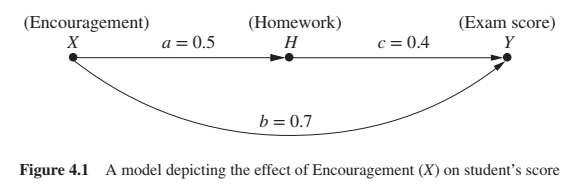

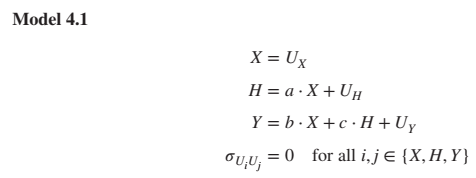

Assume that all $U$ factors are independent and the coefficients of Model 4.1 are given in Figure 4.1.

For the context here, let $X=T$, $H=M$, and $Y=Y$.  Treat these as binary such that
* if $T=1$, the student participated in the enhanced training program.
* if $M=1$, the student spent >3 h/wk studying.
* if $Y=1$, the student passed the exam.

Assume that all $U$ factors are independent.

We ask "To what extent does homework (the mediator, $M$) contribute to student success *regardless* of the training program?".  In other words, we want to discount the direct effect of encouragement (the treatment, $T$) on exam performance (the outcome, $Y$).

Let us try to calculate the different effect types.

### Non-Natural Effects
I apologize for the name.  The book doesn't classify these effects as such, but two of the effects are labeled "Natural" so I'm calling the Total Effect and the Controlled Direct Effect "Non-Natural".

#### Total Effect (TE)

**Total Effect ($\text{TE}$):** the total expected difference between $Y_{T=1}$ and $Y_{T=0}$, where the mediator $M$ tracks its natural response with the treatment $T$.

The book gives us an expression to solve for the TE:
$$\begin{align}
\text{TE} &= 𝔼[Y_{T=1} - Y_{T=0}] \\
&= 𝔼[Y|\text{do}(T=1)] - 𝔼[Y|\text{do}(T=0)] \\
&\text{close backdoors, of which there are none} \\
&= 𝔼[cM + bT + U_Y | \text{do}(T=1)] - 𝔼[cM + bT + U_Y | \text{do}(T=0)] \\
&= (𝔼[cM|\text{do}(T=1)] + 𝔼[bT|\text{do}(T=1)]+ 𝔼[U_Y|\text{do}(T=1)]) - (𝔼[cM|\text{do}(T=0)] + 𝔼[bT|\text{do}(T=0)]+ 𝔼[U_Y|\text{do}(T=0)]) \\
&= (c𝔼[aT|\text{do}(T=1)] + b𝔼[T|\text{do}(T=1)]) - (c𝔼[aT|\text{do}(T=0)] + b𝔼[T|\text{do}(T=0)]) \\
&= (ca + b) - (0 + 0) \\
&= ca + b \\
\end{align}$$

We can find the same expression by using our counterfactual calculus:

$$\begin{align}
\text{TE} &= 𝔼[Y_{T=1} - Y_{T=0}] \\
&= 𝔼[Y_{T=1}] - 𝔼[Y_{T=0}] \\
&= 𝔼[(bT + cM + U_T)_{T=1}] - 𝔼[(bT + cM + U_T)_{T=0}] \\
&= (𝔼[bT_{T=1}] + 𝔼[cM_{T=1}] + 𝔼[U_{T_{T=1}}]) - (𝔼[bT_{T=0}] + 𝔼[cM_{T=0}] + 𝔼[U_{T_{T=0}}])  \\
&= (b + c𝔼[aT + U_M)_{T=1}] + 𝔼[U_{T_{T=1}}]) - (c𝔼[aT + U_M)_{T=0}] + 𝔼[U_{T_{T=0}}]) \\
&= (b + c(𝔼[aT_{T=1}] + 𝔼[U_{M_{T=1}}]) + 𝔼[U_{T_{T=1}}]) - (c(𝔼[aT_{T=0}] + 𝔼[U_{M_{T=0}}]) + 𝔼[U_{T_{T=0}}]) \\
&= (b + c(a + 𝔼[U_{M_{T=1}}]) + 𝔼[U_{T_{T=1}}]) - (c𝔼[U_{M_{T=0}}] + 𝔼[U_{T_{T=0}}]) \\
&= b + c(a + 𝔼[U_{M_{T=1}}] - 𝔼[U_{M_{T=0}}]) + 𝔼[U_{T_{T=1}}] - 𝔼[U_{T_{T=0}}] \\
&= b + c(a + 𝔼[U_{M_{T=1}} - U_{M_{T=0}}]) + 𝔼[U_{T_{T=1}} - U_{T_{T=0}}] \\
&= b + ac + c𝔼[U_{M_{T=1}} - U_{M_{T=0}}] + 𝔼[U_{T_{T=1}} - U_{T_{T=0}}] \\
& \ \ \ \ \ \text{if randomized} \\
&= b + ac
\end{align}$$

If you look at Figure 4.1, this expression should make sense.  The total effect is comprised of the direct effect of $T$ (aka, $X$), which is $b$, and the indirect effect of $T$ exerted via $M$ (aka, $H$), which is the effect of $T$ on $M$ ($a$) multiplied by the effect of $M$ on $Y$ ($c$).

With the numbers given in Figure 4.1, $\text{TE} = 0.7 + (0.5 \times 0.4) = 0.9$.

However, the values given for the example (given in Table 4.6 and Table 4.7) do not correspond to Figure 4.1--which is confusing.  But let's also try to solve for the $\text{TE}$ with these values.

This is not going to be easy because (I believe) there are some typos throughout this example.  It seems as if they rewrote the premise but forgot to make all of the necessary adjustments.  

> The example defines $M$ as a binary variable, where $M=1$ as the student spending more than 3 hr/wk on homework.  But then Table 4.7 gives the *expected* amount of homework given $T=0$ or $T=1$ (there's also a type in the table description, where I think "$Y=1$ should read "$T=1$").  I think that this should give the *probability* of $M=1$ given $T=t$ because a) the expression below will require these probabilities and b) the book's solution seems to be treating these as probabilities.  Further, on the assumption that these are meant to be probabilities, there is at least one value in the book's solution (0.10) that I cannot account for and guess it must be a typo.  Finally, the equation that the book uses (with the mystery 0.10) does not give the answer provided (the answer implied by their expression is 0.56, but they write 0.46).  Finally, the answer I get is what is provided in the book (0.46).

But let's give a go anyway.

$$\begin{align}
\text{TE} &= 𝔼[Y_{T=1} - Y_{T=0}] \\
&= 𝔼[Y_{T=1}] - 𝔼[Y_{T=0}] \\
&= ((𝔼[Y|T=1, M=0] \times p[M=0|T=1]) + (𝔼[Y|T=1, M=1] \times p[M=1|T=1])) - ((𝔼[Y|T=0, M=0] \times p[M=0|T=0]) + (𝔼[Y|T=0, M=1] \times p[M=1|T=0])) \\
&= ((0.40 \times (1-0.75)) + (0.80 \times 0.75)) - ((0.20 \times (1-0.4)) + (0.30 \times 0.4)) \\
&= ((0.4 \times 0.25) + (0.80 \times 0.75)) - ((0.20 \times 0.60) + (0.30 \times 0.40)) \\
&= ((0.1) + (0.6)) - ((0.12) + (0.12))\\
&= 0.7 - 0.24 \\
&= 0.46 \\
\end{align}$$

#### Controlled Direct Effect (CDE)

**Controlled Direct Effect ($\text{CDE}$):** the expected increase in $Y$ as the treatment changes from $T=0$ to $T=1$, while the mediator $M$ is set to a specified level $M=m$.


Once again, the book gives us an equation for this:

$$\begin{align}
CDE(m) &= 𝔼[Y_{T=1, M=m} - Y_{T=0, M=m}] \\
&= 𝔼[Y|\text{do}(T=1, M=m)] - 𝔼[Y|\text{do}(T=0, M=m)] \\
&= 𝔼[cM + bT + U_Y|\text{do}(T=1, M=m)] - 𝔼[cM + bT + U_Y|\text{do}(T=0, M=m)] \\
&= (𝔼[cM|\text{do}(T=1, M=m)] + 𝔼[bT|\text{do}(T=1, M=m)] + 𝔼[U_Y|\text{do}(T=1, M=m)]) - (𝔼[cM|\text{do}(T=0, M=m)] + 𝔼[bT|\text{do}(T=0, M=m)] + 𝔼[U_Y|\text{do}(T=0, M=m)]) \\
&= (c𝔼[M|\text{do}(T=1, M=m)] + b𝔼[T|\text{do}(T=1, M=m)]) - (c𝔼[M|\text{do}(T=0, M=m)] + b𝔼[T|\text{do}(T=0, M=m)]) \\
&= (cm + b) - (cm) \\
&= b \\
\end{align}$$

Once again, let's alternatively use the counterfactual calculus:

$$\begin{align}
\text{CDE}(m) &= 𝔼[Y_{T=1, M=m} - Y_{T=0, M=m}] \\
&= 𝔼[Y_{T=1, M=m}] - 𝔼[Y_{T=0, M=m}] \\
&= 𝔼[(bT + cM + U_T)_{T=1, M=m}] - 𝔼[(bT + cM + U_T)_{T=0, M=m}] \\
&= (𝔼[(bT)_{T=1, M=m}] + 𝔼[(cM)_{T=1, M=m}] + 𝔼[(U_T)_{T=1, M=m}]) - (𝔼[(bT)_{T=0, M=m}] + 𝔼[(cM)_{T=0, M=m}] + 𝔼[(U_T)_{T=0, M=m}]) \\
&= (𝔼[b] + 𝔼[cm] + 𝔼[(U_T)_{T=1, M=m}]) - (𝔼[𝔼[cm] + 𝔼[(U_T)_{T=0, M=m}]) \\
&= (b + cm + 𝔼[(U_T)_{T=1, M=m}]) - (𝔼[cm + 𝔼[(U_T)_{T=0, M=m}]) \\
&= b + 𝔼[(U_T)_{T=1, M=m}] - 𝔼[(U_T)_{T=0, M=m}] \\
& \ \ \ \ \ \text{if randomized} \\
&= b \\
\end{align}$$

Again looking at Figure 4.1, this makes sense.  The direct effect of $T$, controlling for $M$, is the link $b$.

In Figure 4.1, the correct answer is $\text{CDE}(m) = b = 0.7$.  But Tables 4.6 and 4.7 differ; so let's try to solve with that.  Notice that we'll have two answers: one for $M=1$ and another for $M=0$.

$$\begin{align}
\text{CDE}(M=1) &= 𝔼[Y_{T=1, M=1} - Y_{T=0, M=1}] \\
&= 𝔼[Y_{T=1, M=1}] - 𝔼[Y_{T=0, M=1}] \\
&= 𝔼[Y|T=1, M=1] - 𝔼[Y|T=0, M=1] \\
&= 0.80 - 0.30 \\
&= 0.50 \\
\end{align}$$

\

$$\begin{align}
\text{CDE}(M=0) &= 𝔼[Y_{T=1, M=0} - Y_{T=0, M=0}] \\
&= 𝔼[Y_{T=1, M=0}] - 𝔼[Y_{T=0, M=0}] \\
&= 𝔼[Y|T=1, M=0] - 𝔼[Y|T=0, M=0] \\
&= 0.40 - 0.20 \\
&= 0.20 \\
\end{align}$$

### "Natural" Effects

Now we come to the "natural" (direct and indirect) effects, for which there are some additional conditions we need in order identify.  The book gives these conditions,

> We can identify the $\text{NDE}$ and $\text{NIE}$ provided there exists a set $W$ of measured covariates such that
> > A-1 No member of $W$ is a descendant of $T$.

> > A-2 $W$ blocks all backdoor paths from $M$ to $Y$ (after removing $T \rightarrow M$ and $T \rightarrow Y$).

> > A-3 The $W$-specific effect of $T$ on $M$ is identifiable (possibly using experiments or adjustments).

> > A-4 The $W$-specific joint effect of $\{T,M\}$ on $Y$ is identifiable (possibly using experiments or adjustments).

but let's try to gain some intuition about them.

The first thing I want to do is be reminded of *what $W$-specific effects are*, since A-3 and A-4 deal with this.  If you go back to Q3.5.1, you'll be reminded that the $W$-specific effect is

$$p(Y=y|\text{do}(T=g(W)))$$

In other words, the effect of $X$ on $Y$ may be some function $g()$ of $W$.  So we want to set $W=w$ and ensure that all backdoor paths from $X$ to $Y$, as per the backdoor rule, remain closed.

> The $w$-specific effect $p(Y=y|\text{do}(X=g(W)))$ is identified whenever we can measure a set $S$ of variables such that $S \cup W$, where $W \not \in S$, satisfies the backdoor criterion.  Moreover, the $w$-specific effect is given by

> $$\begin{aligned}
p(Y=y|\text{do}(X=g(W))) &= p(Y=y|\text{do}(X=g(W)), W=w) \\
&= \sum_S p(Y=y | X=x, S=s, W=w) \times p(S=s | W=w)
\end{aligned}$$

So what *might* $W$ look like here?  I've made a DAG that represents one possibility.

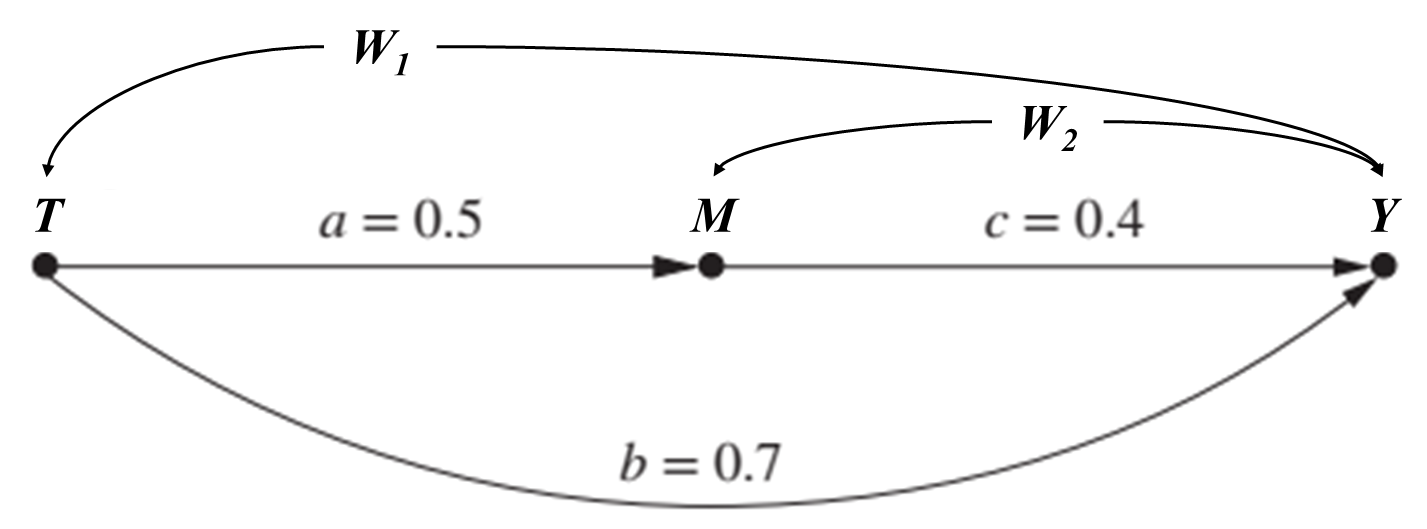

Let's call this modified figure "**Figure 4.1 b**" to distinguish it from the original Figure 4.1.

Here, $W$ is a set of variables, $\mathbf{W} = \{W_1, W_2 \}$.

* A-1 is satisfied because neither $W_1$ nor $W_2$ descend from $T$.
* A-2 is satisfied because the $M \leftarrow W_2 \rightarrow Y$ backdoor path is closed b conditioning on $\mathbf{W}$ (specifically, $W_2$).
* A-3 is satisfied because we can use $W_2$ to find the $W$-specific effect of $M \rightarrow Y$.
* A-4 is satisfied because we can use $\mathbf{W}$ to find the $W$-specific joint effect of $\{T, M\} \rightarrow Y$.


Alternatively, for simplicity, **Figure 4.1 c**.

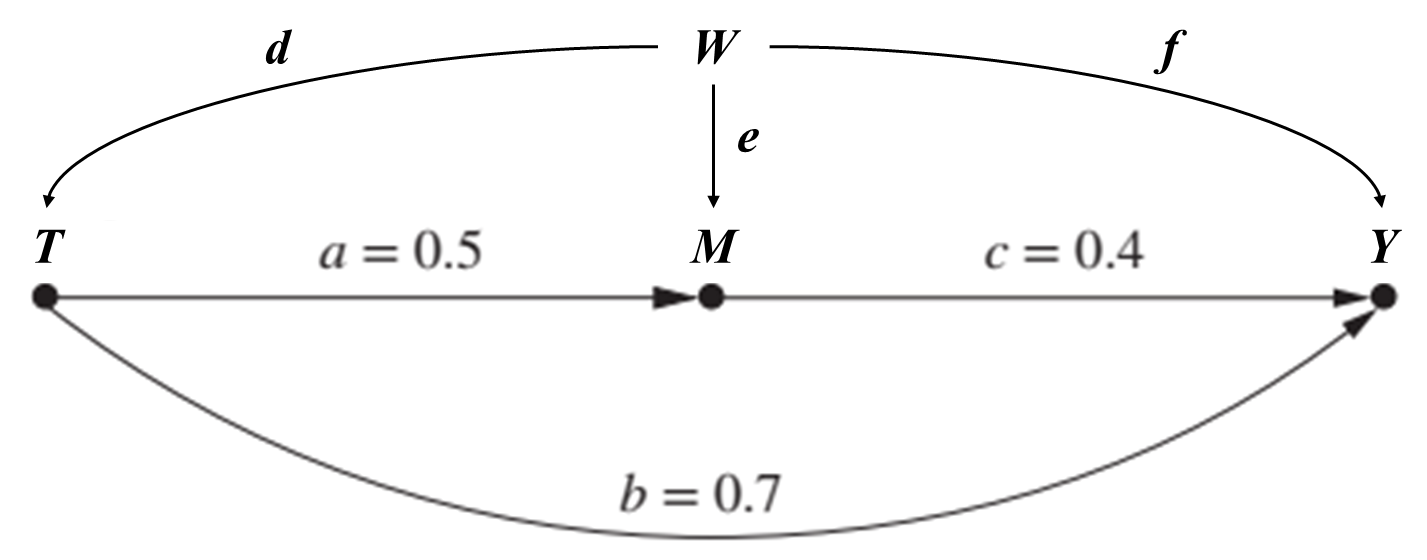

Now, for the example at hand, $W$ is just the empty set ($\mathbf{W} = \{\}$).  You should convince yourself that this still satifies all the A-criteria.

#### Natural Direct Effect (NDE)

**Natural Direct Effect ($\text{NDE}$):** the expected increase in $Y$ as the treatment changes from $T=0$ to $T=1$, while the mediator $M$ is set to value it would have attain if $T=0$, $M_{T=0}$.


The book gives several ways to find the $\text{NDE}$.

##### NDE by Theorem 4.5.2

*When conditions A-1 and A-2 hold, the natrual direct effect is experimentally identifiable and is given by*

$$\begin{align}
\text{NDE} = \sum_M \sum_W &(𝔼[Y|\text{do}(T=1, M=m), W=w] - 𝔼[Y|\text{do}(T=1, M=m), W=w]) \\
&\times p(M=m|\text{do}(T=0), W=w) \\
&\times p(W=w)
\end{align}$$

*The identifiability of the do-expressions above are guaranteed by conditions A-3 and A-4, and can be determined using the backdoor or front-door criteria*

The logic here is straightforward: *Find the expected value of the outcome under both treatment conditions, marginalizing over (that is, "removing the effects of") all possible values of $M$ and $W$*.  The marginalization is necessary because--unlike the $\text{CDE}$, where $M$ is set to $m$--we are allowing $M$ (and $W$) and take on whatever value they would take on when $T=t$.

Fulfilling conditions A-1 and A-2 ensures that we can carry out the $𝔼[Y|\text{do}(⋅)]$ operations, conditions A-3 ensures that we can carry out the $p(M=m|\text{do}(T=0), W=w)$ operation, and A-4 ensures that we can account for any modification of $\{T, M \} \rightarrow Y$ due to $W$.

Let us apply this to the book's example (which has no $W$ term).

$$\begin{align}
\text{NDE} &= [(𝔼[Y|\text{do}(T=1, M=0)] - 𝔼[Y|\text{do}(T=0, M=0)]) \times p(M=0|\text{do}(T=0)] \\
& \ \ \ \ \ + [(𝔼[Y|\text{do}(T=1, M=1)] - 𝔼[Y|\text{do}(T=0, M=1)]) \times p(M=1|\text{do}(T=0)] \\
\\
&= [(𝔼[Y|T=1, M=0] - 𝔼[Y|T=0, M=0]) \times p(M=0|T=0)] \\
& \ \ \ \ \ + [(𝔼[Y|T=1, M=1] - 𝔼[Y|T=0, M=1]) \times p(M=1|T=0)] \\
\\
&= [(0.40 - 0.20) \times (1-0.40)] \\
& \ \ \ \ \ + [(0.80 - 0.30) \times 0.40] \\
\\
&= [0.20 \times 0.60] \\
& \ \ \ \ \ + [0.50 \times 0.40] \\
\\
&= [0.12] \\
& \ \ \ \ \ + [0.20] \\
\\
&= 0.32 \\
\end{align}$$

##### NDE by Corollary 4.5.1

GIVE BY COROLLARY 4.5.1 AND EQN 4.5.1

EXPLAIN WHY GIVEN CONDITIONS ARE IMPORTANT

##### NDE by Counterfactual Analysis

$$\begin{align}
\text{NDE} &= 𝔼[Y_{T=1, M=M_{T=0}} - Y_{T=0, M=M_{T=0}}] \\
&= 𝔼[Y_{T=1, M=M_{T=0}}] - 𝔼[Y_{T=0, M=M_{T=0}}] \\
&= 𝔼[(bT + cM + U_T)_{T=1, M=M_{T=0}}] - 𝔼[(bT + cM + U_T)_{T=0, M=M_{T=0}}] \\
&= (𝔼[(bT)_{T=1, M=M_{T=0}}] + 𝔼[(cM)_{T=1, M=M_{T=0}}] + 𝔼[(U_T)_{T=1, M=M_{T=0}}]) - (𝔼[(bT)_{T=0, M=M_{T=0}}] + 𝔼[(cM)_{T=0, M=M_{T=0}}] + 𝔼[(U_T)_{T=0, M=M_{T=0}}]) \\
&= (𝔼[b] + 𝔼[cM_{T=0}] + 𝔼[(U_T)_{T=1, M=M_{T=0}}]) - (𝔼[cm] + 𝔼[(U_T)_{T=0, M=M_{T=0}}]) \\
&= (b + cm + 𝔼[(U_T)_{T=1, M=M_{T=0}}]) - (𝔼[cm + 𝔼[(U_T)_{T=0, M=M_{T=0}}]) \\
&= b + 𝔼[(U_T)_{T=1, M=M_{T=0}}] - 𝔼[(U_T)_{T=0, M=M_{T=0}}] \\
& \ \ \ \ \ \text{if randomized} \\
&= b \\
\end{align}$$

ALSO DO FIGURE 4.5.1 B WITH $W$

#### Natural Indirect Effect (NIE)
**Natrual Indirect Effect ($\text{NIE}$):** the expected increase in $Y$ where the treatment is held contant at $T=0$ and the mediator $M$ changes from the value it would attain would attain when $T=0$, $M_{T=0}$ to $T=1$, $M_{T=1}$.
$$\begin{align}
\text{NIE} &= 𝔼[Y_{T=0, M=M_{T=1}} - Y_{T=0, M=M_{T=0}}] \\
&= 𝔼[Y_{T=0, M=M_{T=1}}] - 𝔼[Y_{T=0, M=M_{T=0}}] \\
&= 𝔼[(bT + cM + U_T)_{T=0, M=M_{T=1}}] - 𝔼[(bT + cM + U_T)_{T=0, M=M_{T=0}}] \\
&= (𝔼[(bT)_{T=0, M=M_{T=1}}] + 𝔼[(cM)_{T=0, M=M_{T=1}}] + 𝔼[(U_T)_{T=0, M=M_{T=1}}]) - (𝔼[(bT)_{T=0, M=M_{T=0}}] + 𝔼[(cM)_{T=0, M=M_{T=0}}] + 𝔼[(U_T)_{T=0, M=M_{T=0}}]) \\
&= (𝔼[cM_{T=1}] + 𝔼[(U_T)_{T=0, M=M_{T=1}}]) - (𝔼[cM_{T=0}] + 𝔼[(U_T)_{T=0, M=M_{T=0}}]) \\
&= (cM_{T=1} + 𝔼[(U_T)_{T=0, M=M_{T=1}}]) - (cM_{T=0} + 𝔼[(U_T)_{T=0, M=M_{T=0}}]) \\
& \ \ \ \ \ \text{if randomized} \\
&= cM_{T=1} - cM_{T=0} \\
&= c(M_{T=1} - M_{T=0}) \\
&= c((aT + U_M)_{T=1} - (aT + U_M)_{T=0}) \\
&= c(a + (U_M)_{T=1} - (U_M)_{T=0}) \\
\end{align}$$

SOLVE FOR TE WITH NATURAL EFFECTS, AS PER BOOK.